In [ ]:
!pip install geopandas matplotlib
!pip install geodatasets
!pip install rioxarray
!pip install openpyxl
!pip install selenium webdriver-manager
!pip install fiona

!pip install netCDF4
!pip install seaborn
!pip install scipy
!pip install pygam
!pip install mplcursors

# Chapter 2: In-Situ Satellite Validation

In [ ]:

import copernicusmarine
from netCDF4 import Dataset, num2date
import pandas as pd
import matplotlib
import mplcursors
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.ticker import FixedLocator
from matplotlib.lines import Line2D
import os
import xarray as xr
import rioxarray as rxr
import seaborn as sns
import seaborn.objects as so
import numpy as np
import gc
from datetime import datetime
import glob
from scipy import stats
from scipy.stats import linregress
import geopandas as gpd
import geodatasets
from shapely.geometry import Point
from shapely.geometry import MultiPolygon
from shapely import wkb
import pandas as pd
import re
import time
import json
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from scipy import stats
from statsmodels.tsa.seasonal import STL
import geopandas as gpd
import rioxarray
import fiona
from pygam import LinearGAM, s, f
import numpy as np

In [ ]:
import os

# Set your path
# If you are on Windows, use: r'C:\Users\YourName\...\in-situ'
# If you are in Jupyter/Linux, use: '/home/jovyan/notmessedup_directory/in-situ/'
directory_path = '/home/jovyan/notmessedup_directory/in-situ/'

try:
    files = os.listdir(directory_path)
    print(f"Files in {directory_path}:")
    for file in files:
        print(f" - {file}")
except FileNotFoundError:
    print("The directory path was not found. Please double-check the location.")

In [ ]:
os.environ['COPERNICUS_USERNAME'] = 'hdoran'
os.environ['COPERNICUS_PASSWORD'] = "ihateAngela69**##"

username = os.getenv('COPERNICUS_USERNAME')
password = os.getenv('COPERNICUS_PASSWORD')


## messed up! should've done at least 56 degrees north, or maybe even 57
## 55 deg N cuts into the northern end of the island
def new_batch_file_with_dir(dataset_id, variables, regions, directory):
    start_date = datetime(2026, 4, 1)
    end_date = datetime(2026, 5, 31)

    results = {}
    years = range(start_date.year, end_date.year + 1)

    for region in regions:
        region_name = region["name"]
        region_file_paths = []

        for year in years:
            year_start = datetime(year, 1, 1)
            year_end = datetime(year, 12, 31)
            if year == start_date.year:
                year_start = start_date
            if year == end_date.year:
                year_end = end_date

            # Download the data for this specific year
            result = copernicusmarine.subset(
                dataset_id=dataset_id,
                variables=variables,
                minimum_longitude=region["min_lon"],
                maximum_longitude=region["max_lon"],
                minimum_latitude=region["min_lat"],
                maximum_latitude=region["max_lat"],
                start_datetime=year_start.strftime('%Y-%m-%dT%H:%M:%S'),
                end_datetime=year_end.strftime('%Y-%m-%dT%H:%M:%S'),
                output_directory='/home/jovyan/notmessedup_directory' + directory,
                username=username,
                password=password
            )

            # Save only the file path (not the dataset object)
            region_file_paths.append(result.file_path)

            # Free memory
            del result
            gc.collect()

        results[region_name] = region_file_paths

    return results


### Downloading KD490 In-Situ

kd490_galway_file = new_batch_file_with_dir("cmems_obs-oc_atl_bgc-transp_my_l3-multi-1km_P1D",["KD490"],[{"name":"ireland", "min_lon": -10.0, "min_lat": 52.75, "max_lon":-8.75, "max_lat": 53.5}],'/in-situ/KD490')

In [ ]:
kd490_insitu_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/in-situ/KD490/*.nc'))
kd490_is = xr.open_mfdataset(kd490_insitu_file_list, concat_dim='time', combine='nested')
display(kd490_is)

In [ ]:
kd490_is['KD490'].sel(time='2026-04-28').plot()

### Downloading Secchi-Depth In-situ

zsd_galway_file = new_batch_file_with_dir("cmems_obs-oc_atl_bgc-transp_my_l3-multi-1km_P1D", ["ZSD"],
                                            [{"name": "ireland", "min_lon": -10.0, "min_lat": 52.75, "max_lon": -8.75,
                                              "max_lat": 53.5}], '/in-situ/ZSD')

In [ ]:
zsd_insitu_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/in-situ/ZSD/*.nc'))
zsd_is = xr.open_mfdataset(zsd_insitu_file_list, concat_dim='time', combine='nested')
display(zsd_is)

In [ ]:
zsd_is['ZSD'].sel(time='2026-04-28').plot()

### Downloading SPM In-Situ

spm_galway_file = new_batch_file_with_dir("cmems_obs-oc_atl_bgc-transp_my_l3-multi-1km_P1D", ["SPM"],
                                            [{"name": "ireland", "min_lon": -10.0, "min_lat": 52.75, "max_lon": -8.75,
                                              "max_lat": 53.5}], '/in-situ/SPM')

In [ ]:
spm_insitu_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/in-situ/SPM/*.nc'))
spm_is = xr.open_mfdataset(spm_insitu_file_list, concat_dim='time', combine='nested')
display(spm_is)

In [ ]:
spm_is['SPM'].sel(time='2026-04-28').plot(x='longitude', y='latitude', vmin=0, vmax=5)

### Downloading Chlorophyll-a In-situ

chla_galway_file = new_batch_file_with_dir("cmems_obs-oc_atl_bgc-plankton_my_l3-olci-300m_P1D", ["CHL"],
                                          [{"name": "ireland", "min_lon": -10.0, "min_lat": 52.75, "max_lon": -8.75,
                                            "max_lat": 53.5}], '/in-situ/CHL')

In [ ]:
chla_insitu_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/in-situ/CHL/*.nc'))
chla_is = xr.open_mfdataset(chla_insitu_file_list, concat_dim='time', combine='nested')
display(chla_is)

In [ ]:
print(chla_is['CHL'].sel(time='2026-04-28').time.values)
## there are multiple passes in one day

In [ ]:
# Strip out the exact duplicates by keeping only the first unique timestamp
_, index = np.unique(chla_is['time'], return_index=True)
chla_is_one = chla_is.isel(time=index)

In [ ]:
chla_is_one['CHL'].sel(time='2026-04-28').plot(x='longitude', y='latitude', vmin=0, vmax=200)

In [ ]:
## Code to check if the NaN values are the same everyday

# 1. Group by the time coordinate
grouped = chla_is['CHL'].groupby('time')

all_duplicates_identical = True
checked_days_count = 0

print("Checking duplicate NaN patterns across the dataset...\n")

for time_val, group in grouped:
    # We only care about days that actually have duplicates (more than 1 slice)
    if group.sizes['time'] > 1:
        checked_days_count += 1

        # Get the NaN mask for all slices on this day (True where NaN, False where valid)
        nan_mask = group.isnull()

        # Check if the NaN mask for the first slice matches all other slices along the time dim
        # .all() checks if every single pixel matches
        is_identical = (nan_mask == nan_mask.isel(time=0)).all().values

        if not is_identical:
            print(f"❌ Mismatch found on day {np.datetime_as_string(time_val, unit='D')}!")
            all_duplicates_identical = False
            break

# 2. Print final verdict
if all_duplicates_identical and checked_days_count > 0:
    print(f"✅ Success! Verified {checked_days_count} days with duplicate files.")
    print("For every single one of those days, the NaN values are in the exact same spots.")
elif checked_days_count == 0:
    print("🤔 No duplicate timestamps were found in the dataset to compare.")

In [ ]:
## check if the values of every pixel are the same per day

import numpy as np

# 1. Group by the time coordinate
grouped = chla_is['CHL'].groupby('time')

all_values_identical = True
checked_days_count = 0

print("Checking if duplicate pixel values match exactly across the dataset...\n")

for time_val, group in grouped:
    # Target only the days that have duplicates
    if group.sizes['time'] > 1:
        checked_days_count += 1

        # Extract the underlying numpy array for the daily slices
        data_array = group.values
        first_slice = data_array[0]

        # Compare every subsequent slice to the first slice
        for i in range(1, len(data_array)):
            is_match = np.allclose(first_slice, data_array[i], equal_nan=True)

            if not is_match:
                print(f"❌ Value mismatch found on day {np.datetime_as_string(time_val, unit='D')} at slice index {i}!")
                all_values_identical = False
                break

    if not all_values_identical:
        break

# 2. Print final verdict
if all_values_identical and checked_days_count > 0:
    print(f"✅ Success! All data values are 100% identical across the duplicate slices for all {checked_days_count} days.")
elif checked_days_count == 0:
    print("🤔 No duplicate timestamps were found in the dataset to compare.")

In [ ]:
## can write over the orignal data with this one, as it is verified that the values are the same for every pass every day
# Strip out the exact duplicates by keeping only the first unique timestamp
_, index = np.unique(chla_is['time'], return_index=True)
chla_is = chla_is.isel(time=index)

### Downloading CDOM In-Situ

cdom_galway_file = new_batch_file_with_dir("cmems_obs-oc_atl_bgc-optics_my_l3-multi-1km_P1D", ["CDM"],
                                          [{"name": "ireland", "min_lon": -10.0, "min_lat": 52.75, "max_lon": -8.75,
                                            "max_lat": 53.5}], '/in-situ/CDM')

In [ ]:
cdom_insitu_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/in-situ/CDM/*.nc'))
cdom_is = xr.open_mfdataset(cdom_insitu_file_list, concat_dim='time', combine='nested')
display(cdom_is)

In [ ]:
cdom_is['CDM'].sel(time='2026-5-5').plot(x='longitude', y='latitude') #, vmin=0, vmax=200)

## Remote Sensing Reflectances

### Rrs400

rrs400_galway_file = new_batch_file_with_dir("cmems_obs-oc_atl_bgc-reflectance_my_l3-olci-300m_P1D", ["RRS400"],
                                          [{"name": "ireland", "min_lon": -10.0, "min_lat": 52.75, "max_lon": -8.75,
                                            "max_lat": 53.5}], '/in-situ/RRS400')

In [ ]:
rrs400_insitu_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/in-situ/RRS400/*.nc'))
rrs400_is = xr.open_mfdataset(rrs400_insitu_file_list, concat_dim='time', combine='nested')
display(rrs400_is)

In [ ]:

import numpy as np

# 1. Group by the time coordinate
grouped = rrs400_is['RRS400'].groupby('time')

all_values_identical = True
checked_days_count = 0

print("Checking if duplicate pixel values match exactly across the dataset...\n")

for time_val, group in grouped:
    # Target only the days that have duplicates
    if group.sizes['time'] > 1:
        checked_days_count += 1

        # Extract the underlying numpy array for the daily slices
        data_array = group.values
        first_slice = data_array[0]

        # Compare every subsequent slice to the first slice
        for i in range(1, len(data_array)):
            is_match = np.allclose(first_slice, data_array[i], equal_nan=True)

            if not is_match:
                print(f"❌ Value mismatch found on day {np.datetime_as_string(time_val, unit='D')} at slice index {i}!")
                all_values_identical = False
                break

    if not all_values_identical:
        break

# 2. Print final verdict
if all_values_identical and checked_days_count > 0:
    print(f"✅ Success! All data values are 100% identical across the duplicate slices for all {checked_days_count} days.")
elif checked_days_count == 0:
    print("🤔 No duplicate timestamps were found in the dataset to compare.")

In [ ]:
rrs400_is['RRS400'].sel(time='2026-4-28').plot(x='longitude', y='latitude')

### Rrs 412

rrs412_galway_file = new_batch_file_with_dir("cmems_obs-oc_atl_bgc-reflectance_my_l3-olci-300m_P1D", ["RRS412"],
                                          [{"name": "ireland", "min_lon": -10.0, "min_lat": 52.75, "max_lon": -8.75,
                                            "max_lat": 53.5}], '/in-situ/RRS412')

In [ ]:
rrs412_insitu_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/in-situ/RRS412/*.nc'))
rrs412_is = xr.open_mfdataset(rrs412_insitu_file_list, concat_dim='time', combine='nested')
display(rrs412_is)

In [ ]:
rrs412_is['RRS412'].sel(time='2026-4-28').plot(x='longitude', y='latitude')

### Rrs443

rrs443_galway_file = new_batch_file_with_dir("cmems_obs-oc_atl_bgc-reflectance_my_l3-olci-300m_P1D", ["RRS443"],
                                             [{"name": "ireland", "min_lon": -10.0, "min_lat": 52.75, "max_lon": -8.75,
                                               "max_lat": 53.5}], '/in-situ/RRS443')

In [ ]:
rrs443_insitu_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/in-situ/RRS443/*.nc'))
rrs443_is = xr.open_mfdataset(rrs443_insitu_file_list, concat_dim='time', combine='nested')
display(rrs443_is)

In [ ]:

import numpy as np

# 1. Group by the time coordinate
grouped = rrs443_is['RRS443'].groupby('time')

all_values_identical = True
checked_days_count = 0

print("Checking if duplicate pixel values match exactly across the dataset...\n")

for time_val, group in grouped:
    # Target only the days that have duplicates
    if group.sizes['time'] > 1:
        checked_days_count += 1

        # Extract the underlying numpy array for the daily slices
        data_array = group.values
        first_slice = data_array[0]

        # Compare every subsequent slice to the first slice
        for i in range(1, len(data_array)):
            is_match = np.allclose(first_slice, data_array[i], equal_nan=True)

            if not is_match:
                print(f"❌ Value mismatch found on day {np.datetime_as_string(time_val, unit='D')} at slice index {i}!")
                all_values_identical = False
                break

    if not all_values_identical:
        break

# 2. Print final verdict
if all_values_identical and checked_days_count > 0:
    print(f"✅ Success! All data values are 100% identical across the duplicate slices for all {checked_days_count} days.")
elif checked_days_count == 0:
    print("🤔 No duplicate timestamps were found in the dataset to compare.")

In [ ]:
_, index = np.unique(rrs443_is['time'], return_index=True)
rrs443_is = rrs443_is.isel(time=index)

In [ ]:
rrs443_is['RRS443'].sel(time='2026-4-28').plot(x='longitude', y='latitude')

### Rrs490

rrs490_galway_file = new_batch_file_with_dir("cmems_obs-oc_atl_bgc-reflectance_my_l3-olci-300m_P1D", ["RRS490"],
                                             [{"name": "ireland", "min_lon": -10.0, "min_lat": 52.75, "max_lon": -8.75,
                                               "max_lat": 53.5}], '/in-situ/RRS490')

In [ ]:
rrs490_insitu_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/in-situ/RRS490/*.nc'))
rrs490_is = xr.open_mfdataset(rrs490_insitu_file_list, concat_dim='time', combine='nested')
display(rrs490_is)

In [ ]:

import numpy as np

# 1. Group by the time coordinate
grouped = rrs490_is['RRS490'].groupby('time')

all_values_identical = True
checked_days_count = 0

print("Checking if duplicate pixel values match exactly across the dataset...\n")

for time_val, group in grouped:
    # Target only the days that have duplicates
    if group.sizes['time'] > 1:
        checked_days_count += 1

        # Extract the underlying numpy array for the daily slices
        data_array = group.values
        first_slice = data_array[0]

        # Compare every subsequent slice to the first slice
        for i in range(1, len(data_array)):
            is_match = np.allclose(first_slice, data_array[i], equal_nan=True)

            if not is_match:
                print(f"❌ Value mismatch found on day {np.datetime_as_string(time_val, unit='D')} at slice index {i}!")
                all_values_identical = False
                break

    if not all_values_identical:
        break

# 2. Print final verdict
if all_values_identical and checked_days_count > 0:
    print(
        f"✅ Success! All data values are 100% identical across the duplicate slices for all {checked_days_count} days.")
elif checked_days_count == 0:
    print("🤔 No duplicate timestamps were found in the dataset to compare.")

In [ ]:
rrs490_is['RRS490'].sel(time='2026-04-28').plot(x='longitude', y='latitude')

### Rrs510

rrs510_galway_file = new_batch_file_with_dir("cmems_obs-oc_atl_bgc-reflectance_my_l3-olci-300m_P1D", ["RRS510"],
                                             [{"name": "ireland", "min_lon": -10.0, "min_lat": 52.75, "max_lon": -8.75,
                                               "max_lat": 53.5}], '/in-situ/RRS510')

In [ ]:
rrs510_insitu_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/in-situ/RRS510/*.nc'))
rrs510_is = xr.open_mfdataset(rrs510_insitu_file_list, concat_dim='time', combine='nested')
display(rrs510_is)

In [ ]:

import numpy as np

# 1. Group by the time coordinate
grouped = rrs510_is['RRS510'].groupby('time')

all_values_identical = True
checked_days_count = 0

print("Checking if duplicate pixel values match exactly across the dataset...\n")

for time_val, group in grouped:
    # Target only the days that have duplicates
    if group.sizes['time'] > 1:
        checked_days_count += 1

        # Extract the underlying numpy array for the daily slices
        data_array = group.values
        first_slice = data_array[0]

        # Compare every subsequent slice to the first slice
        for i in range(1, len(data_array)):
            is_match = np.allclose(first_slice, data_array[i], equal_nan=True)

            if not is_match:
                print(f"❌ Value mismatch found on day {np.datetime_as_string(time_val, unit='D')} at slice index {i}!")
                all_values_identical = False
                break

    if not all_values_identical:
        break

# 2. Print final verdict
if all_values_identical and checked_days_count > 0:
    print(
        f"✅ Success! All data values are 100% identical across the duplicate slices for all {checked_days_count} days.")
elif checked_days_count == 0:
    print("🤔 No duplicate timestamps were found in the dataset to compare.")

In [ ]:
rrs510_is['RRS510'].sel(time='2026-04-28').plot(x='longitude', y='latitude')

### Rrs560

rrs560_galway_file = new_batch_file_with_dir("cmems_obs-oc_atl_bgc-reflectance_my_l3-olci-300m_P1D", ["RRS560"],
                                             [{"name": "ireland", "min_lon": -10.0, "min_lat": 52.75, "max_lon": -8.75,
                                               "max_lat": 53.5}], '/in-situ/RRS560')

In [ ]:
rrs560_insitu_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/in-situ/RRS560/*.nc'))
rrs560_is = xr.open_mfdataset(rrs560_insitu_file_list, concat_dim='time', combine='nested')
display(rrs560_is)

In [ ]:

import numpy as np

# 1. Group by the time coordinate
grouped = rrs560_is['RRS560'].groupby('time')

all_values_identical = True
checked_days_count = 0

print("Checking if duplicate pixel values match exactly across the dataset...\n")

for time_val, group in grouped:
    # Target only the days that have duplicates
    if group.sizes['time'] > 1:
        checked_days_count += 1

        # Extract the underlying numpy array for the daily slices
        data_array = group.values
        first_slice = data_array[0]

        # Compare every subsequent slice to the first slice
        for i in range(1, len(data_array)):
            is_match = np.allclose(first_slice, data_array[i], equal_nan=True)

            if not is_match:
                print(f"❌ Value mismatch found on day {np.datetime_as_string(time_val, unit='D')} at slice index {i}!")
                all_values_identical = False
                break

    if not all_values_identical:
        break

# 2. Print final verdict
if all_values_identical and checked_days_count > 0:
    print(
        f"✅ Success! All data values are 100% identical across the duplicate slices for all {checked_days_count} days.")
elif checked_days_count == 0:
    print("🤔 No duplicate timestamps were found in the dataset to compare.")

In [ ]:
rrs560_is['RRS560'].sel(time='2026-04-28').plot(x='longitude', y='latitude')

### Rrs620

rrs620_galway_file = new_batch_file_with_dir("cmems_obs-oc_atl_bgc-reflectance_my_l3-olci-300m_P1D", ["RRS620"],
                                             [{"name": "ireland", "min_lon": -10.0, "min_lat": 52.75, "max_lon": -8.75,
                                               "max_lat": 53.5}], '/in-situ/RRS620')

In [ ]:
rrs620_insitu_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/in-situ/RRS620/*.nc'))
rrs620_is = xr.open_mfdataset(rrs620_insitu_file_list, concat_dim='time', combine='nested')
display(rrs620_is)

In [ ]:


# 1. Group by the time coordinate
grouped = rrs620_is['RRS620'].groupby('time')

all_values_identical = True
checked_days_count = 0

print("Checking if duplicate pixel values match exactly across the dataset...\n")

for time_val, group in grouped:
    # Target only the days that have duplicates
    if group.sizes['time'] > 1:
        checked_days_count += 1

        # Extract the underlying numpy array for the daily slices
        data_array = group.values
        first_slice = data_array[0]

        # Compare every subsequent slice to the first slice
        for i in range(1, len(data_array)):
            is_match = np.allclose(first_slice, data_array[i], equal_nan=True)

            if not is_match:
                print(f"❌ Value mismatch found on day {np.datetime_as_string(time_val, unit='D')} at slice index {i}!")
                all_values_identical = False
                break

    if not all_values_identical:
        break

# 2. Print final verdict
if all_values_identical and checked_days_count > 0:
    print(
        f"✅ Success! All data values are 100% identical across the duplicate slices for all {checked_days_count} days.")
elif checked_days_count == 0:
    print("🤔 No duplicate timestamps were found in the dataset to compare.")

In [ ]:
rrs620_is['RRS620'].sel(time='2026-04-28').plot(x='longitude', y='latitude')

### Rrs665

rrs665_galway_file = new_batch_file_with_dir("cmems_obs-oc_atl_bgc-reflectance_my_l3-olci-300m_P1D", ["RRS665"],
                                             [{"name": "ireland", "min_lon": -10.0, "min_lat": 52.75, "max_lon": -8.75,
                                               "max_lat": 53.5}], '/in-situ/RRS665')

In [ ]:
rrs665_insitu_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/in-situ/RRS665/*.nc'))
rrs665_is = xr.open_mfdataset(rrs665_insitu_file_list, concat_dim='time', combine='nested')
display(rrs665_is)

In [ ]:

# 1. Group by the time coordinate
grouped = rrs665_is['RRS665'].groupby('time')

all_values_identical = True
checked_days_count = 0

print("Checking if duplicate pixel values match exactly across the dataset...\n")

for time_val, group in grouped:
    # Target only the days that have duplicates
    if group.sizes['time'] > 1:
        checked_days_count += 1

        # Extract the underlying numpy array for the daily slices
        data_array = group.values
        first_slice = data_array[0]

        # Compare every subsequent slice to the first slice
        for i in range(1, len(data_array)):
            is_match = np.allclose(first_slice, data_array[i], equal_nan=True)

            if not is_match:
                print(f"❌ Value mismatch found on day {np.datetime_as_string(time_val, unit='D')} at slice index {i}!")
                all_values_identical = False
                break

    if not all_values_identical:
        break

# 2. Print final verdict
if all_values_identical and checked_days_count > 0:
    print(
        f"✅ Success! All data values are 100% identical across the duplicate slices for all {checked_days_count} days.")
elif checked_days_count == 0:
    print("🤔 No duplicate timestamps were found in the dataset to compare.")

In [ ]:
rrs665_is['RRS665'].sel(time='2026-04-28').plot(x='longitude', y='latitude')

### Rrs674

rrs674_galway_file = new_batch_file_with_dir("cmems_obs-oc_atl_bgc-reflectance_my_l3-olci-300m_P1D", ["RRS674"],
                                             [{"name": "ireland", "min_lon": -10.0, "min_lat": 52.75, "max_lon": -8.75,
                                               "max_lat": 53.5}], '/in-situ/RRS674')

In [ ]:
rrs674_insitu_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/in-situ/RRS674/*.nc'))
rrs674_is = xr.open_mfdataset(rrs674_insitu_file_list, concat_dim='time', combine='nested')
display(rrs674_is)

In [ ]:

# 1. Group by the time coordinate
grouped = rrs674_is['RRS674'].groupby('time')

all_values_identical = True
checked_days_count = 0

print("Checking if duplicate pixel values match exactly across the dataset...\n")

for time_val, group in grouped:
    # Target only the days that have duplicates
    if group.sizes['time'] > 1:
        checked_days_count += 1

        # Extract the underlying numpy array for the daily slices
        data_array = group.values
        first_slice = data_array[0]

        # Compare every subsequent slice to the first slice
        for i in range(1, len(data_array)):
            is_match = np.allclose(first_slice, data_array[i], equal_nan=True)

            if not is_match:
                print(f"❌ Value mismatch found on day {np.datetime_as_string(time_val, unit='D')} at slice index {i}!")
                all_values_identical = False
                break

    if not all_values_identical:
        break

# 2. Print final verdict
if all_values_identical and checked_days_count > 0:
    print(
        f"✅ Success! All data values are 100% identical across the duplicate slices for all {checked_days_count} days.")
elif checked_days_count == 0:
    print("🤔 No duplicate timestamps were found in the dataset to compare.")

In [ ]:
rrs674_is['RRS674'].sel(time='2026-04-28').plot(x='longitude', y='latitude')

### Rrs681

rrs681_galway_file = new_batch_file_with_dir("cmems_obs-oc_atl_bgc-reflectance_my_l3-olci-300m_P1D", ["RRS681"],
                                             [{"name": "ireland", "min_lon": -10.0, "min_lat": 52.75, "max_lon": -8.75,
                                               "max_lat": 53.5}], '/in-situ/RRS681')

In [ ]:
rrs681_insitu_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/in-situ/RRS681/*.nc'))
rrs681_is = xr.open_mfdataset(rrs681_insitu_file_list, concat_dim='time', combine='nested')
display(rrs681_is)

In [ ]:

# 1. Group by the time coordinate
grouped = rrs681_is['RRS681'].groupby('time')

all_values_identical = True
checked_days_count = 0

print("Checking if duplicate pixel values match exactly across the dataset...\n")

for time_val, group in grouped:
    # Target only the days that have duplicates
    if group.sizes['time'] > 1:
        checked_days_count += 1

        # Extract the underlying numpy array for the daily slices
        data_array = group.values
        first_slice = data_array[0]

        # Compare every subsequent slice to the first slice
        for i in range(1, len(data_array)):
            is_match = np.allclose(first_slice, data_array[i], equal_nan=True)

            if not is_match:
                print(f"❌ Value mismatch found on day {np.datetime_as_string(time_val, unit='D')} at slice index {i}!")
                all_values_identical = False
                break

    if not all_values_identical:
        break

# 2. Print final verdict
if all_values_identical and checked_days_count > 0:
    print(
        f"✅ Success! All data values are 100% identical across the duplicate slices for all {checked_days_count} days.")
elif checked_days_count == 0:
    print("🤔 No duplicate timestamps were found in the dataset to compare.")

In [ ]:
rrs681_is['RRS681'].sel(time='2026-04-28').plot(x='longitude', y='latitude')

### Rrs709
Last one!

rrs709_galway_file = new_batch_file_with_dir("cmems_obs-oc_atl_bgc-reflectance_my_l3-olci-300m_P1D", ["RRS709"],
                                             [{"name": "ireland", "min_lon": -10.0, "min_lat": 52.75, "max_lon": -8.75,
                                               "max_lat": 53.5}], '/in-situ/RRS709')

In [ ]:
rrs709_insitu_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/in-situ/RRS709/*.nc'))
rrs709_is = xr.open_mfdataset(rrs709_insitu_file_list, concat_dim='time', combine='nested')
display(rrs709_is)

In [ ]:

# 1. Group by the time coordinate
grouped = rrs709_is['RRS709'].groupby('time')

all_values_identical = True
checked_days_count = 0

print("Checking if duplicate pixel values match exactly across the dataset...\n")

for time_val, group in grouped:
    # Target only the days that have duplicates
    if group.sizes['time'] > 1:
        checked_days_count += 1

        # Extract the underlying numpy array for the daily slices
        data_array = group.values
        first_slice = data_array[0]

        # Compare every subsequent slice to the first slice
        for i in range(1, len(data_array)):
            is_match = np.allclose(first_slice, data_array[i], equal_nan=True)

            if not is_match:
                print(f"❌ Value mismatch found on day {np.datetime_as_string(time_val, unit='D')} at slice index {i}!")
                all_values_identical = False
                break

    if not all_values_identical:
        break

# 2. Print final verdict
if all_values_identical and checked_days_count > 0:
    print(
        f"✅ Success! All data values are 100% identical across the duplicate slices for all {checked_days_count} days.")
elif checked_days_count == 0:
    print("🤔 No duplicate timestamps were found in the dataset to compare.")

In [ ]:
rrs709_is['RRS709'].sel(time='2026-04-28').plot(x='longitude', y='latitude')

### Rrs Flags

In [ ]:
rrsflags_galway_file = new_batch_file_with_dir("cmems_obs-oc_atl_bgc-reflectance_my_l3-olci-300m_P1D", ["flags"],
                                             [{"name": "ireland", "min_lon": -10.0, "min_lat": 52.75, "max_lon": -8.75,
                                               "max_lat": 53.5}], '/in-situ/RRSflags')

In [ ]:
rrsflags_insitu_file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/in-situ/RRSflags/*.nc'))
rrsflags_is = xr.open_mfdataset(rrsflags_insitu_file_list, concat_dim='time', combine='nested')
display(rrsflags_is)

In [ ]:

# 1. Group by the time coordinate
grouped = rrsflags_is['flags'].groupby('time')

all_values_identical = True
checked_days_count = 0

print("Checking if duplicate pixel values match exactly across the dataset...\n")

for time_val, group in grouped:
    # Target only the days that have duplicates
    if group.sizes['time'] > 1:
        checked_days_count += 1

        # Extract the underlying numpy array for the daily slices
        data_array = group.values
        first_slice = data_array[0]

        # Compare every subsequent slice to the first slice
        for i in range(1, len(data_array)):
            is_match = np.allclose(first_slice, data_array[i], equal_nan=True)

            if not is_match:
                print(f"❌ Value mismatch found on day {np.datetime_as_string(time_val, unit='D')} at slice index {i}!")
                all_values_identical = False
                break

    if not all_values_identical:
        break

# 2. Print final verdict
if all_values_identical and checked_days_count > 0:
    print(
        f"✅ Success! All data values are 100% identical across the duplicate slices for all {checked_days_count} days.")
elif checked_days_count == 0:
    print("🤔 No duplicate timestamps were found in the dataset to compare.")

In [ ]:
rrs400_is['time']

### Landmasses

In [ ]:
## try to get this onto a map of Ireland using geopandas

url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_IRL_shp.zip"
uk_url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_GBR_shp.zip"

ireland = gpd.read_file(url, layer="gadm41_IRL_0")

uk = gpd.read_file(uk_url, layer="gadm41_GBR_0")
uk_regions = gpd.read_file(uk_url, layer="gadm41_GBR_1")
northern_ireland = uk_regions[uk_regions["NAME_1"] == "Northern Ireland"]
island = gpd.GeoDataFrame(pd.concat([ireland, northern_ireland], ignore_index=True), crs="EPSG:4326")
## adding in france for the large satellite plots
#fra_url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_FRA_shp.zip"
#france = gpd.read_file(fra_url, layer="gadm41_FRA_0")
#all_land = gpd.GeoDataFrame(pd.concat([ireland, uk_regions, france], ignore_index=True), crs="EPSG:4326")
landmass = island.clip([-10, 52.75, -8.75, 53.5])
landmass.plot()

## Now need to load in measurements, latitude, longitude

- Need to station data with secchi depth
- Chl-a measurements
- CDOM/Particulate Absorption contribution to Rrs490
- TriOS station data

### Date, Station, Secchi

In [ ]:
stations = pd.read_excel("C:/Users/25298423/OneDrive - National University of Ireland, Galway/date_station_secchi_Plan2.xlsx")
stations

In [ ]:
stations['Date'] = pd.to_datetime(stations['Date'])

In [ ]:
ex = stations['Longitude'][9]
ex

In [ ]:
## string with number, special character, white space, number, period, more numbers, apostraphe, white space, then capital letter
## can split it up this way with the first portion the degree, second one the minute, and third one the decimal of the minute
float(re.findall(r'\d{1,2}\.\d{3,4}+', ex)[0])

In [ ]:
re.findall(r'\d{1,2}\°\s',ex)

In [ ]:
float(re.findall(r'^\d{1,2}(?=\°\s)',ex)[0])

In [ ]:
float(re.findall(r'^\d{1,2}(?=\°\s)',ex)[0]) + (float(re.findall(r'\d{1,2}\.\d{3,4}', ex)[0])/60)

In [ ]:
decimal_degrees_lon = []
for lon in stations['Longitude']:
    degree = float(re.findall(r'^\d{1,2}(?=\°\s)',lon)[0])
    dec_minute = float(re.findall(r'\d{1,2}\.\d{3,4}', lon)[0])
    dec_deg = degree + (dec_minute/60)
    if 'W' in lon:
        dec_deg = -dec_deg
    decimal_degrees_lon.append(dec_deg)


In [ ]:
decimal_degrees_lon = [round(x,6) for x in decimal_degrees_lon]

In [ ]:
decimal_degrees_lat = []
for lat in stations['Latitude']:
    degree = float(re.findall(r'^\d{1,2}(?=\°\s)',lat)[0])
    dec_minute = float(re.findall(r'\d{1,2}\.\d{3,4}', lat)[0])
    dec_deg = degree + (dec_minute/60)
    dec_deg = round(dec_deg,6)
    decimal_degrees_lat.append(dec_deg)


In [ ]:
decimal_degrees_lat

In [ ]:
stations['latitude_dec'] = decimal_degrees_lat
stations['longitude_dec'] = decimal_degrees_lon

In [ ]:
stations

In [ ]:
near_ex = zsd_is['ZSD'].sel(latitude=stations['latitude_dec'][0], longitude=stations['longitude_dec'][0], method='nearest')

In [ ]:
near_ex.plot()

In [ ]:
print("Data values inside slice:")
print(near_ex.values)

print("\nTime values:")
print(near_ex.time.values[:5])

In [ ]:
test_ex = zsd_is['ZSD'].sel(latitude=53.20, longitude=-9.15, method='nearest')
test_ex.plot()

#### **Use KDTree to snap stations to their closest pixel**

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
from scipy.spatial import KDTree

# 1. Count how many valid (non-NaN) pixels exist for each time step
# .sum(dim=['latitude', 'longitude']) gives a 1D array of counts over time
valid_counts_per_day = (~zsd_is['ZSD'].isnull()).sum(dim=['latitude', 'longitude'])

# 2. Find the index of the day with the absolute most valid pixels (least clouds)
clearest_time_idx = int(valid_counts_per_day.argmax().values)
clearest_date = zsd_is['time'].isel(time=clearest_time_idx).values

print(f"Index of clearest day: {clearest_time_idx}")
print(f"Using cloud-free snapshot from: {np.datetime_as_string(clearest_date, unit='D')}\n")

# 3. Create the spatial mask using this clear day
ocean_mask = ~zsd_is['ZSD'].isel(time=clearest_time_idx).isnull()
ocean_mask = ocean_mask.compute()

# 4. Extract coordinates from the grid
lon_grid, lat_grid = xr.broadcast(zsd_is['longitude'], zsd_is['latitude'])
valid_lats = lat_grid.where(ocean_mask, drop=True).values.flatten()
valid_lons = lon_grid.where(ocean_mask, drop=True).values.flatten()

# 5. Clean out any coordinate NaNs
finite_mask = np.isfinite(valid_lats) & np.isfinite(valid_lons)
valid_lats = valid_lats[finite_mask]
valid_lons = valid_lons[finite_mask]

# 6. Build the KDTree using the cloud-free baseline grid
ocean_coordinates = np.column_stack((valid_lats, valid_lons))
spatial_tree = KDTree(ocean_coordinates)

# 7. Map your 34 stations to the tree
station_lats = stations['latitude_dec'].values
station_lons = stations['longitude_dec'].values
station_points = np.column_stack((station_lats, station_lons))

distances, indices = spatial_tree.query(station_points)

# Pull out the optimized satellite positions
snapped_lats = valid_lats[indices]
snapped_lons = valid_lons[indices]

print(f"Successfully snapped {len(station_points)} stations to the clearest ocean grid pixels!")

In [ ]:
stations_zsd = stations.copy()
stations_zsd['valid_lat'] = snapped_lats
stations_zsd['valid_lon'] = snapped_lons

In [ ]:
stations_zsd

In [ ]:
sns.scatterplot(data=stations_zsd, x='longitude_dec', y='latitude_dec')
sns.scatterplot(data=stations_zsd, x='valid_lon', y='valid_lat')

In [ ]:
zsd_is['ZSD'].sel(time='2026-05-06').plot()

In [ ]:
## Overwritten! Not used to make final product
import numpy as np
import pandas as pd
import xarray as xr
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
import seaborn as sns

def extract_exact_date_matches(ds, var_name, stations_df, buffer_meters=300):
    """
    Finds the clearest satellite day to map coordinates, filters stations within a
    300m buffer, and then extracts ONLY the satellite value on each station's
    specific sampling date.
    """
    # 1. Find a clear day to establish the structural spatial grid
    valid_counts = (~ds[var_name].isnull()).sum(dim=['latitude', 'longitude'])
    clearest_idx = int(valid_counts.argmax().values)
    ocean_mask = (~ds[var_name].isel(time=clearest_idx).isnull()).compute()

    lon_grid, lat_grid = xr.broadcast(ds['longitude'], ds['latitude'])
    valid_lats = lat_grid.where(ocean_mask, drop=True).values.flatten()
    valid_lons = lon_grid.where(ocean_mask, drop=True).values.flatten()

    finite_coords = np.isfinite(valid_lats) & np.isfinite(valid_lons)
    valid_lats = valid_lats[finite_coords]
    valid_lons = valid_lons[finite_coords]

    # 2. Build spatial lookup tree and match stations
    spatial_tree = KDTree(np.column_stack((valid_lats, valid_lons)))
    stn_points = np.column_stack((stations_df['latitude_dec'].values, stations_df['longitude_dec'].values))

    distances, indices = spatial_tree.query(stn_points)
    snapped_lats = valid_lats[indices]
    snapped_lons = valid_lons[indices]

    # 3. Calculate physical distance in meters
    delta_lat = stations_df['latitude_dec'].values - snapped_lats
    delta_lon = stations_df['longitude_dec'].values - snapped_lons
    meters_per_deg_lon = 111120 * np.cos(np.radians(stations_df['latitude_dec'].values))

    distances_meters = np.sqrt((delta_lat * 111120)**2 + (delta_lon * meters_per_deg_lon)**2)

    # 4. Filter stations based on 300m buffer
    is_within_buffer = distances_meters <= buffer_meters
    filtered_df = stations_df[is_within_buffer].copy()

    # Track the snapped pixel targets inside the dataframe
    filtered_df['snapped_lat'] = snapped_lats[is_within_buffer]
    filtered_df['snapped_lon'] = snapped_lons[is_within_buffer]
    filtered_df['distance_to_pixel_m'] = distances_meters[is_within_buffer]

    # 5. Extract ONLY the data point matching the specific 'Date' column entry
    sat_match_values = []

    print("--- Running Match-Up Extraction ---")
    for idx, row in filtered_df.iterrows():
        # Ensure the date format matches the Xarray time encoding (YYYY-MM-DD)
        target_date = pd.to_datetime(row['Date']).strftime('%Y-%m-%d')

        try:
            # Extract single value at the exact coordinates and exact date
            pixel_value = ds[var_name].sel(
                latitude=row['snapped_lat'],
                longitude=row['snapped_lon'],
                time=target_date
            ).values

            # If the satellite layer has duplicates for this specific day, take the first slice
            if pixel_value.ndim > 0:
                pixel_value = pixel_value[0]

            sat_match_values.append(float(pixel_value))

        except KeyError:
            # Handled if the station's sampling date is outside the satellite NetCDF time boundaries
            sat_match_values.append(np.nan)
            print(f"⚠️ Date {target_date} not found in the satellite dataset for index {idx}.")

    # Append the extracted satellite matches directly as a new column
    filtered_df[f'satellite_{var_name}'] = sat_match_values

    print(f"Extraction Complete. Successfully paired {filtered_df[f'satellite_{var_name}'].notna().sum()} matchups.")
    return filtered_df

In [ ]:

df_matchups = extract_exact_date_matches(
    ds=zsd_is,
    var_name='ZSD',
    stations_df=stations,
    buffer_meters=1000
)

# Preview the clean verification table
display(df_matchups[['Date', 'latitude_dec', 'longitude_dec', 'distance_to_pixel_m', 'satellite_ZSD']].head())

In [ ]:
df_matchups.sort_values('distance_to_pixel_m')

In [ ]:
zsd_is

**trying this another way - bounding boxes of the satellite pixels to match the station to the pixel it is within**

In [ ]:
## KEEP
import numpy as np
import pandas as pd
import xarray as xr
from scipy.spatial import KDTree

def extract_dynamic_daily_matches(ds, var_name, stations_df):
    """
    Dynamically maps each station to the closest valid (non-NaN) satellite pixel
    available ON THE EXACT DAY of sampling. Records coordinates, boundaries,
    distance, and a flag indicating if the match fell outside the original pixel.
    """
    # 1. Extract global grid spacing for bounding box calculations
    lat_coords = ds['latitude'].values
    lon_coords = ds['longitude'].values
    d_lat = np.abs(np.diff(lat_coords).mean()) / 2.0
    d_lon = np.abs(np.diff(lon_coords).mean()) / 2.0

    # 2. Build aligned coordinate meshes once
    lat_mesh, lon_mesh = np.meshgrid(lat_coords, lon_coords, indexing='ij')

    # Prepare lists to store results
    snapped_lats = []
    snapped_lons = []
    distances_m = []
    satellite_vals = []
    outside_pixel_flags = []  # Our new flag list

    lat_mins = []
    lat_maxs = []
    lon_mins = []
    lon_maxs = []

    print("--- Running Dynamic Day-of-Sampling Match-up ---")

    # 3. Process each station dynamically based on its Date
    for idx, row in stations_df.iterrows():
        stn_lat = row['latitude_dec']
        stn_lon = row['longitude_dec']
        target_date = pd.to_datetime(row['Date']).strftime('%Y-%m-%d')

        # A. Slice the satellite dataset down to this specific day
        try:
            ds_day = ds[var_name].sel(time=target_date)
            # Handle potential daily duplicate slices (take first if 3D)
            if 'time' in ds_day.coords and ds_day.ndim > 2:
                ds_day = ds_day.isel(time=0)
        except KeyError:
            print(f"⚠️ Date {target_date} not found in the satellite dataset for station {idx}. Skipping.")
            snapped_lats.append(np.nan)
            snapped_lons.append(np.nan)
            distances_m.append(np.nan)
            satellite_vals.append(np.nan)
            outside_pixel_flags.append(np.nan)
            lat_mins.append(np.nan); lat_maxs.append(np.nan)
            lon_mins.append(np.nan); lon_maxs.append(np.nan)
            continue

        # B. Find only the pixels that are actually valid (non-NaN) on this specific day
        day_mask = ~ds_day.isnull()
        day_mask_np = day_mask.compute().values

        valid_lats = lat_mesh[day_mask_np]
        valid_lons = lon_mesh[day_mask_np]

        # C. Handle edge case: what if the entire region was 100% cloudy on this day?
        if len(valid_lats) == 0:
            print(f"☁️ Date {target_date} is 100% cloudy/masked in this region. No valid pixels.")
            snapped_lats.append(np.nan)
            snapped_lons.append(np.nan)
            distances_m.append(np.nan)
            satellite_vals.append(np.nan)
            outside_pixel_flags.append(np.nan)
            lat_mins.append(np.nan); lat_maxs.append(np.nan)
            lon_mins.append(np.nan); lon_maxs.append(np.nan)
            continue

        # D. Build a spatial lookup tree using only this day's valid ocean pixels
        spatial_tree = KDTree(np.column_stack((valid_lats, valid_lons)))

        # E. Snap the station to the closest valid pixel on this day
        _, nearest_idx = spatial_tree.query([stn_lat, stn_lon])
        nearest_lat = valid_lats[nearest_idx]
        nearest_lon = valid_lons[nearest_idx]

        # F. Calculate the true physical distance in meters to this pixel center
        delta_lat = stn_lat - nearest_lat
        delta_lon = stn_lon - nearest_lon
        meters_per_deg_lon = 111120 * np.cos(np.radians(stn_lat))
        distance_meters = np.sqrt((delta_lat * 111120)**2 + (delta_lon * meters_per_deg_lon)**2)

        # G. Calculate the boundaries of this snapped pixel
        lat_min = nearest_lat - d_lat
        lat_max = nearest_lat + d_lat
        lon_min = nearest_lon - d_lon
        lon_max = nearest_lon + d_lon

        # H. Extract the non-NaN satellite value
        pixel_value = float(ds_day.sel(latitude=nearest_lat, longitude=nearest_lon).values)

        # I. Determine the Flag: Is the station physically outside the snapped pixel's bounds?
        is_strictly_inside = (lat_min <= stn_lat <= lat_max) and (lon_min <= stn_lon <= lon_max)
        outside_pixel_flag = not is_strictly_inside

        # Append all computed values to our lists
        snapped_lats.append(nearest_lat)
        snapped_lons.append(nearest_lon)
        distances_m.append(distance_meters)
        satellite_vals.append(pixel_value)
        outside_pixel_flags.append(outside_pixel_flag)

        lat_mins.append(lat_min)
        lat_maxs.append(lat_max)
        lon_mins.append(lon_min)
        lon_maxs.append(lon_max)

    # 4. Save results back to a copy of your DataFrame
    output_df = stations_df.copy()
    output_df['snapped_pixel_lat'] = snapped_lats
    output_df['snapped_pixel_lon'] = snapped_lons
    output_df['distance_to_pixel_m'] = distances_m
    output_df[f'satellite_{var_name}'] = satellite_vals

    # NEW flag column: True if the matchup fallback had to reach outside the station's true pixel
    output_df['outside_original_pixel'] = outside_pixel_flags

    # Pixel Boundary Box coordinates
    output_df['pixel_lat_min'] = lat_mins
    output_df['pixel_lat_max'] = lat_maxs
    output_df['pixel_lon_min'] = lon_mins
    output_df['pixel_lon_max'] = lon_maxs

    num_matched = output_df[f'satellite_{var_name}'].notna().sum()
    num_outside = output_df['outside_original_pixel'].sum()
    print(f"\nCompleted! Generated dynamic matchups for {num_matched} / {len(stations_df)} stations.")
    print(f"👉 {num_outside} stations flagged as 'outside_original_pixel'.")
    return output_df

In [ ]:
df_dynamic_results = extract_dynamic_daily_matches(
    ds=zsd_is,
    var_name='ZSD',
    stations_df=stations
)

In [ ]:
df_dynamic_results['diff_sampling-sat'] =df_dynamic_results['Secchi_Depth(m)'] - df_dynamic_results['satellite_ZSD']
df_dynamic_results

In [ ]:
df_secchi_match = df_dynamic_results[['Date','Site','latitude_dec','longitude_dec','Secchi_Depth(m)','Notes','satellite_ZSD', 'diff_sampling-sat','outside_original_pixel', 'distance_to_pixel_m']]

In [ ]:
df_secchi_match.head()

In [ ]:
df_secchi_match['diff_sampling-sat'].unique()

In [ ]:
df_secchi_match.Notes.unique()

In [ ]:
df_secchi_match['notes_cleaned'] = df_secchi_match['Notes'].fillna('Valid')
df_secchi_match['notes_cleaned'] = df_secchi_match['notes_cleaned'].replace('U,B', 'B')

In [ ]:
df_secchi_match.notes_cleaned.unique()

In [ ]:
df_secchi_match[df_secchi_match['Secchi_Depth(m)'].notna()]

In [ ]:
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

fig, ax = plt.subplots(figsize = (6,5))
in_situ_scat = sns.scatterplot(data=df_secchi_match[df_secchi_match['Secchi_Depth(m)'].notna()].sort_values('Secchi_Depth(m)'), x='Site', y='Secchi_Depth(m)', marker='o', hue='notes_cleaned', s=70, palette={'Valid':'#389ab5', 'U':'#edb50c', 'B':'#c91423'}, ax=ax)
sat_scat = sns.scatterplot(data=df_secchi_match[df_secchi_match['Secchi_Depth(m)'].notna()].sort_values('Secchi_Depth(m)'), x='Site', y='satellite_ZSD', hue='outside_original_pixel', marker='*', s=100, palette={False: '#12a635', True:'#c039db'}, edgecolor='white', linewidth = 0.6,ax=ax)

custom_legend_keys = [
    # Custom key 1: Blue In-situ circle
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#389ab5', markersize=9, label='In-Situ Valid'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#edb50c', markersize=9, label='In-Situ Uncertain'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#c91423', markersize=9, label='In-Situ Hit Bottom'),

    # Custom key 2: Purple Star (True/Outside)
    Line2D([0], [0], marker='*', color='w', markerfacecolor='#c039db', markersize=11, label='Station Outside Pixel'),

    # Custom key 3: Green Star (False/Inside)
    Line2D([0], [0], marker='*', color='w', markerfacecolor='#12a635', markersize=11, label='Station Inside Pixel')
]


ax.legend(
    handles=custom_legend_keys,
    title='Data Source',
    frameon=True,
    loc='upper left',
    fontsize=8,
    title_fontsize=9
)
plt.xticks(rotation=90)
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(0.5))
ax.set_ylim(0,12)

ax.grid(which='minor', color='#e0e0e0', linestyle=':', linewidth=0.8)
ax.grid(which='major', color='#cccccc', linestyle='-', linewidth=1.0)

plt.xlabel('Sampling Station', fontsize=9)
plt.ylabel('Secchi Depth (m)', fontsize = 9)
plt.title('Comparing Secchi Depths: Satellite vs In-Situ', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('C:/Users/25298423/PycharmProjects/FinalFigures/comparing_secchi_satellite_insitu.png', dpi=1200)
plt.show()


In [ ]:
df_secchi_match

In [ ]:

sns.scatterplot(data=df_secchi_match[df_secchi_match['Secchi_Depth(m)'].notna()].sort_values('Secchi_Depth(m)'), x='distance_to_pixel_m', y='diff_sampling-sat', marker='o', hue='notes_cleaned', s=70, palette={'Valid':'#389ab5', 'U':'#edb50c', 'B':'#c91423'})

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

# Plot the first column (In-Situ)
sns.kdeplot(
    data=df_secchi_match,
    x='Secchi_Depth(m)',
    fill=True,
    color='#389ab5',
    label='In-Situ Secchi',
    alpha=0.4,       # Low alpha makes them transparent so you can see the overlap
    linewidth=1.5
)

# Plot the second column (Satellite)
sns.kdeplot(
    data=df_secchi_match,
    x='satellite_ZSD',
    fill=True,
    color='#c039db',
    label='Satellite Z_SD',
    alpha=0.4,
    linewidth=1.5
)

# Customize the chart
plt.xlim(0, 13)
plt.xlabel('Depth (m)', fontsize=9)
plt.ylabel('Density', fontsize=9)
plt.title('Distribution Overlap: In-Situ vs. Satellite Depths', fontweight='bold', fontsize=12)
plt.legend()
plt.show()

Want numbers now!

In [ ]:
print(df_secchi_match[['Secchi_Depth(m)', 'satellite_ZSD', 'diff_sampling-sat', 'distance_to_pixel_m']].describe(),'\nDifference between Values:\n',
df_secchi_match['diff_sampling-sat'].describe())

Mean Bias: are the satellites over or under estimating? Is the model systematically skewed? If MB < 0, satellite is underestimating.
$$\text{MB} = \frac{1}{N} \sum_{i=1}^{N} (y_{\text{sat}, i} - y_{\text{insitu}, i})$$

Mean Absolute Error: What is the average distance between the sample and the reality, wihtout squaring the outliers. A measure of accuracy and precision, not bias. On average, how far off is the satellite?
$$\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_{\text{sat}, i} - y_{\text{insitu}, i}|$$

Mean Absolute Percentage Error: Takes into account how a 1m difference is more impactful in high turbidity than low turbidity
$$\text{MAPE} = \frac{100\%}{N} \sum_{i=1}^{N} \left\vert{} \frac{y_{\text{sat}, i} - y_{\text{insitu}, i}}{y_{\text{insitu}, i}} \right\vert{}$$



Supported by Ling et al., 2019: Ling, Z. et al. (2019) “Remote sensing estimation of colored dissolved organic matter (CDOM) from GOCI measurements in the Bohai Sea and Yellow Sea,” Environmental Science and Pollution Research, 27(7), pp. 6872–6885. Available at: https://doi.org/10.1007/s11356-019-07435-6.
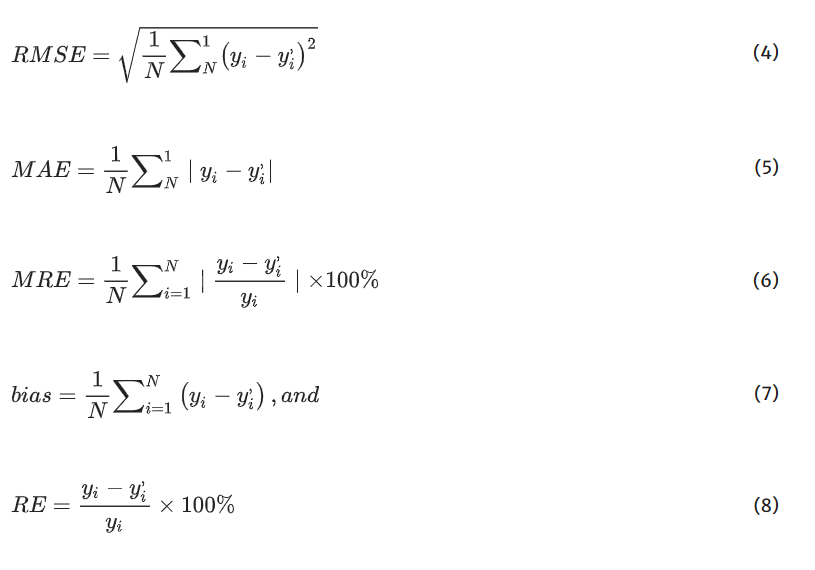

1. All secchi depth observations

In [ ]:
valid_idx1 = df_secchi_match['Secchi_Depth(m)'].notna() & df_secchi_match['satellite_ZSD'].notna()
y_insitu1 = df_secchi_match.loc[valid_idx1, 'Secchi_Depth(m)']
y_sat1 = df_secchi_match.loc[valid_idx1, 'satellite_ZSD']

mean_bias1 = sum(y_sat1-y_insitu1)/len(y_sat1-y_insitu1)
mean_abs_err1 = sum(np.abs(y_sat1-y_insitu1))/len(y_sat1-y_insitu1)
mean_per_err1 = (sum(np.abs(y_sat1-y_insitu1)/y_insitu1)/ len(y_sat1-y_insitu1))*100
rmse1 = np.sqrt(sum((y_sat1-y_insitu1)**2)/len(y_sat1-y_insitu1))
count1 = len(y_sat1-y_insitu1)

In [ ]:
print(f"All observations:\nMean Bias: {mean_bias1:.2f} m\nMean Absolute Error: {mean_abs_err1:.2f} m\nMean Absolute Percentage Error: {mean_per_err1:.2f} %\nRMSE: {rmse1:.2f}  m\nCount: {count1}")

2. Where there are no notes for secchi depth, and the sample has an exact pixel match

In [ ]:
valid_obs = df_secchi_match[(df_secchi_match['notes_cleaned']=='Valid') & (df_secchi_match['outside_original_pixel'] == False)]

In [ ]:
valid_obs_idx2 = (df_secchi_match['notes_cleaned']=='Valid') & (df_secchi_match['outside_original_pixel'] == False) & df_secchi_match['Secchi_Depth(m)'].notna() & df_secchi_match['satellite_ZSD'].notna()

y_insitu2 = df_secchi_match.loc[valid_obs_idx2, 'Secchi_Depth(m)']
y_sat2 = df_secchi_match.loc[valid_obs_idx2, 'satellite_ZSD']

mean_bias2 = sum(y_sat2-y_insitu2)/len(y_sat2-y_insitu2)
mean_abs_err2 = sum(np.abs(y_sat2-y_insitu2))/len(y_sat2-y_insitu2)
mean_per_err2 = (sum(np.abs(y_sat2-y_insitu2)/y_insitu2)/ len(y_sat2-y_insitu2))*100
rmse2 = np.sqrt(sum((y_sat2-y_insitu2)**2)/len(y_sat2-y_insitu2))
count2 = len(y_sat2-y_insitu2)

In [ ]:
print(f"'Perfect' Samples and Exact Pixels: \nMean Bias: {mean_bias2:.2f} m\nMean Absolute Error: {mean_abs_err2:.2f} m\nMean Absolute Percentage Error: {mean_per_err2:.2f} %\nRMSE: {rmse2:.2f}  m\nCount: {count2}")

3. Samples that didn't hit bottom

In [ ]:
valid_obs_idx3 = (df_secchi_match['notes_cleaned']!='B')  & df_secchi_match['Secchi_Depth(m)'].notna() & df_secchi_match['satellite_ZSD'].notna()

y_insitu3 = df_secchi_match.loc[valid_obs_idx3, 'Secchi_Depth(m)']
y_sat3 = df_secchi_match.loc[valid_obs_idx3, 'satellite_ZSD']

mean_bias3 = sum(y_sat3-y_insitu3)/len(y_sat3-y_insitu3)
mean_abs_err3 = sum(np.abs(y_sat3-y_insitu3))/len(y_sat3-y_insitu3)
mean_per_err3 = (sum(np.abs(y_sat3-y_insitu3)/y_insitu3)/ len(y_sat3-y_insitu3))*100
rmse3 = np.sqrt(sum((y_sat3-y_insitu3)**2)/len(y_sat3-y_insitu3))
count3 = len(y_sat3-y_insitu3)

In [ ]:
print(f"Excluding those that hit bottom: \nMean Bias: {mean_bias3:.2f} m\nMean Absolute Error: {mean_abs_err3:.2f} m\nMean Absolute Percentage Error: {mean_per_err3:.2f} %\nRMSE: {rmse3:.2f}  m\nCount: {count3}")

4. Where nothing hit bottom and distance to pixel is <2000 m

In [ ]:
valid_obs_idx4 = (df_secchi_match['notes_cleaned'] != 'B') & (df_secchi_match['distance_to_pixel_m'] <= 2000) & df_secchi_match['Secchi_Depth(m)'].notna() & \
                 df_secchi_match['satellite_ZSD'].notna()

y_insitu4 = df_secchi_match.loc[valid_obs_idx4, 'Secchi_Depth(m)']
y_sat4 = df_secchi_match.loc[valid_obs_idx4, 'satellite_ZSD']

mean_bias4 = sum(y_sat4 - y_insitu4) / len(y_sat4 - y_insitu4)
mean_abs_err4 = sum(np.abs(y_sat4 - y_insitu4)) / len(y_sat4 - y_insitu4)
mean_per_err4 = (sum(np.abs(y_sat4-y_insitu4)/y_insitu4)/ len(y_sat4-y_insitu4))*100
rmse4 = np.sqrt(sum((y_sat4 - y_insitu4) ** 2) / len(y_sat4 - y_insitu4))
count4 = len(y_sat4 - y_insitu4)
print(
    f"Excluding those that hit bottom, and excluding satellite observations from over 2 km away: \nMean Bias: {mean_bias4:.2f} m\nMean Absolute Error: {mean_abs_err4:.2f} m\nMean Absolute Percentage Error: {mean_per_err4:.2f} %\nRMSE: {rmse4:.2f}  m\nCount: {count4}")

In [ ]:
df_secchi_match[df_secchi_match['notes_cleaned'] == 'B']

**For this one, was trying to see how the bottom-hit stations related to satellite, but all of them are far away from satellite pixels**


In [ ]:
valid_obs_idx5 = (df_secchi_match['notes_cleaned'] == 'B') & (df_secchi_match['distance_to_pixel_m'] <= 6000) & df_secchi_match['Secchi_Depth(m)'].notna() & df_secchi_match['satellite_ZSD'].notna()

y_insitu5 = df_secchi_match.loc[valid_obs_idx5, 'Secchi_Depth(m)']
y_sat5 = df_secchi_match.loc[valid_obs_idx5, 'satellite_ZSD']

## For this one, was trying to see how the bottom-hit stations related to satellite, but all of them are far away from satellite pixels
mean_bias5 = sum(y_sat5 - y_insitu5) / len(y_sat5 - y_insitu5)
mean_abs_err5 = sum(np.abs(y_sat5 - y_insitu5)) / len(y_sat5 - y_insitu5)
mean_per_err5 = (sum(np.abs(y_sat5 - y_insitu5)/y_insitu5)/ len(y_sat5 - y_insitu5))*100
rmse5 = np.sqrt(sum((y_sat5 - y_insitu5) ** 2) / len(y_sat5 - y_insitu5))
count5 = len(y_sat5 - y_insitu5)
print(
    f"Those that hit the bottom, and excluding satellite observations from over 6 km away: \nMean Bias: {mean_bias5:.2f} m\nMean Absolute Error: {mean_abs_err5:.2f} m\nMean Absolute Percentage Error: {mean_per_err5:.2f} %\nRMSE: {rmse5:.2f}  m\nCount: {count5}")
## didn't add this one in

**other statistics**

In [ ]:
sns.scatterplot(df_secchi_match[df_secchi_match['distance_to_pixel_m']<=2000], x='Secchi_Depth(m)', y='satellite_ZSD', hue='notes_cleaned')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# 1. Prepare data (ensure no NaNs for regression)
data = df_secchi_match.dropna(subset=['satellite_ZSD', 'Secchi_Depth(m)'])
x = data['Secchi_Depth(m)']
y = data['satellite_ZSD']

# 2. Calculate Statistics
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
spearman_rho, _ = stats.spearmanr(x, y)
r_squared = r_value**2

# 3. Plotting
plt.figure(figsize=(8, 6))
sns.regplot(x=x, y=y, scatter_kws={'alpha':0.6}, line_kws={'color':'red', 'label':f'y={slope:.2f}x + {intercept:.2f}'})

# Add 1:1 reference line
plt.plot([x.min(), x.max()], [x.min(), x.max()], 'k--', label='1:1 Line')

plt.title('Satellite $Z_{SD}$ vs. In-Situ $Z_{SD}$ Validation - All Observations')
plt.xlabel('In-Situ Secchi Depth (m)')
plt.ylabel('Satellite Secchi Depth (m)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

print(f"Regression Stats for All Observations:")
print(f"  R-squared: {r_squared:.3f}")
print(f"  Pearson r: {r_value:.3f}")
print(f"  Spearman rho: {spearman_rho:.3f}")
print(f"  Slope: {slope:.3f}")
print(f"  Intercept: {intercept:.3f}")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# 1. Prepare data (ensure no NaNs for regression)
data = df_secchi_match[(df_secchi_match['notes_cleaned']=='Valid') & (df_secchi_match['outside_original_pixel'] == False) & (df_secchi_match['Secchi_Depth(m)'].notna()) & (df_secchi_match['satellite_ZSD'].notna())]
x = data['Secchi_Depth(m)']
y = data['satellite_ZSD']

# 2. Calculate Statistics
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
spearman_rho, _ = stats.spearmanr(x, y)
r_squared = r_value**2

# 3. Plotting
plt.figure(figsize=(8, 6))
sns.regplot(x=x, y=y, scatter_kws={'alpha':0.6}, line_kws={'color':'red', 'label':f'y={slope:.2f}x + {intercept:.2f}'}, ci=None)

# Add 1:1 reference line
plt.plot([x.min(), x.max()], [x.min(), x.max()], 'k--', label='1:1 Line')

plt.title('Satellite $Z_{SD}$ vs. In-Situ $Z_{SD}$ Validation - Valid In-Situ and Exact Pixels')
plt.xlabel('In-Situ Secchi Depth (m)')
plt.ylabel('Satellite Secchi Depth (m)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

print(f"Regression Stats for Valid and Exact Pixels:")
print(f"  R-squared: {r_squared:.3f}")
print(f"  Pearson r: {r_value:.3f}")
print(f"  Spearman rho: {spearman_rho:.3f}")
print(f"  Slope: {slope:.3f}")
print(f"  Intercept: {intercept:.3f}")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# 1. Prepare data (ensure no NaNs for regression)
data = df_secchi_match[(df_secchi_match['notes_cleaned']!='B')  & (df_secchi_match['Secchi_Depth(m)'].notna()) & (df_secchi_match['satellite_ZSD'].notna())]
x = data['Secchi_Depth(m)']
y = data['satellite_ZSD']

# 2. Calculate Statistics
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
spearman_rho, _ = stats.spearmanr(x, y)
r_squared = r_value**2

# 3. Plotting
plt.figure(figsize=(8, 6))
sns.regplot(x=x, y=y, scatter_kws={'alpha':0.6}, line_kws={'color':'red', 'label':f'y={slope:.2f}x + {intercept:.2f}'})

# Add 1:1 reference line
plt.plot([x.min(), x.max()], [x.min(), x.max()], 'k--', label='1:1 Line')

plt.title('Satellite $Z_{SD}$ vs. In-Situ $Z_{SD}$ Validation - Excluding Bottom Hit')
plt.xlabel('In-Situ Secchi Depth (m)')
plt.ylabel('Satellite Secchi Depth (m)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

print(f"Regression Stats for No Bottom Hit:")
print(f"  R-squared: {r_squared:.3f}")
print(f"  Pearson r: {r_value:.3f}")
print(f"  Spearman rho: {spearman_rho:.3f}")
print(f"  Slope: {slope:.3f}")
print(f"  Intercept: {intercept:.3f}")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# 1. Prepare data (ensure no NaNs for regression)
data = df_secchi_match[(df_secchi_match['notes_cleaned'] != 'B') & (df_secchi_match['distance_to_pixel_m'] <= 2000) &  (df_secchi_match['Secchi_Depth(m)'].notna()) & (df_secchi_match['satellite_ZSD'].notna())]
x = data['Secchi_Depth(m)']
y = data['satellite_ZSD']

# 2. Calculate Statistics
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
spearman_rho, _ = stats.spearmanr(x, y)
r_squared = r_value**2

# 3. Plotting
plt.figure(figsize=(8, 6))
sns.regplot(x=x, y=y, scatter_kws={'alpha':0.6}, line_kws={'color':'red', 'label':f'y={slope:.2f}x + {intercept:.2f}'})

# Add 1:1 reference line
plt.plot([x.min(), x.max()], [x.min(), x.max()], 'k--', label='1:1 Line')

plt.title('Satellite $Z_{SD}$ vs. In-Situ $Z_{SD}$ Validation - No Bottom Hit and within 2km of Pixel Center')
plt.xlabel('In-Situ Secchi Depth (m)')
plt.ylabel('Satellite Secchi Depth (m)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

print(f"Regression Stats for No Bottom Hit and within 2km of another pixel center:")
print(f"  R-squared: {r_squared:.3f}")
print(f"  Pearson r: {r_value:.3f}")
print(f"  Spearman rho: {spearman_rho:.3f}")
print(f"  Slope: {slope:.3f}")
print(f"  Intercept: {intercept:.3f}")
plt.show()

In [ ]:
df_secchi_match[(df_secchi_match['notes_cleaned']=='Valid') & (df_secchi_match['outside_original_pixel'] == False) & (df_secchi_match['Secchi_Depth(m)'].notna()) & (df_secchi_match['satellite_ZSD'].notna())]

In [ ]:
df_secchi_match

### Facet Plots of Bland-Altman Charts and Maps

### Need to check normality first

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define your datasets in order
datasets = [
    {"y_sat": y_sat1, "y_insitu": y_insitu1, "title": "Set 1: All Stations"},
    {"y_sat": y_sat3, "y_insitu": y_insitu3, "title": "Set 2: No Bottom-Hit"},
    {"y_sat": y_sat4, "y_insitu": y_insitu4, "title": "Set 3: No Bottom-Hit, <= 2000m to Pixel Center"},
    {"y_sat": y_sat2, "y_insitu": y_insitu2, "title": "Set 4: Only Valid Samples and Exact Pixels"}
]

# 2. Setup a 2x2 Grid (sharex=True aligns the difference range across all 4 sets)
# sharey=False allows each subplot to auto-scale frequency since sample sizes (N=29 vs N=4) vary greatly
fig1, axes1 = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=False)
fig1.suptitle("Distribution of Differences (Satellite - In-Situ Secchi Depth)", fontsize=12, fontweight='bold', y=0.98)

for i, data in enumerate(datasets):
    # Determine grid coordinates
    row = i // 2
    col = i % 2
    ax = axes1[row, col]

    # Extract arrays
    y_sat = data["y_sat"].to_numpy() if hasattr(data["y_sat"], 'to_numpy') else np.array(data["y_sat"])
    y_insitu = data["y_insitu"].to_numpy() if hasattr(data["y_insitu"], 'to_numpy') else np.array(data["y_insitu"])
    raw_diff = y_sat - y_insitu

    # Compute metrics
    mean_raw = np.mean(raw_diff)
    std_raw = np.std(raw_diff, ddof=1) if len(raw_diff) > 1 else 0
    count = len(y_insitu)

    # Plot Histogram
    ax.hist(raw_diff, bins=8, color='#2c3e50', edgecolor='white', alpha=0.85)

    # Vertical guidelines
    ax.axvline(0, color='gray', linestyle=':', linewidth=1.2, label='Zero Difference')
    ax.axvline(mean_raw, color='#d9534f', linestyle='-', linewidth=1.5,
               label=f'Mean Diff: {mean_raw:.2f} m')
    ax.axvline(mean_raw + 1.96 * std_raw, color='#d9534f', linestyle='--', linewidth=1.0, alpha=0.7,
               label=f'±1.96 SD: [{mean_raw - 1.96 * std_raw:.2f}, {mean_raw + 1.96 * std_raw:.2f}]')
    ax.axvline(mean_raw - 1.96 * std_raw, color='#d9534f', linestyle='--', linewidth=1.0, alpha=0.7)

    # Formatting
    ax.set_title(f"{data['title']}\n(N = {count})", fontsize=10, pad=8)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(loc='upper left', fontsize=8, frameon=True, facecolor='white', edgecolor='none')

    # Axis labels
    if col == 0:
        ax.set_ylabel("Frequency", fontsize=9)
    if row == 1:
        ax.set_xlabel("Difference (Satellite - In-Situ) [m]", fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
#plt.savefig('C:/Users/25298423/PycharmProjects/FinalFigures/histogram_secchi_diff.png', dpi=1200)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import shapiro, normaltest, kstest

# 1. Define your datasets (matching your existing structure)
datasets = [
    {"y_sat": y_sat1, "y_insitu": y_insitu1, "title": "Set 1: All Stations"},
    {"y_sat": y_sat3, "y_insitu": y_insitu3, "title": "Set 2: No Bottom-Hit"},
    {"y_sat": y_sat4, "y_insitu": y_insitu4, "title": "Set 3: No Bottom-Hit, <= 2000m to Pixel Center"},
    {"y_sat": y_sat2, "y_insitu": y_insitu2, "title": "Set 4: Only Valid Samples and Exact Pixels"}
]

results = []

for data in datasets:
    # Convert inputs to numpy arrays and calculate difference (Satellite - In-Situ)
    y_sat = np.asarray(data["y_sat"])
    y_insitu = np.asarray(data["y_insitu"])
    diff = y_sat - y_insitu

    n = len(diff)

    # --- Shapiro-Wilk Test (Method 13) ---
    # Most powerful test for small sample sizes (N < 50)
    if n >= 3:
        stat_sw, p_sw = shapiro(diff)
        norm_sw = "Reject Normality (p < 0.05)" if p_sw < 0.05 else "Normally Distributed (p >= 0.05)"
    else:
        stat_sw, p_sw, norm_sw = np.nan, np.nan, "N too small (N < 3)"

    # --- D'Agostino-Pearson Test (Method 14) ---
    # Requires at least N >= 8 observations
    if n >= 8:
        stat_dag, p_dag = normaltest(diff)
    else:
        stat_dag, p_dag = np.nan, np.nan

    # --- Kolmogorov-Smirnov Test (Method 15) ---
    # Comparing against a fitted normal distribution
    if n > 0:
        stat_ks, p_ks = kstest(diff, 'norm', args=(np.mean(diff), np.std(diff, ddof=1)))
    else:
        stat_ks, p_ks = np.nan, np.nan

    results.append({
        "Dataset": data["title"],
        "N": n,
        "Shapiro-W Stat": round(stat_sw, 4) if not np.isnan(stat_sw) else np.nan,
        "Shapiro p-val": round(p_sw, 4) if not np.isnan(p_sw) else np.nan,
        "D'Agostino p-val": round(p_dag, 4) if not np.isnan(p_dag) else np.nan,
        "K-S p-val": round(p_ks, 4) if not np.isnan(p_ks) else np.nan,
        "Shapiro Conclusion (alpha=0.05)": norm_sw
    })

# Convert summary into a readable DataFrame
df_normality = pd.DataFrame(results)
print(df_normality.to_string(index=False))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define your datasets in order
datasets = [
    {"y_sat": y_sat1, "y_insitu": y_insitu1, "title": "Set 1: All Stations"},
    {"y_sat": y_sat3, "y_insitu": y_insitu3, "title": "Set 2: No Bottom-Hit"},
    {"y_sat": y_sat4, "y_insitu": y_insitu4, "title": "Set 3: No Bottom-Hit, <= 2000m to Pixel Center"},
    {"y_sat": y_sat2, "y_insitu": y_insitu2, "title": "Set 4: Only Valid Samples and Exact Pixels"}
]

# 2. Setup a 2x2 Grid with Shared Axes for perfect comparison
fig1, axes1 = plt.subplots(2, 2, figsize=(9, 7), sharex=True, sharey=True)
fig1.suptitle("Secchi Depth Bland-Altman Agreement Analysis (Raw Difference vs. In-Situ)", fontsize=12, fontweight='bold', y=0.92)

for i, data in enumerate(datasets):
    # Determine grid coordinates: (0,0), (0,1), (1,0), (1,1)
    row = i // 2
    col = i % 2
    ax = axes1[row, col]

    # Extract arrays
    y_sat = data["y_sat"].to_numpy()
    y_insitu = data["y_insitu"].to_numpy()
    raw_diff = y_sat - y_insitu

    # Compute metrics
    mean_raw = np.mean(raw_diff)
    std_raw = np.std(raw_diff, ddof=1)
    count = len(y_insitu)

    # Scatter points
    ax.scatter(y_insitu, raw_diff, alpha=0.75, color='#2c3e50', edgecolors='none', s=45)

    # Horizontal guidelines
    ax.axhline(0, color='gray', linestyle=':', alpha=0.6)
    ax.axhline(mean_raw, color='#d9534f', linestyle='-', linewidth=1.5,
               label=f'Mean Diff.: {mean_raw:.2f} m')
    ax.axhline(mean_raw + 1.96 * std_raw, color='#d9534f', linestyle='--', linewidth=1.2,
               label=f'+1.96 SD: {mean_raw + 1.96 * std_raw:.2f} m')
    ax.axhline(mean_raw - 1.96 * std_raw, color='#d9534f', linestyle='--', linewidth=1.2,
               label=f'-1.96 SD: {mean_raw - 1.96 * std_raw:.2f} m')

    # Formatting
    ax.set_title(f"{data['title']}\n(N = {count})", fontsize=10, pad=8)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(loc='upper right', fontsize=9, frameon=True, facecolor='white', edgecolor='none')

    # Axis labels: Only write them on the edges to keep the plot clean
    if col == 0:
        ax.set_ylabel("Difference (Satellite - In-Situ) [m]", fontsize=9)
    if row == 1:
        ax.set_xlabel("In-Situ Secchi Depth (m)", fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('C:/Users/25298423/PycharmProjects/FinalFigures/blandaltman_secchi.png', dpi=1200)
plt.show()

In [ ]:
# Setup a 2x2 Grid for Percentage Differences with Shared Axes
fig2, axes2 = plt.subplots(2, 2, figsize=(9,7), sharex=True, sharey=True)
fig2.suptitle("Percentage Bland-Altman (Relative Difference vs. In-Situ)", fontsize=12, fontweight='bold', y=0.92)

for i, data in enumerate(datasets):
    row = i // 2
    col = i % 2
    ax = axes2[row, col]

    y_sat = data["y_sat"].to_numpy()
    y_insitu = data["y_insitu"].to_numpy()
    pct_diff = ((y_sat - y_insitu) / y_insitu) * 100

    # Compute metrics
    mean_pct = np.mean(pct_diff)
    std_pct = np.std(pct_diff, ddof=1)
    count = len(y_insitu)

    # Scatter points
    ax.scatter(y_insitu, pct_diff, alpha=0.75, color='#1a5276', edgecolors='none', s=45)

    # Horizontal guidelines
    ax.axhline(0, color='gray', linestyle=':', alpha=0.6)
    ax.axhline(mean_pct, color='#d9534f', linestyle='-', linewidth=1.5,
               label=f'Bias: {mean_pct:.1f}%')
    ax.axhline(mean_pct + 1.96 * std_pct, color='#d9534f', linestyle='--', linewidth=1.2,
               label=f'+1.96 SD: {mean_pct + 1.96 * std_pct:.1f}%')
    ax.axhline(mean_pct - 1.96 * std_pct, color='#d9534f', linestyle='--', linewidth=1.2,
               label=f'-1.96 SD: {mean_pct - 1.96 * std_pct:.1f}%')

    # Formatting
    ax.set_title(f"{data['title']}\n(N = {count})", fontsize=10, pad=8)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(loc='upper right', fontsize=9, frameon=True, facecolor='white', edgecolor='none')

    # Axis labels: Only write them on the edges to keep the plot clean
    if col == 0:
        ax.set_ylabel("Relative Difference (%)", fontsize=9)
    if row == 1:
        ax.set_xlabel("In-Situ Secchi Depth (m)", fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('C:/Users/25298423/PycharmProjects/FinalFigures/blandaltman_percentage_secchi.png', dpi=1200)
plt.show()

Giavarina, 2015 recommends that if there is a lack of normality in dataset, to do a log-transformation of the data prior to bland altman

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define your datasets in order (Method A = y_sat, Method B = y_insitu)
datasets = [
    {"y_sat": y_sat1, "y_insitu": y_insitu1, "title": "Set 1: All Stations"},
    {"y_sat": y_sat3, "y_insitu": y_insitu3, "title": "Set 2: No Bottom-Hit"},
    {"y_sat": y_sat4, "y_insitu": y_insitu4, "title": "Set 3: No Bottom-Hit, <= 2000m to Pixel Center"},
    {"y_sat": y_sat2, "y_insitu": y_insitu2, "title": "Set 4: Only Valid Samples and Exact Pixels"}
]

# 2. Setup 2x2 Grid
fig1, axes1 = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
fig1.suptitle("Natural Log-Transformed Bland-Altman Agreement Analysis", fontsize=12, fontweight='bold', y=0.93)

for i, data in enumerate(datasets):
    row = i // 2
    col = i % 2
    ax = axes1[row, col]

    # Extract strictly positive paired measurements (X_i = Method A, Y_i = Method B)
    X = data["y_sat"].to_numpy() if hasattr(data["y_sat"], 'to_numpy') else np.array(data["y_sat"])
    Y = data["y_insitu"].to_numpy() if hasattr(data["y_insitu"], 'to_numpy') else np.array(data["y_insitu"])

    # Step 1: Natural log transformation x_i = ln(X_i), y_i = ln(Y_i)
    x = np.log(X)
    y = np.log(Y)

    # Step 2: Compute paired log difference d_i and log mean m_i
    d = x - y
    m = (x + y) / 2.0

    # Step 3: Compute bias and limits of agreement on the log scale
    n = len(d)
    d_bar = np.mean(d)
    s_d = np.std(d, ddof=1) if n > 1 else 0.0

    lower_loa_log = d_bar - 1.96 * s_d
    upper_loa_log = d_bar + 1.96 * s_d

    # Step 4: Back-transform via exponentiation (e^x) to get geometric mean ratios
    bias_ratio = np.exp(d_bar)
    lower_ratio_loa = np.exp(lower_loa_log)
    upper_ratio_loa = np.exp(upper_loa_log)

    # Convert ratio bias to percentage difference (e.g., ratio 0.70 -> -30.0%)
    pct_bias = (bias_ratio - 1.0) * 100.0

    # Step 5: Plot log difference (d_i) vs log mean (m_i)
    ax.scatter(m, d, alpha=0.75, color='#2c3e50', edgecolors='none', s=45)

    # Horizontal guidelines on log scale with back-transformed annotations
    ax.axhline(0, color='gray', linestyle=':', alpha=0.6, label='Ratio = 1.00 (0% Diff)')
    ax.axhline(d_bar, color='#d9534f', linestyle='-', linewidth=1.5,
               label=f'Bias Ratio: {bias_ratio:.2f} ({pct_bias:+.1f}%)')
    ax.axhline(upper_loa_log, color='#d9534f', linestyle='--', linewidth=1.2,
               label=f'Upper Ratio LoA: {upper_ratio_loa:.2f}')
    ax.axhline(lower_loa_log, color='#d9534f', linestyle='--', linewidth=1.2,
               label=f'Lower Ratio LoA: {lower_ratio_loa:.2f}')

    # Formatting
    ax.set_title(f"{data['title']}\n(N = {n})", fontsize=10, pad=8)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(loc='upper right', fontsize=8, frameon=True, facecolor='white', edgecolor='none')

    # Axis labels
    if col == 0:
        ax.set_ylabel(r"Log Difference $d_i = \ln(\mathrm{Sat}) - \ln(\mathrm{In\text{-}Situ})$", fontsize=9)
    if row == 1:
        ax.set_xlabel(r"Log Mean $m_i = [\ln(\mathrm{Sat}) + \ln(\mathrm{In\text{-}Situ})] / 2$", fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('C:/Users/25298423/PycharmProjects/FinalFigures/blandaltman_secchi_log.png', dpi=1200)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import seaborn as sns
import pandas as pd
unique_dates = sorted(df_secchi_match['Date'].dt.strftime('%Y-%m-%d').unique())

# 2. Setup a 3x2 Subplot Grid with the new compact 14x14 dimensions
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

# Retrieve the original 'mako' colormap
original_cmap = plt.colormaps['mako']
# Extract colors from 10% to 80% of the range (chopping off the bottom 10% and top 20%)
colors = original_cmap(np.linspace(0.32, 0.80, 256))
# Create a brand new, custom colormap from this high-contrast slice
truncated_mako = mcolors.LinearSegmentedColormap.from_list('truncated_mako', colors)

for i, date_str in enumerate(unique_dates):
    ax = axes[i]

    # --- A. Plot the Satellite ZSD background ---
    try:
        zsd_day = zsd_is['ZSD'].sel(time=date_str)
        im = zsd_day.plot(ax=ax, add_colorbar=False, cmap=truncated_mako, vmin=0, vmax=12)
    except KeyError:
        print(f"Warning: No satellite data found in zsd_is for date: {date_str}")

    # --- B. Plot the Landmass ---
    landmass.plot(ax=ax, facecolor='#EAEAF2', edgecolor='#808080', linewidth=0.25, zorder=2)

    # --- C. Filter and Plot the In-Situ Stations ---
    df_day = df_secchi_match[(df_secchi_match['Date'].dt.strftime('%Y-%m-%d') == date_str) & (df_secchi_match['Secchi_Depth(m)'].notna())]

    if not df_day.empty:
        sns.scatterplot(
            data=df_day,
            x='longitude_dec',
            y='latitude_dec',
            ax=ax,
            c=df_day['Secchi_Depth(m)'],
            cmap=truncated_mako,
            vmin=0,
            vmax=12,
            edgecolor='white',
            linewidth=1.0,
            s=90,  # Keep high-visibility marker size
            alpha=0.9,
            zorder=3,
        )
        # --- C.2 DYNAMIC BOUNDING BOX AROUND SAMPLE CLUSTER ---
        # Get coordinates of the cluster
        min_lon, max_lon = df_day['longitude_dec'].min(), df_day['longitude_dec'].max()
        min_lat, max_lat = df_day['latitude_dec'].min(), df_day['latitude_dec'].max()

        # Add a tiny buffer so the box has some breathing room around the outer markers
        pad_lon = 0.03
        pad_lat = 0.025

        box_x = min_lon - pad_lon
        box_y = min_lat - pad_lat
        box_width = (max_lon - min_lon) + (2 * pad_lon)
        box_height = (max_lat - min_lat) + (2 * pad_lat)

        # Draw a clean, professional dashed red or dark slate box
        rect = patches.Rectangle(
            (box_x, box_y), box_width, box_height,
            linewidth=1.5,
            edgecolor='#D95F02',  # Muted vermilion red so it stands out beautifully
            facecolor='none',     # Transparent fill
            linestyle='--',       # Dashed line
            zorder=3              # Just below the markers but above the land
        )
        ax.add_patch(rect)

    # --- D. Formatting each Panel ---
    ax.set_title(pd.to_datetime(date_str).strftime('%B %d, %Y'), fontsize=13, pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(True, linestyle='--', alpha=0.3)

    # Custom zoom coordinates
    ax.set_ylim(53.1, 53.4)
    ax.set_xlim(-9.75, -8.9)

# 3. Add a single, shared colorbar for the ZSD satellite values on the right
# Re-scaled bounds [bottom, height] to fit the new 14-inch height beautifully
cbar_ax = fig.add_axes([0.91, 0.10, 0.018, 0.78])
fig.colorbar(im, cax=cbar_ax, label='Secchi Depth $Z_{SD}$ (m)')

# 4. Clean up the unused 6th subplot (bottom right)
axes[5].axis('off')
axes[3].xaxis.set_tick_params(labelbottom=True)
# 5. Global styling adjustments
fig.suptitle("Spatial Matchups by Sampling Campaign", fontsize=18, fontweight='bold', y=0.98)

# Decreased hspace to 0.30 to remove the huge vertical gaps between rows
plt.subplots_adjust(right=0.88, left=0.08, bottom=0.08, top=0.91, hspace=0.20, wspace=0.15)
plt.savefig('C:/Users/25298423/PycharmProjects/FinalFigures/mappings_in_situ_and_satellite.png', dpi=1200)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Get the unique sampling dates sorted chronologically
unique_dates = sorted(df_secchi_match['Date'].dt.strftime('%Y-%m-%d').unique())

# 2. Setup a 3x2 Subplot Grid with the new compact 14x14 dimensions
fig, axes = plt.subplots(3, 2, figsize=(14, 14), sharex=True, sharey=True)
axes = axes.flatten()

# Retrieve the original 'mako' colormap
original_cmap = plt.colormaps['mako']
# Extract colors from 10% to 80% of the range (chopping off the bottom 10% and top 20%)
colors = original_cmap(np.linspace(0.32, 0.80, 256))
# Create a brand new, custom colormap from this high-contrast slice
truncated_mako = mcolors.LinearSegmentedColormap.from_list('truncated_mako', colors)

monochrome_cmaps = ['Reds', 'Purples', 'Oranges', 'Greens', 'Blues']

for i, date_str in enumerate(unique_dates):
    ax = axes[i]

    # --- A. Plot the Satellite ZSD background ---
    try:
        zsd_day = zsd_is['ZSD'].sel(time=date_str)
        im = zsd_day.plot(ax=ax, add_colorbar=False, cmap=truncated_mako, vmin=0, vmax=12)
    except KeyError:
        print(f"Warning: No satellite data found in zsd_is for date: {date_str}")

    # --- B. Plot the Landmass ---
    landmass.plot(ax=ax, facecolor='#EAEAF2', edgecolor='#808080', linewidth=0.25, zorder=2)

    # --- C. Filter and Plot the In-Situ Stations ---
    df_day = df_secchi_match[df_secchi_match['Date'].dt.strftime('%Y-%m-%d') == date_str]

    if not df_day.empty:
        # Determine unique sites for this day
        unique_sites = sorted(df_day['Site'].unique())
        num_sites = len(unique_sites)

        # Select the sequential colormap for this day
        day_cmap = plt.colormaps[monochrome_cmaps[i % len(monochrome_cmaps)]]

        # Generate a monochrome color gradient (skipping the very pale starting colors for visibility)
        color_seq = day_cmap(np.linspace(0.4, 0.9, num_sites))
        day_palette = dict(zip(unique_sites, color_seq))

        sns.scatterplot(
            data=df_day,
            x='longitude_dec',
            y='latitude_dec',
            ax=ax,
            hue='Site',
            palette= day_palette,
            linewidth=1.0,
            edgecolor='white',
            s=110,  # Keep high-visibility marker size
            zorder=3,
        )

        # Calculate horizontal columns for the legend
        num_sites = len(df_day['Site'].unique())
        legend_cols = min(5, num_sites)

        # Place legend directly below the individual plot axis
        # Adjusted slightly to fit the tighter 14x14 spacing cleanly
        ax.legend(
            title='Stations',
            loc='upper center',
            bbox_to_anchor=(0.5, -0.08),
            ncol=legend_cols,
            fontsize=9,
            title_fontsize=9.5,
            frameon=True,
            facecolor='white',
            edgecolor='#cccccc'
        )

    # --- D. Formatting each Panel ---
    ax.set_title(pd.to_datetime(date_str).strftime('%B %d, %Y'), fontsize=13, pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(True, linestyle='--', alpha=0.3)

    # Custom zoom coordinates
    ax.set_ylim(53.1, 53.4)
    ax.set_xlim(-9.75, -8.9)

# 3. Add a single, shared colorbar for the ZSD satellite values on the right
# Re-scaled bounds [bottom, height] to fit the new 14-inch height beautifully
cbar_ax = fig.add_axes([0.91, 0.10, 0.018, 0.78])
fig.colorbar(im, cax=cbar_ax, label='Satellite $Z_{SD}$ (m)')

# 4. Clean up the unused 6th subplot (bottom right)
axes[5].axis('off')

# 5. Global styling adjustments
fig.suptitle("Spatial Matchups by Sampling Campaign", fontsize=18, fontweight='bold', y=0.96)

# Decreased hspace to 0.30 to remove the huge vertical gaps between rows
plt.subplots_adjust(right=0.88, left=0.08, bottom=0.08, top=0.91, hspace=0.50, wspace=0.15)
plt.savefig('C:/Users/25298423/PycharmProjects/FinalFigures/mappingsitesandpixels.png', dpi=1200)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Get ALL unique sampling dates
unique_dates = sorted(df_secchi_match['Date'].dt.strftime('%Y-%m-%d').unique())

# 2. Setup a 5x2 Subplot Grid (5 rows for 5 dates)
fig, axes = plt.subplots(5, 2, figsize=(10, 20)) #, sharex=True, sharey=True)

# Define regional limits
lon_min, lon_max = -9.8, -8.8
lat_min, lat_max = 52.8, 53.5

# Define a distinct color for every campaign row
row_colors = ['#D95F02', '#7570B3', '#1B9E77', '#E7298A', '#66A61E']

for row, date_str in enumerate(unique_dates):
    # Select the correct axes for this row
    ax_1k = axes[row, 0]
    ax_300 = axes[row, 1]

    df_day = df_secchi_match[df_secchi_match['Date'].dt.strftime('%Y-%m-%d') == date_str]
    formatted_date = pd.to_datetime(date_str).strftime('%B %d, %Y')

    # --- 1km Side ---
    landmass.plot(ax=ax_1k, facecolor='#EAEAF2', edgecolor='#808080', linewidth=0.5, zorder=1)
    zsd_mask = zsd_is['ZSD'].sel(time=date_str).notnull()
    zsd_mask.plot(ax=ax_1k, add_colorbar=False, cmap='Greys', alpha=0.3, zorder=2)
    ax_1k.scatter(df_day['longitude_dec'], df_day['latitude_dec'],
                  facecolor='none', edgecolor=row_colors[row], s=60, alpha=0.75, zorder=4)
    ax_1k.set_title(f"{formatted_date} — 1 km Resolution", fontsize=12)
    ax_1k.set_ylabel('Latitude')
    ax_1k.set_xlabel('Longitude')
    # --- 300m Side ---
    landmass.plot(ax=ax_300, facecolor='#EAEAF2', edgecolor='#808080', linewidth=0.5, zorder=1)
    olci_mask = rrs490_is['RRS490'].sel(time=date_str).notnull()
    olci_mask.plot(ax=ax_300, add_colorbar=False, cmap='Blues', alpha=0.3, zorder=2)
    ax_300.scatter(df_day['longitude_dec'], df_day['latitude_dec'],
                   facecolor='none', edgecolor=row_colors[row], s=60, alpha=0.75, zorder=4)
    ax_300.set_title(f"{formatted_date} — 300 m OLCI", fontsize=12)
    ax_300.set_ylabel('Latitude')
    ax_300.set_xlabel('Longitude')
# Formatting
fig.suptitle("Comprehensive Spatial Matchup Feasibility (1 km vs 300 m)", fontsize=18, fontweight='bold', y=0.98)
plt.subplots_adjust(left=0.08, right=0.94, bottom=0.05, top=0.94, hspace=0.25, wspace=0.05)
plt.savefig('C:/Users/25298423/PycharmProjects/FinalFigures/spatial_resolution_comparison_colored.png', dpi=600, bbox_inches='tight')
plt.show()

## Rrs Validation! Abandoned
(this is the first attempt, I was using a merged OLCI data product, but later switched to the direct S3A and S3B OLCI products due to greater coverage and timestamps)

In [ ]:
## load in all_site_means
all_site_means = pd.read_csv('hyperspectral_sampling_means.csv')
all_site_means.head()

In [ ]:
# 1. Ensure your station data is prepared
# We use a copy so we don't mess up your original 'all_site_means'
results_df = all_site_means.rename(columns={
    'Latitude': 'latitude_dec',
    'Longitude': 'longitude_dec'
}).copy()

# 2. Iterate through your bands and use the reliable function
bands = [400, 412, 443, 490, 510, 560, 620, 665, 674, 681, 709]

for band in bands:
    folder_path = os.path.join('/home/jovyan/notmessedup_directory/in-situ/', f'RRS{band}')
    files = glob.glob(os.path.join(folder_path, '*.nc'))

    if files:
        ds = xr.open_dataset(files[0])
        var_name = f'RRS{band}'

        # This function looks for the NEAREST pixel (not exact)
        # and adds a new column 'satellite_RRSxxx' to your dataframe
        results_df = extract_dynamic_daily_matches(ds, var_name, results_df)

        ds.close()
    else:
        print(f"Warning: No file found for band {band}")

# 3. Check the results
print("Columns in your new dataframe:", results_df.columns)
print("Number of rows with satellite data:", results_df['satellite_RRS400'].notna().sum())

In [ ]:
results_df

In [ ]:
results_df['cloudy_day'] = False

# 2. Update the rows where the Date matches 2026-05-10
# We convert the column to datetime objects first to ensure a reliable match
results_df['cloudy_day'] = pd.to_datetime(results_df['Date']) == pd.to_datetime('2026-05-10')

# 3. Verify it worked
print(f"Total cloudy day stations marked: {results_df['cloudy_day'].sum()}")

In [ ]:
list(results_df.columns)

In [ ]:
compare_rs_df = results_df[['Site','Date','latitude_dec','longitude_dec','cloudy_day','400','412','443','490','510','560','620','665','674','681','709','snapped_pixel_lat',
 'snapped_pixel_lon',
 'distance_to_pixel_m',
 'satellite_RRS400',
 'outside_original_pixel',
 'pixel_lat_min',
 'pixel_lat_max',
 'pixel_lon_min',
 'pixel_lon_max',
 'satellite_RRS412',
 'satellite_RRS443',
 'satellite_RRS490',
 'satellite_RRS510',
 'satellite_RRS560',
 'satellite_RRS620',
 'satellite_RRS665',
 'satellite_RRS674',
 'satellite_RRS681',
 'satellite_RRS709']]

In [ ]:
compare_rs_df

In [ ]:
# Create a list of the bands you want to compare
bands = [400, 412, 443, 490, 510, 560, 620, 665, 674, 681, 709]

# This compares row-by-row automatically
for band in bands:
    compare_rs_df[f'Diff_RRS{band}'] = compare_rs_df[f'satellite_RRS{band}'] - compare_rs_df[f'{band}']

In [ ]:
compare_rs_df

In [ ]:
import matplotlib.pyplot as plt

# 1. Select the row you want to visualize (change 0 to any station index)
idx = 0
row = results_df.iloc[0]

# 2. Define the bands
bands = [400, 412, 443, 490, 510, 560, 620, 665, 674, 681, 709]

# 3. Extract the values for the X and Y axes
in_situ_vals = [row[f'{band}'] for band in bands]
sat_vals = [row[f'satellite_RRS{band}'] for band in bands]

# 4. Plot
plt.figure(figsize=(10, 6))

# Plot In-Situ
plt.plot(bands, in_situ_vals, marker='o', linestyle='-', color='blue', label='In-Situ')

# Plot Satellite
plt.plot(bands, sat_vals, marker='s', linestyle='--', color='red', label='Satellite')

# Formatting
plt.xlabel('Wavelength (nm)')
plt.ylabel('RRS Value')
plt.title(f'Spectral Curve Comparison - Station Index {idx}')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# 1. Select the row
idx = 0
row = results_df.iloc[0]

# 2. Define the full wavelength range (320-950)
all_wavelengths = [int(col) for col in results_df.columns if col.isdigit() and 320 <= int(col) <= 950]
all_wavelengths.sort()

# 3. Define your band list (the specific markers you want to highlight)
bands = [400, 412, 443, 490, 510, 560, 620, 665, 674, 681, 709]

# 4. Extract values
# Full spectrum (In-situ is assumed to be the base columns)
full_spectrum = [row[str(w)] for w in all_wavelengths]

# Band-specific values for satellite and in-situ
in_situ_band_vals = [row[f'{band}'] for band in bands]
sat_band_vals = [row[f'satellite_RRS{band}'] for band in bands]

# 5. Plotting
plt.figure(figsize=(12, 6))

# Plot full in-situ spectrum as a light background line
plt.plot(all_wavelengths, full_spectrum, color='gray', alpha=0.5, label='Full In-Situ Spectrum')

# Plot in-situ band markers
plt.plot(bands, in_situ_band_vals, 'o-', color='blue', label='In-Situ Band Points', markersize=8)

# Plot satellite band markers
plt.plot(bands, sat_band_vals, 's--', color='red', label='Satellite Band Points', markersize=8)
plt.ylim(0,0.0042)
plt.xlabel('Wavelength (nm)')
plt.ylabel('RRS Value')
plt.title(f'Spectral Reflectance: Row {idx}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
# 1. Define bands and wavelength range
bands = [400, 412, 443, 490, 510, 560, 620, 665, 674, 681, 709]
all_wavelengths = [int(col) for col in results_df.columns if col.isdigit() and 320 <= int(col) <= 950]
all_wavelengths.sort()

# 2. Loop through every row in your dataframe
for idx, row in results_df.iterrows():
    # Gather info for the title
    site_name = row.get('Site', 'Unknown Site') # Adjust 'Site' to your column name
    date_val = str(row['Date'])
    outside_flag = row['outside_original_pixel']
    distance = row['distance_to_pixel_m']
    cloud = row['cloudy_day']
    # 3. Extract values
    full_spectrum = [row[str(w)] for w in all_wavelengths]
    in_situ_band_vals = [row[str(band)] for band in bands]
    sat_band_vals = [row[f'satellite_RRS{band}'] for band in bands]

    # 4. Plotting
    plt.figure(figsize=(10, 5))

    plt.plot(all_wavelengths, full_spectrum, color='gray', alpha=0.4, label='Full In-Situ Spectrum')
    plt.plot(bands, in_situ_band_vals, 'o-', color='blue', label='In-Situ Band Points')
    plt.plot(bands, sat_band_vals, 's--', color='red', label='Satellite Band Points')

    # Formatting title with your requirements
    status = "OUTSIDE PIXEL" if outside_flag else "INSIDE PIXEL"
    plt.title(f"Site: {site_name} | Date: {date_val} | Status: {status} | Distance: {distance:.0f} m | Cloud: {cloud}")

    plt.ylim(0)

# 2. Force the grid to have fixed intervals of 0.0005
    plt.gca().yaxis.set_major_locator(MultipleLocator(0.0005))



    plt.xlabel('Wavelength (nm)')
    plt.ylabel('RRS Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Show the plot
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

def create_facet_grid_custom(data, rows, cols, title_suffix):
    fig, axes = plt.subplots(rows, cols, figsize=(20, 16), sharex=True, sharey=True)
    axes = axes.flatten()

    for i, (idx, row) in enumerate(data.iterrows()):
        ax = axes[i]

        # Plot In-Situ (Full Spectrum and Band Points)
        ax.plot(all_wavelengths, [row[str(w)] for w in all_wavelengths], color='gray', alpha=0.3)
        ax.plot(bands, [row[str(band)] for band in bands], 'o-', color='blue', markersize=3, label='In-Situ')

        # Plot Satellite Band Points
        ax.plot(bands, [row[f'satellite_RRS{band}'] for band in bands], 's--', color='red', markersize=3, label='Satellite')

        # Formatting
        status = "OUTSIDE PIXEL" if row['outside_original_pixel'] else "INSIDE PIXEL"
        dist = row['distance_to_pixel_m']
        cloud = row['cloudy_day']
        ax.set_title(f"{row['Site']} | {status}\nDist: {dist:.0f}m | Cloud: {cloud}", fontsize=8)

        ax.yaxis.set_major_locator(MultipleLocator(0.0005))
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_ylim(bottom=0)

    # Hide extra axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    line_insitu, = ax.plot([], [], 'o-', color='blue', label='In-Situ')
    line_sat, = ax.plot([], [], 's--', color='red', label='Satellite')

    fig.legend(handles=[line_insitu, line_sat], loc='upper center',
               bbox_to_anchor=(0.5, 1.02), ncol=2, fontsize=12)

    plt.suptitle(f'RRS Comparison: {title_suffix}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'RRS_comparison_{title_suffix}.png', dpi=1200)
    plt.show()

# Run the split
create_facet_grid_custom(results_df.iloc[0:16], 4, 4, "Part 1 (Sites 1-16)")
create_facet_grid_custom(results_df.iloc[16:33], 4, 5, "Part 2 (Sites 17-33)")

**Looks as though there are cloud and atmospheric issues for the satellite data, going to try to find the pixels surrounding the inside pixel to see if that changes anything**

In [ ]:
##KEEP

def extract_neighborhood_matches(ds, var_name, df):
    # Prepare columns
    for i in range(5):
        df[f'satellite{i}_{var_name}'] = float('nan')


    lat_spacing = np.abs(np.diff(ds.latitude.values).mean()) / 2.0
    lon_spacing = np.abs(np.diff(ds.longitude.values).mean()) / 2.0

    for idx, row in df.iterrows():
        # 1. Filter the dataset to the date
        try:
            ds_daily = ds.sel(time=row['Date'], method='nearest')
        except (KeyError, ValueError):
            ds_daily = ds

        # 2. Find the anchor (The NEAREST pixel center)
        anchor = ds_daily.sel(latitude=row['latitude_dec'],
                              longitude=row['longitude_dec'],
                              method='nearest')

        # 3. Get the integer indices using numpy.where
        # This is safe and avoids pandas indexing errors
        lat_idx = np.where(ds_daily.latitude.values == anchor.latitude.values)[0][0]
        lon_idx = np.where(ds_daily.longitude.values == anchor.longitude.values)[0][0]

        lat_min, lat_max = anchor.latitude.values - lat_spacing, anchor.latitude.values + lat_spacing
        lon_min, lon_max = anchor.longitude.values - lon_spacing, anchor.longitude.values + lon_spacing


        # 4. Extract the anchor and its neighbors
        coords = {
            0: (lat_idx, lon_idx),     # Center
            1: (lat_idx + 1, lon_idx), # North
            2: (lat_idx, lon_idx + 1), # East
            3: (lat_idx - 1, lon_idx), # South
            4: (lat_idx, lon_idx - 1)  # West
        }

        for i, (l_idx, n_idx) in coords.items():
            # Check bounds
            if 0 <= l_idx < len(ds_daily.latitude) and 0 <= n_idx < len(ds_daily.longitude):
                val = ds_daily[var_name].isel(latitude=l_idx, longitude=n_idx).values.item()
                df.at[idx, f'satellite{i}_{var_name}'] = val

    return df


In [ ]:
# 1. Ensure your station data is prepared
# We use a copy so we don't mess up your original 'all_site_means'
results_range_df = all_site_means.rename(columns={
    'Latitude': 'latitude_dec',
    'Longitude': 'longitude_dec'
}).copy()

# 2. Iterate through your bands and use the reliable function
bands = [400, 412, 443, 490, 510, 560, 620, 665, 674, 681, 709]

for band in bands:
    folder_path = os.path.join('/home/jovyan/notmessedup_directory/in-situ/', f'RRS{band}')
    files = glob.glob(os.path.join(folder_path, '*.nc'))

    if files:
        ds = xr.open_dataset(files[0])
        var_name = f'RRS{band}'

        # This function looks for the NEAREST pixel (not exact)
        # and adds a new column 'satellite_RRSxxx' to your dataframe
        results_range_df = extract_neighborhood_matches(ds, var_name, results_range_df)

        ds.close()
    else:
        print(f"Warning: No file found for band {band}")

# 3. Check the results
print("Columns in your new dataframe:", results_range_df.columns)
print("Number of rows with satellite data:", results_range_df['satellite0_RRS400'].notna().sum())

In [ ]:
results_range_df['outside_original_pixel'] = results_df['outside_original_pixel']
results_range_df['distance_to_nearest_pixel'] = results_df['distance_to_pixel_m']
results_range_df['cloudy_day'] = results_df['cloudy_day']

In [ ]:
results_df


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# 1. Define bands and wavelength range
bands = [400, 412, 443, 490, 510, 560, 620, 665, 674, 681, 709]
all_wavelengths = [int(col) for col in results_range_df.columns if col.isdigit() and 320 <= int(col) <= 950]
all_wavelengths.sort()

# Define neighbor labels and their colors/styles
# 0: Center, 1: North, 2: East, 3: South, 4: West
neighbor_styles = {
    0: {'label': 'Sat Center', 'color': 'red', 'marker': 's'},
    1: {'label': 'Sat North', 'color': '#fa9898', 'marker': '^'},
    2: {'label': 'Sat East', 'color': '#cc9797', 'marker': '>'},
    3: {'label': 'Sat South', 'color': '#732d2d', 'marker': 'v'},
    4: {'label': 'Sat West', 'color': '#cc6262', 'marker': '<'}
}

# 2. Loop through every row
for idx, row in results_range_df.iterrows():
    site_name = row.get('Site', 'Unknown Site')
    date_val = str(row['Date'])
    outside_flag = row['outside_original_pixel']
    distance_flag = row['distance_to_nearest_pixel']
    cloud_flag = row['cloudy_day']
    plt.figure(figsize=(12, 6))

    # Plot In-Situ data
    full_spectrum = [row[str(w)] for w in all_wavelengths]
    plt.plot(all_wavelengths, full_spectrum, color='gray', alpha=0.3, label='Full In-Situ Spectrum')
    plt.plot(bands, [row[str(band)] for band in bands], 'o-', color='blue', label='In-Situ Band Points', zorder=10)

    # Plot all 5 Satellite pixels
    for i in range(5):
        sat_vals = [row.get(f'satellite{i}_RRS{band}', np.nan) for band in bands]
        plt.plot(bands, sat_vals, linestyle='--', marker=neighbor_styles[i]['marker'],
                 color=neighbor_styles[i]['color'], alpha=0.8, label=neighbor_styles[i]['label'])
    status = "OUTSIDE PIXEL" if outside_flag else "INSIDE PIXEL"
    plt.title(f"Site: {site_name} | Date: {date_val} | Status: {status} | Distance to Nearest Pixel: {distance_flag:.0f} m | Cloud: {cloud_flag}")
    plt.ylim(0)
    plt.gca().yaxis.set_major_locator(MultipleLocator(0.0005))
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('RRS Value')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside to avoid crowding
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt

def create_facet_grid(data_subset, rows, cols, title_suffix):
    fig, axes = plt.subplots(rows, cols, figsize=(16, 12), sharex=True, sharey=True)
    axes = axes.flatten()

    for i, (idx, row) in enumerate(data_subset.iterrows()):
        ax = axes[i]

        # Plot In-Situ
        ax.plot(all_wavelengths, [row[str(w)] for w in all_wavelengths], color='gray', alpha=0.3)
        ax.plot(bands, [row[str(band)] for band in bands], 'o-', color='blue', markersize=2)

        # Plot 5 Satellite pixels
        for j in range(5):
            sat_vals = [row.get(f'satellite{j}_RRS{band}', np.nan) for band in bands]
            ax.plot(bands, sat_vals, linestyle='--', marker=neighbor_styles[j]['marker'],
                     color=neighbor_styles[j]['color'], alpha=0.6, markersize=2)

        status = "OUTSIDE" if row['outside_original_pixel'] else "INSIDE"
        ax.set_title(f"{row['Site']} | {status}", fontsize=9)
        ax.grid(True, linestyle='--', alpha=0.5)

    # Turn off unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    legend_handles = [
        Line2D([0], [0], color='blue', marker='o', linestyle='-', label='In-Situ'),
        Line2D([0], [0], color='red', marker='s', linestyle='--', label='Sat Center'),
        Line2D([0], [0], color='#fa9898', marker='^', linestyle='--', label='Sat North'),
        Line2D([0], [0], color='#cc9797', marker='>', linestyle='--', label='Sat East'),
        Line2D([0], [0], color='#732d2d', marker='v', linestyle='--', label='Sat South'),
        Line2D([0], [0], color='#cc6262', marker='<', linestyle='--', label='Sat West')
    ]

    # Add shared legend
    fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.95),
               ncol=6, fontsize=9, frameon=True)

    plt.suptitle(f'Spectral Curve Comparison: {title_suffix}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Split your results into two chunks
# Figure 1: 4x4 (16 plots)
create_facet_grid(results_range_df.iloc[0:16], 4, 4, "Part 1 (Sites 1-16)")

# Figure 2: 4x5 (17 plots - fits 20)
create_facet_grid(results_range_df.iloc[16:33], 4, 5, "Part 2 (Sites 17-33)")

### Rrs(443)/Rrs(560)

In [ ]:
results_df.sort_values('Site')['Site'].values ==stations[stations['Site']!='ISO-19'].sort_values('Site')['Site'].values

In [ ]:
results_df.sort_values('Site', inplace=True)

In [ ]:
results_df['secchi_depth'] = stations[stations['Site']!='ISO-19'].sort_values('Site')['Secchi_Depth(m)'].values

In [ ]:
results_df.sort_values('Site')['secchi_depth'].values == stations[stations['Site']!='ISO-19'].sort_values('Site')['Secchi_Depth(m)'].values

In [ ]:
results_df.sort_values('Site')['secchi_depth'].values

In [ ]:
stations[stations['Site']!='ISO-19'].sort_values('Site')['Secchi_Depth(m)'].values

In [ ]:
results_df

In [ ]:
stations['Notes'].fillna('Valid', inplace=True)

In [ ]:
bottom_stations = stations[stations['Notes'].str.contains('B')]['Site'].to_list()
results_df['bottom_hit'] = results_df['Site'].isin(bottom_stations)

In [ ]:
results_df['bottom_hit'].value_counts()

In [ ]:
df_443_560 = results_df[['Site','Date','latitude_dec','longitude_dec','443','560','outside_original_pixel', 'cloudy_day','satellite_RRS443','satellite_RRS560', 'bottom_hit', 'secchi_depth']]

In [ ]:
df_443_560['ratio_insitu'] = df_443_560['443'] / df_443_560['560']
df_443_560['ratio_sat'] = df_443_560['satellite_RRS443'] / df_443_560['satellite_RRS560']

In [ ]:
sns.scatterplot(data=df_443_560[df_443_560['outside_original_pixel']==False], x='ratio_insitu', y='ratio_sat', hue='bottom_hit', palette={True: 'red', False:'blue'})
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
# 2. Plot the 1:1 line
plt.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='1:1 Line')

plt.title(r'Comparison of $\frac{Rrs(443)}{Rrs(560)}$ between In-Situ and Satellite Data', fontsize=12, fontweight='bold')
plt.xlabel(r'In Situ', fontsize=9)
plt.ylabel(r'Satellite', fontsize=9)
plt.legend(loc = 'upper left', title=r'Bottom Visible', title_fontproperties={'size': 8},
           fontsize=8)

#plt.ylim(0)
plt.xlim(0)

plt.show()

In [ ]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------------------------------------------------------------
# 1. FILTER AND PREPARE DATA
# -------------------------------------------------------------------------
plot_df = df_443_560[df_443_560['outside_original_pixel'] == False].copy()

x_vals = plot_df['ratio_insitu'].astype(float).values
y_vals = plot_df['ratio_sat'].astype(float).values
bottom_hits = plot_df['bottom_hit'].astype(bool).values

mask_vis = bottom_hits == True
mask_not_vis = bottom_hits == False

# -------------------------------------------------------------------------
# 2. FIXED: EXTENDED FULL-AXIS REGRESSION LINE FUNCTION
# -------------------------------------------------------------------------
def plot_extended_subgroup_trend(ax, x_all, y_all, mask, color, linestyle, x_max_limit=1.2):
    """Fits on a subgroup but projects the line across the entire width of the plot window."""
    x_sub = x_all[mask]
    y_sub = y_all[mask]

    if len(x_sub) < 2:
        return

    slope, intercept = np.polyfit(x_sub, y_sub, 1)

    # FIXED: Project continuously across the entire horizontal plot canvas space (0.0 to x_max_limit)
    x_line_range = np.linspace(0.0, x_max_limit, 100)
    y_line_vals = slope * x_line_range + intercept

    ax.plot(x_line_range, y_line_vals, color=color, linestyle=linestyle, linewidth=1.3, alpha=0.9, zorder=3)

# -------------------------------------------------------------------------
# 3. BUILD THE GRAPH CANVAS (COMPACT JOURNAL SPECIFICATION)
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.0, 4.6))

color_vis = 'red'          # Red for Visible
color_not_vis = '#1f77b4'  # Deep Ocean Blue
colors_points = np.where(bottom_hits, color_vis, color_not_vis)

# Force gridlines to the absolute bottom layer
ax.set_axisbelow(True)
ax.grid(True, linestyle=':', alpha=0.35, color='gray', zorder=0)

# --- DRAW EXTENDED REGRESSION TRENDLINES ---
# The lines will now draw across the full width of the plot
plot_extended_subgroup_trend(ax, x_vals, y_vals, mask_not_vis, color_not_vis, linestyle='-', x_max_limit=1.2)
plot_extended_subgroup_trend(ax, x_vals, y_vals, mask_vis, color_vis, linestyle='-', x_max_limit=1.2)

# --- DRAW DATA BUBBLES ---
ax.scatter(x_vals, y_vals, c=colors_points, s=35, zorder=4, edgecolor='k', linewidth=0.5)

# --- DRAW THE 1:1 REFERENCE LINE ---
ref_line = np.linspace(0.0, 1.2, 100)
ax.plot(ref_line, ref_line, color='black', linestyle='--', linewidth=1.1, alpha=0.7, zorder=1)

# -------------------------------------------------------------------------
# 4. TYPOGRAPHY AND AXIS CANVAS FORMATTING
# -------------------------------------------------------------------------
ax.set_title(r'Correlation of $\frac{R_{rs}(443)}{R_{rs}(560)}$ between In-Situ and Satellite Data',
             fontsize=10, fontweight='bold', pad=8)
ax.set_xlabel('In-Situ Ratio Value', fontsize=9.5, labelpad=5)
ax.set_ylabel('Satellite Ratio Value', fontsize=9.5, labelpad=5)

# Synchronize limits and font sizing properties across both dimensions
ax.set_xlim(0.0, 1.2)
ax.set_ylim(-1.0, 1.2)
ax.tick_params(axis='both', labelsize=8.5)

# -------------------------------------------------------------------------
# 5. LEGEND ARRAYS MATCHING TABLE 2.C RESULTS EXACTLY
# -------------------------------------------------------------------------
custom_handles = [
    Line2D([], [], marker='o', color=color_not_vis, label='Bottom Not Visible (Blue)', markersize=5, linestyle='None'),
    Line2D([], [], marker='o', color=color_vis, label='Bottom Visible (Red)', markersize=5, linestyle='None'),
    Line2D([], [], color='black', linestyle='--', linewidth=1.1, label='1:1 Line of Agreement'),
    Line2D([], [], color=color_not_vis, linestyle='-', linewidth=1.3,
           label=r'Not-Vis Fit (r: 0.05, $R^2$: 0.00)'),
    Line2D([], [], color=color_vis, linestyle='-', linewidth=1.3,
           label=r'Visible Fit (r: 0.28, $R^2$: 0.08)')
]

leg = ax.legend(handles=custom_handles, loc='upper left', bbox_to_anchor=(1.05, 1.0),
                fontsize=7.5, frameon=True, facecolor='white', edgecolor='gray')
leg.get_frame().set_linewidth(0.4)

# High-resolution output preservation
plt.savefig('C:/Users/25298423/PycharmProjects/FinalFigures/ratio_443_560_1to1_validation.png', dpi=1200, bbox_inches='tight')
plt.show()
print("Extended line 1:1 validation scatter plot exported successfully.")


Why this ratio? Rrs(443) is the blue band where CDOM absorbs strongly. Rrs(560) is the green band where CDOM absorption is minimal. The ratio captures how much blue light is being absorbed relative to green, primarily by CDOM and other optically active constituents. Higher values of the ratio mean that it is clearer, less CDOM-rich water; lower-values mean more blue light is being absorbed.

When comparing this ration between satellite and in-situ, you are essentially validating whether the satellite is correctly capturing the blue-green absorption balance of the water. A good match up means the satellite is faithfully representing the CDOM optical signal.

In [ ]:
plot_df = df_443_560[df_443_560['outside_original_pixel']==False].sort_values('ratio_insitu')
sns.scatterplot(data=plot_df, x='Site', y='ratio_insitu', hue='bottom_hit', palette={True: 'red', False:'blue'})
#lims = [
    #np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    #np.max([plt.xlim(), plt.ylim()]),  # max of both axes
#]
# 2. Plot the 1:1 line
#plt.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='1:1 Line')
for idx, row in plot_df.iterrows():
    if pd.isna(row['secchi_depth']):
        continue
    x_val = row['Site']
    y_val = row['ratio_insitu']
    secchi_text = f"{row['secchi_depth']:.2f}m"

    # Match the text color to the dot color based on bottom_hit
    text_color = 'red' if row['bottom_hit'] else 'blue'

    plt.annotate(
        secchi_text,
        xy=(x_val, y_val),
        xytext=(0, 6),             # Pushes labels 6 points cleanly above the dot
        textcoords="offset points",
        fontsize=7.5,              # Slightly smaller to prevent text crowding
        color=text_color,
        fontweight='bold',
        zorder=5,
        ha='center',
        va='bottom'
    )
plt.title(r' $\frac{Rrs(443)}{Rrs(560)}$ of In-Situ Sampling: Inside Pixels', fontsize=12, fontweight='bold')
plt.xlabel(r'Site', fontsize=9)
plt.ylabel(r'In-Situ Ratio', fontsize=9)
plt.legend(loc = 'upper left', title=r'Bottom Visible', title_fontproperties={'size': 8},
           fontsize=8)
plt.xticks(rotation=90)
#plt.ylim(:,2.5)
#plt.xlim(0)

plt.show()

In [ ]:
plot_df = df_443_560[df_443_560['outside_original_pixel']==False].sort_values('ratio_sat')
sns.scatterplot(data=plot_df, x='Site', y='ratio_sat', hue='bottom_hit', palette={True: 'red', False:'blue'})
#lims = [
    #np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    #np.max([plt.xlim(), plt.ylim()]),  # max of both axes
#]
# 2. Plot the 1:1 line
#plt.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='1:1 Line')
for idx, row in plot_df.iterrows():
    if pd.isna(row['secchi_depth']):
        continue
    x_val = row['Site']
    y_val = row['ratio_sat']
    secchi_text = f"{row['secchi_depth']:.2f}m"

    # Match the text color to the dot color based on bottom_hit
    text_color = 'red' if row['bottom_hit'] else 'blue'

    plt.annotate(
        secchi_text,
        xy=(x_val, y_val),
        xytext=(0, 6),             # Pushes labels 6 points cleanly above the dot
        textcoords="offset points",
        fontsize=7.5,              # Slightly smaller to prevent text crowding
        color=text_color,
        fontweight='bold',
        zorder=5,
        ha='center',
        va='bottom'
    )
plt.title(r' $\frac{Rrs(443)}{Rrs(560)}$ of Satellite Data: Inside Pixels', fontsize=12, fontweight='bold')
plt.xlabel(r'Site', fontsize=9)
plt.ylabel(r'Satellite Ratio', fontsize=9)
plt.legend(loc = 'upper left', title=r'Bottom Visible', title_fontproperties={'size': 8},
           fontsize=8)
plt.xticks(rotation=90)
#plt.ylim(:,2.5)
#plt.xlim(0)

plt.show()

For the plot above, a higher value means that the water is clearer

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------------------------------------------------------------
# 1. FILTER, CLEAN, AND SORT DATA BY SECCHI DEPTH
# -------------------------------------------------------------------------
plot_df = df_443_560[
    (df_443_560['outside_original_pixel'] == False) &
    (df_443_560['secchi_depth'].notna())
].copy()

# Sort chronologically based on Secchi Depth values
plot_df = plot_df.sort_values('secchi_depth', ascending=True)

x_indices = np.arange(len(plot_df))
sites_labels = plot_df['Site'].values
secchi_labels = [f"{val:.2f}m" for val in plot_df['secchi_depth'].values]

y_insitu = plot_df['ratio_insitu'].astype(float).values
y_sat = plot_df['ratio_sat'].astype(float).values
bottom_hits = plot_df['bottom_hit'].astype(bool).values

# -------------------------------------------------------------------------
# 2. SUBGROUP REGRESSION CALCULATIONS
# -------------------------------------------------------------------------
def get_subgroup_stats(x_all, y_all, mask):
    """Calculates regression line values mapping strictly to a subset mask."""
    x_sub = x_all[mask]
    y_sub = y_all[mask]

    if len(x_sub) < 2:
        return None, None

    slope, intercept = np.polyfit(x_sub, y_sub, 1)
    # Generate line values across the full index width for continuous drawing
    y_line = slope * x_all + intercept
    return y_line

# Create masks based on your table parameters (True=Visible, False=Not-Visible)
mask_vis = bottom_hits == True
mask_not_vis = bottom_hits == False

# Calculate 4 distinct line paths
line_in_not_vis = get_subgroup_stats(x_indices, y_insitu, mask_not_vis)
line_in_vis = get_subgroup_stats(x_indices, y_insitu, mask_vis)
line_sat_not_vis = get_subgroup_stats(x_indices, y_sat, mask_not_vis)
line_sat_vis = get_subgroup_stats(x_indices, y_sat, mask_vis)

# -------------------------------------------------------------------------
# 3. BUILD THE MATPLOTLIB GRAPH (COMPACT & HIERARCHICAL LAYERING)
# -------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(6.0, 3.8))

# Colors matching your table caption notes (Pink/Red for Visible, Blue for Not-Visible)
color_vis = 'red'      # Pink / Magenta
color_not_vis = '#1f77b4'  # Deep Ocean Blue
colors_points = np.where(bottom_hits, color_vis, color_not_vis)

# Force gridlines to stay beneath all markers and lines
ax1.set_axisbelow(True)
ax1.grid(True, linestyle=':', alpha=0.35, color='gray', zorder=0)

# --- DRAW REGRESSION LINES ---
# In-Situ Lines (Solid)
if line_in_not_vis is not None:
    ax1.plot(x_indices, line_in_not_vis, color=color_not_vis, linestyle='-', linewidth=1.1, alpha=0.8, zorder=3)
if line_in_vis is not None:
    ax1.plot(x_indices, line_in_vis, color=color_vis, linestyle='-', linewidth=1.1, alpha=0.8, zorder=3)

# Satellite Lines (Dashed)
if line_sat_not_vis is not None:
    ax1.plot(x_indices, line_sat_not_vis, color=color_not_vis, linestyle='--', linewidth=1.1, alpha=0.8, zorder=3)
if line_sat_vis is not None:
    ax1.plot(x_indices, line_sat_vis, color=color_vis, linestyle='--', linewidth=1.1, alpha=0.8, zorder=3)

# --- DRAW DISCRETE MARKERS ---
# In-Situ Source (Circles)
ax1.scatter(x_indices, y_insitu, c=colors_points, marker='o', s=25, zorder=4, edgecolor='k', linewidth=0.4)
# Satellite Source (Stars)
ax1.scatter(x_indices, y_sat, c=colors_points, marker='*', s=60, zorder=4, edgecolor='none')

# Format Primary Base Axis (Bottom)
ax1.set_xlabel(r'Sampling Sites', fontsize=7.5, labelpad=4)
ax1.set_ylabel(r'Reflectance Ratio Value', fontsize=7.5, labelpad=4)
ax1.set_xticks(x_indices)
ax1.set_xticklabels(sites_labels, rotation=90, fontsize=6)
ax1.tick_params(axis='y', labelsize=6)

# -------------------------------------------------------------------------
# 4. INSTANTIATE TWIN TOP X-AXIS (GRID TURNED OFF TO PREVENT OVERLAPS)
# -------------------------------------------------------------------------
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(x_indices)
ax2.set_xticklabels(secchi_labels, rotation=45, ha='left', fontsize=6)
ax2.set_xlabel('In-Situ Secchi Depth (m)', fontsize=7.5, labelpad=4)

# Critical switch to keep vertical lines from drawing on top of your stars/circles
ax2.grid(False)

# -------------------------------------------------------------------------
# 5. LEGEND POSITIONING (OUTSIDE RIGHT BOX WITH TABLE 2.B METRICS)
# -------------------------------------------------------------------------
ax1.set_title(r'Comparison of Reflectance Ratio $\left[\frac{R_{rs}(443)}{R_{rs}(560)}\right]$ Mapped to In-Situ Secchi Depth',
             fontsize=8.5, fontweight='bold', y=1.19)

# Custom legend mapping your visual properties directly to Table 2.B data blocks
custom_handles = [
    Line2D([],[], marker='o', color='grey', label='In-Situ Source', markersize=4, linestyle='None'),
    Line2D([],[], marker='*', color='grey', label='Satellite Source', markersize=6, linestyle='None'),
    Line2D([],[], marker='s', color=color_vis, label='Bottom Visible', markersize=4, linestyle='None'),
    Line2D([],[], marker='s', color=color_not_vis, label='Bottom Not Visible', markersize=4, linestyle='None'),
    Line2D([],[], color=color_not_vis, linestyle='-', linewidth=1.1,
           label=r'In-Situ Not-Vis (r: 0.93, $R^2$: 0.86)*'),
    Line2D([],[], color=color_vis, linestyle='-', linewidth=1.1,
           label=r'In-Situ Visible (r: 0.60, $R^2$: 0.36)'),
    Line2D([],[], color=color_not_vis, linestyle='--', linewidth=1.1,
           label=r'Satellite Not-Vis (r: 0.17, $R^2$: 0.03)'),
    Line2D([],[], color=color_vis, linestyle='--', linewidth=1.1,
           label=r'Satellite Visible (r: 0.21, $R^2$: 0.04)')
]

# Places legend comfortably outside the right boundary axis layout frame
leg = ax1.legend(handles=custom_handles, loc='upper left', bbox_to_anchor=(1.05, 1),
                 fontsize=5.5, frameon=True, facecolor='white', edgecolor='gray')
leg.get_frame().set_linewidth(0.4)

# Save with tight box properties to avoid cutting off your new external legend
plt.savefig('C:/Users/25298423/PycharmProjects/FinalFigures/ratio_443_560_insitu_sat_with_secchi_testDONTPUTINPAPER.png', dpi=1200, bbox_inches='tight')
plt.show()
print("Table-matched, 4-line regression figure exported successfully.")




In [ ]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------------------------------------------------------------
# 1. FILTER, CLEAN, AND SORT DATA BY SECCHI DEPTH
# -------------------------------------------------------------------------
plot_df = df_443_560[
    (df_443_560['outside_original_pixel'] == False) &
    (df_443_560['secchi_depth'].notna())
].copy()

# Sort chronologically based on Secchi Depth values
plot_df = plot_df.sort_values('secchi_depth', ascending=True)

x_indices = np.arange(len(plot_df))
sites_labels = plot_df['Site'].values
secchi_labels = [f"{val:.2f}m" for val in plot_df['secchi_depth'].values]

y_insitu = plot_df['ratio_insitu'].astype(float).values
y_sat = plot_df['ratio_sat'].astype(float).values
bottom_hits = plot_df['bottom_hit'].astype(bool).values

# -------------------------------------------------------------------------
# 2. SUBGROUP REGRESSION CALCULATIONS
# -------------------------------------------------------------------------
def get_subgroup_stats(x_all, y_all, mask):
    """Calculates regression line values mapping strictly to a subset mask."""
    x_sub = x_all[mask]
    y_sub = y_all[mask]

    if len(x_sub) < 2:
        return None, None

    slope, intercept = np.polyfit(x_sub, y_sub, 1)
    y_line = slope * x_all + intercept
    return y_line

# Create masks based on your table parameters (True=Visible, False=Not-Visible)
mask_vis = bottom_hits == True
mask_not_vis = bottom_hits == False

# Calculate 4 distinct line paths
line_in_not_vis = get_subgroup_stats(x_indices, y_insitu, mask_not_vis)
line_in_vis = get_subgroup_stats(x_indices, y_insitu, mask_vis)
line_sat_not_vis = get_subgroup_stats(x_indices, y_sat, mask_not_vis)
line_sat_vis = get_subgroup_stats(x_indices, y_sat, mask_vis)

# -------------------------------------------------------------------------
# 3. BUILD THE VERTICAL 2-ROW FACET PANEL GRAPH (SHARED STRICT Y-MIN/MAX)
# -------------------------------------------------------------------------
# Swapped to a stacked layout (2 rows, 1 col) and adjusted height to 6.2 inches
fig, (ax_in, ax_sat) = plt.subplots(2, 1, figsize=(6.2, 6.2), sharex=True)

color_vis = 'red'          # Red for Visible
color_not_vis = '#1f77b4'  # Deep Ocean Blue
colors_points = np.where(bottom_hits, color_vis, color_not_vis)

# Configure layout properties across both vertically stacked panels
for ax in [ax_in, ax_sat]:
    ax.set_axisbelow(True)
    ax.grid(True, linestyle=':', alpha=0.35, color='gray', zorder=0)

    # CRITICAL FIX: Lock the exact same vertical frame limits across both plots.
    # This anchors the 0.0 line to show the satellite dipping while in-situ stays positive.
    ax.set_ylim(-0.9, 1.2)
    ax.tick_params(axis='y', labelsize=8.5)
    ax.set_ylabel(r'Reflectance Ratio Value', fontsize=9.5, labelpad=4)

    # Highlight the critical 0.0 baseline across both axes
    ax.axhline(0, color='black', linewidth=0.5, linestyle='-', alpha=0.5, zorder=1)

# Panel 1 (Top): In-Situ Plot Processing
if line_in_not_vis is not None:
    ax_in.plot(x_indices, line_in_not_vis, color=color_not_vis, linestyle='-', linewidth=1.1, alpha=0.8, zorder=3)
if line_in_vis is not None:
    ax_in.plot(x_indices, line_in_vis, color=color_vis, linestyle='-', linewidth=1.1, alpha=0.8, zorder=3)
ax_in.scatter(x_indices, y_insitu, c=colors_points, marker='o', s=25, zorder=4, edgecolor='k', linewidth=0.4)
ax_in.set_title('In-Situ Rrs Measurements', fontsize=9.5, fontweight='bold', pad=4)

# Panel 2 (Bottom): Satellite Plot Processing
if line_sat_not_vis is not None:
    ax_sat.plot(x_indices, line_sat_not_vis, color=color_not_vis, linestyle='--', linewidth=1.1, alpha=0.8, zorder=3)
if line_sat_vis is not None:
    ax_sat.plot(x_indices, line_sat_vis, color=color_vis, linestyle='--', linewidth=1.1, alpha=0.8, zorder=3)
ax_sat.scatter(x_indices, y_sat, c=colors_points, marker='*', s=60, zorder=4, edgecolor='none')
ax_sat.set_title('Satellite Rrs Overpass Data', fontsize=9.5, fontweight='bold', pad=4)

# Explicitly apply X-axis labels to ONLY the bottom axis frame to avoid text overlapping
ax_sat.set_xticks(x_indices)
ax_sat.set_xticklabels(sites_labels, rotation=90, fontsize=8.5)
ax_sat.set_xlabel(r'Sampling Sites', fontsize=9.5, labelpad=4)

# -------------------------------------------------------------------------
# 4. INSTANTIATE TWIN TOP X-AXIS (ATTACHED STRICTLY TO THE TOP FRAME)
# -------------------------------------------------------------------------
ax_twin = ax_in.twiny()
ax_twin.set_xlim(ax_in.get_xlim())
ax_twin.set_xticks(x_indices)
ax_twin.set_xticklabels(secchi_labels, rotation=45, ha='left', fontsize=8.5)
ax_twin.grid(False)
ax_twin.set_xlabel('In-Situ Secchi Depth (m)', fontsize=9.5, labelpad=4)

# -------------------------------------------------------------------------
# 5. LEGEND POSITIONING (CENTERED ALONG THE RIGHT SIDE OUTSIDE THE BLOCKS)
# -------------------------------------------------------------------------
plt.suptitle(r'Comparison of Reflectance Ratio $\left[\frac{R_{rs}(443)}{R_{rs}(560)}\right]$ Mapped to In-Situ Secchi Depth',
             fontsize=11, fontweight='bold', y=1.07)

custom_handles = [
    Line2D([], [], marker='o', color='grey', label='In-Situ Source (Circle)', markersize=4, linestyle='None'),
    Line2D([], [], marker='*', color='grey', label='Satellite Source (Star)', markersize=6, linestyle='None'),
    Line2D([], [], marker='s', color=color_vis, label='Bottom Visible (Red)', markersize=4, linestyle='None'),
    Line2D([], [], marker='s', color=color_not_vis, label='Bottom Not Visible (Blue)', markersize=4, linestyle='None'),
    Line2D([], [], color=color_not_vis, linestyle='-', linewidth=1.1, label=r'In-Situ Not-Vis ($R^2$: 0.86)*'),
    Line2D([], [], color=color_vis, linestyle='-', linewidth=1.1, label=r'In-Situ Visible ($R^2$: 0.36)'),
    Line2D([], [], color=color_not_vis, linestyle='--', linewidth=1.1, label=r'Satellite Not-Vis ($R^2$: 0.03)'),
    Line2D([], [], color=color_vis, linestyle='--', linewidth=1.1, label=r'Satellite Visible ($R^2$: 0.04)')
]

# Affixed the legend to float cleanly outside the middle right gap between both plots
leg = ax_in.legend(handles=custom_handles, loc='upper left', bbox_to_anchor=(1.07, 0.3),
                    fontsize=8, frameon=True, facecolor='white', edgecolor='gray')
leg.get_frame().set_linewidth(0.4)

# High-resolution export optimization
plt.savefig('C:/Users/25298423/PycharmProjects/FinalFigures/ratio_443_560_insitu_sat_with_secchi.png', dpi=1200, bbox_inches='tight')
plt.show()
print("Table-matched vertical stacked plot exported successfully.")


### Ratio 443+555/(443/555)

In [ ]:
df_443_555 = results_df[
    ['Site', 'Date', 'latitude_dec', 'longitude_dec', '443', '555', 'outside_original_pixel', 'cloudy_day',
      'bottom_hit', 'secchi_depth']]
df_443_555['ratio'] =(df_443_555['443'] + df_443_555['555']) /(df_443_555['443'] / df_443_555['555'])


In [ ]:
plot_df = df_443_555[df_443_555['outside_original_pixel'] == False].sort_values('secchi_depth')

# 2. Main scatterplot
sns.scatterplot(
    data=plot_df,
    x='Site',
    y='ratio',
    hue='bottom_hit',
    palette={True: 'red', False: 'blue'}
)

# --- UPDATED: Loop through ALL plotted points ---
for idx, row in plot_df.iterrows():
    if pd.isna(row['secchi_depth']):
        continue
    x_val = row['Site']
    y_val = row['ratio']
    secchi_text = f"{row['secchi_depth']:.2f}m"

    # Match the text color to the dot color based on bottom_hit
    text_color = 'red' if row['bottom_hit'] else 'blue'

    plt.annotate(
        secchi_text,
        xy=(x_val, y_val),
        xytext=(0, 6),             # Pushes labels 6 points cleanly above the dot
        textcoords="offset points",
        fontsize=7.5,              # Slightly smaller to prevent text crowding
        color=text_color,
        fontweight='bold',
        zorder=5,
        ha='center',
        va='bottom'
    )

# 3. Layout, Labels, and Fixes
plt.title(r'$\dfrac{Rrs(443) + Rrs(555)}{\frac{Rrs(443)}{Rrs(555)}}$ of In-Situ Sampling: Inside Pixels', fontsize=12, fontweight='bold', y=1.05)
plt.xlabel(r'Site', fontsize=9)
plt.ylabel(r'In-Situ Ratio', fontsize=9)
plt.legend(loc='upper left', title=r'Bottom Visible', title_fontproperties={'size': 8}, fontsize=8)

plt.xticks(rotation=90)
plt.tight_layout()          # Safeguard to prevent rotated site labels from clipping

plt.show()

For the plot above, a higher value means the water has more CDOM. The left is where blue light is dominating or green reflectance is minimal. The right side is where there is much more green reflectance relative to blue.

In [ ]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------------------------------------------------------------
# 1. PREPARE THE PRE-EXISTING 443/555 DATAFRAME
# -------------------------------------------------------------------------
df_complex = df_443_555.copy()

# Automatically calculate the complex index if it doesn't exist yet
if 'ratio_insitu' not in df_complex.columns:
    # Safely locating either '555' or '560' column strings
    green_col = next((c for c in df_complex.columns if c in ['555', '560']), None)
    if green_col:
        df_complex['ratio_insitu'] = (df_complex['443'].astype(float) + df_complex[green_col].astype(float)) / \
                                     (df_complex['443'].astype(float) / df_complex[green_col].astype(float))
    else:
        raise KeyError("Could not locate a numeric '555' or '560' column in df_443_555.")

# Filter down to inside-pixel footprints and valid Secchi entries
plot_df = df_complex[
    (df_complex['outside_original_pixel'] == False) &
    (df_complex['secchi_depth'].notna())
].copy()

# Sort chronologically based on Secchi Depth values to align the x-axis trend
plot_df = plot_df.sort_values('secchi_depth', ascending=True)

x_indices = np.arange(len(plot_df))
sites_labels = plot_df['Site'].values
secchi_labels = [f"{val:.2f}m" for val in plot_df['secchi_depth'].values]

y_insitu = plot_df['ratio_insitu'].astype(float).values
bottom_hits = plot_df['bottom_hit'].astype(bool).values

# Create independent boolean masks matching your table data groups
mask_vis = bottom_hits == True
mask_not_vis = bottom_hits == False

# -------------------------------------------------------------------------
# 2. SUBGROUP REGRESSION CALCULATIONS
# -------------------------------------------------------------------------
def get_subgroup_stats(x_all, y_all, mask):
    x_sub = x_all[mask]
    y_sub = y_all[mask]
    if len(x_sub) < 2:
        return None, None
    slope, intercept = np.polyfit(x_sub, y_sub, 1)
    y_line = slope * x_all + intercept
    return y_line

line_in_not_vis = get_subgroup_stats(x_indices, y_insitu, mask_not_vis)
line_in_vis = get_subgroup_stats(x_indices, y_insitu, mask_vis)

# -------------------------------------------------------------------------
# 3. BUILD THE MATPLOTLIB GRAPH (CLEAN SINGLE-PANEL DESIGN)
# -------------------------------------------------------------------------
# 3.8-inch height is perfect for text width column layouts in Word files
fig, ax_in = plt.subplots(figsize=(6.2, 3.8))

color_vis = 'red'          # Red for Visible
color_not_vis = '#1f77b4'  # Deep Ocean Blue
colors_points = np.where(bottom_hits, color_vis, color_not_vis)

# Base canvas formatting
ax_in.set_axisbelow(True)
ax_in.grid(True, linestyle=':', alpha=0.35, color='gray', zorder=0)

# Set limits dynamically to frame the complex ratio values cleanly
ax_in.set_ylim(np.nanmin(y_insitu)*0.8, np.nanmax(y_insitu)*1.2)

# Global Text Scaling Updates
ax_in.tick_params(axis='y', labelsize=8.5)
ax_in.set_ylabel(r'Reflectance Ratio Value', fontsize=9.5, fontweight='bold', labelpad=6)

# --- DRAW IN-SITU REGRESSION LINES ---
if line_in_not_vis is not None:
    ax_in.plot(x_indices, line_in_not_vis, color=color_not_vis, linestyle='-', linewidth=1.3, alpha=0.8, zorder=3)
if line_in_vis is not None:
    ax_in.plot(x_indices, line_in_vis, color=color_vis, linestyle='-', linewidth=1.3, alpha=0.8, zorder=3)

# --- DRAW DISCRETE MARKERS (CIRCLES ONLY) ---
ax_in.scatter(x_indices, y_insitu, c=colors_points, marker='o', s=35, zorder=4, edgecolor='k', linewidth=0.5)

# Format Primary Base Axis Typography (Bottom)
ax_in.set_xticks(x_indices)
ax_in.set_xticklabels(sites_labels, rotation=90, fontsize=8.5)
ax_in.set_xlabel(r'Sampling Sites', fontsize=9.5, fontweight='bold', labelpad=6)

# -------------------------------------------------------------------------
# 4. INSTANTIATE TWIN TOP X-AXIS FOR SECCHI DEPTHS
# -------------------------------------------------------------------------
ax2 = ax_in.twiny()
ax2.set_xlim(ax_in.get_xlim())
ax2.set_xticks(x_indices)
ax2.set_xticklabels(secchi_labels, rotation=45, ha='left', fontsize=8.5)
ax2.grid(False)
ax2.set_xlabel('In-Situ Secchi Depth (m)', fontsize=9.5, fontweight='bold', labelpad=6)

# -------------------------------------------------------------------------
# 5. LEGEND POSITIONING (MATCHED TO WORD DOCUMENT SCALE)
# -------------------------------------------------------------------------
plt.title(r'In-Situ Reflectance Ratio $\left[ \frac{R_{rs}(443) + R_{rs}(555)}{R_{rs}(443) / R_{rs}(555)} \right]$ Mapped to Secchi Depth',
             fontsize=10, fontweight='bold', y=1.27)

custom_handles = [
    Line2D([], [], marker='o', color='grey', label='In-Situ Source (Circle)', markersize=5, linestyle='None'),
    Line2D([], [], marker='s', color=color_vis, label='Bottom Visible (Red)', markersize=5, linestyle='None'),
    Line2D([], [], marker='s', color=color_not_vis, label='Bottom Not Visible (Blue)', markersize=5, linestyle='None'),
    Line2D([], [], color=color_not_vis, linestyle='-', linewidth=1.3, label=r'In-Situ Not-Vis ($R^2$: 0.52)*'),
    Line2D([], [], color=color_vis, linestyle='-', linewidth=1.3, label=r'In-Situ Visible ($R^2$: 0.30)')
]

leg = ax_in.legend(handles=custom_handles, loc='upper left', bbox_to_anchor=(1.05, 1.0),
                    fontsize=8, frameon=True, facecolor='white', edgecolor='gray')
leg.get_frame().set_linewidth(0.4)

# Export the 3rd figure file cleanly into your target directory
plt.savefig('C:/Users/25298423/PycharmProjects/FinalFigures/ratio_443_555_insitu_only_with_secchi.png', dpi=1200, bbox_inches='tight')
plt.show()
print("In-situ baseline complex trend plot compiled and exported successfully.")


### Ratio Rrs560/Rrs665

In [ ]:
df_560_665 = results_df[
    ['Site', 'Date', 'latitude_dec', 'longitude_dec', '560', '665', 'satellite_RRS560', 'satellite_RRS665', 'outside_original_pixel', 'cloudy_day',
      'bottom_hit', 'secchi_depth']]
df_560_665['ratio_insitu'] =df_560_665['560']/df_560_665['665']
df_560_665['ratio_sat'] = df_560_665['satellite_RRS560']/ df_560_665['satellite_RRS665']

In [ ]:
sns.scatterplot(data=df_560_665[df_560_665['outside_original_pixel']==False].sort_values('ratio_insitu'), x='ratio_insitu', y='ratio_sat', hue='bottom_hit', palette={True: 'red', False:'blue'})
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
 #2. Plot the 1:1 line
plt.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='1:1 Line')

plt.title(r'Comparison of $\frac{Rrs(560)}{Rrs(665)}$ between In-Situ and Satellite Data', fontsize=12, fontweight='bold')
plt.ylabel(r'Satellite Ratio', fontsize=9)
plt.xlabel(r'In-Situ Ratio', fontsize=9)
plt.legend(loc = 'upper left', title=r'Bottom Visible', title_fontproperties={'size': 8},
           fontsize=8)
plt.xticks(rotation=90)
plt.ylim(-10,10)
plt.xlim(0,10)

plt.show()

In [ ]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------------------------------------------------------------
# 1. FILTER AND PREPARE DATA
# -------------------------------------------------------------------------
plot_df = df_560_665[df_560_665['outside_original_pixel'] == False].copy()

x_vals = plot_df['ratio_insitu'].astype(float).values
y_vals = plot_df['ratio_sat'].astype(float).values
bottom_hits = plot_df['bottom_hit'].astype(bool).values

mask_vis = bottom_hits == True
mask_not_vis = bottom_hits == False

# -------------------------------------------------------------------------
# 2. FIXED: DYNAMIC MAX-AXIS REGRESSION LINE FUNCTION
# -------------------------------------------------------------------------
def plot_extended_subgroup_trend(ax, x_all, y_all, mask, color, linestyle, x_max_limit=5.0):
    """Fits on a subgroup and projects continuously to the true edge of the data bounds."""
    x_sub = x_all[mask]
    y_sub = y_all[mask]

    if len(x_sub) < 2:
        return

    slope, intercept = np.polyfit(x_sub, y_sub, 1)

    x_line_range = np.linspace(0.0, x_max_limit, 100)
    y_line_vals = slope * x_line_range + intercept

    ax.plot(x_line_range, y_line_vals, color=color, linestyle=linestyle, linewidth=1.3, alpha=0.9, zorder=3)

# -------------------------------------------------------------------------
# 3. BUILD THE GRAPH CANVAS (COMPACT JOURNAL SPECIFICATION)
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.0, 4.6))

color_vis = 'red'          # Red for Visible
color_not_vis = '#1f77b4'  # Deep Ocean Blue
colors_points = np.where(bottom_hits, color_vis, color_not_vis)

# Force gridlines to the absolute bottom layer
ax.set_axisbelow(True)
ax.grid(True, linestyle=':', alpha=0.35, color='gray', zorder=0)

# FIXED: Much tighter, standardized layout thresholds for clean scaling
x_max_plot = 5.0
y_limit_ceiling = 10   # Lowered from 100.0 to focus on standard data range
y_limit_floor = -10.0    # Tightened lower bound

# --- DRAW EXTENDED REGRESSION TRENDLINES ---
plot_extended_subgroup_trend(ax, x_vals, y_vals, mask_not_vis, color_not_vis, linestyle='-', x_max_limit=x_max_plot)
plot_extended_subgroup_trend(ax, x_vals, y_vals, mask_vis, color_vis, linestyle='-', x_max_limit=x_max_plot)

# --- DRAW DATA BUBBLES WITH DUAL-DIRECTION OUTLIER MANAGEMENT ---
for idx_num, (x_pt, y_pt) in enumerate(zip(x_vals, y_vals)):
    pt_color = colors_points[idx_num]

    if y_pt > y_limit_ceiling:
        # Case A: Upper ceiling outlier (e.g., ISO-14)
        ax.scatter(x_pt, y_limit_ceiling - 1, color=pt_color, marker='^', s=45, zorder=5)
        ax.text(x_pt, y_limit_ceiling - 2, f"{y_pt:.1f}", color=pt_color,
                fontsize=7, fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

    elif y_pt < y_limit_floor:
        # Case B: Lower floor outlier (e.g., ISO-GB1)
        ax.scatter(x_pt, y_limit_floor + 1, color=pt_color, marker='v', s=45, zorder=5)
        ax.text(x_pt, y_limit_floor + 2, f"{y_pt:.1f}", color=pt_color,
                fontsize=7, fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

    else:
        # Case C: Standard well-behaved points
        ax.scatter(x_pt, y_pt, color=pt_color, marker='o', s=35, zorder=4, edgecolor='k', linewidth=0.5)

# --- DRAW THE 1:1 REFERENCE LINE ---
ref_line = np.linspace(0.0, x_max_plot, 100)
ax.plot(ref_line, ref_line, color='black', linestyle='--', linewidth=1.1, alpha=0.7, zorder=1)

# -------------------------------------------------------------------------
# 4. TYPOGRAPHY AND AXIS CANVAS FORMATTING
# -------------------------------------------------------------------------
ax.set_title(r'Correlation of $\frac{R_{rs}(560)}{R_{rs}(665)}$ between In-Situ and Satellite Data',
             fontsize=10, fontweight='bold', pad=8)
ax.set_xlabel('In-Situ Ratio Value', fontsize=9.5, labelpad=5)
ax.set_ylabel('Satellite Ratio Value', fontsize=9.5, labelpad=5)

# FIXED: Set tightly framed domains to maximize visual separation of standard data
ax.set_xlim(2.5, x_max_plot)
ax.set_ylim(y_limit_floor, y_limit_ceiling)
ax.tick_params(axis='both', labelsize=8.5)

# -------------------------------------------------------------------------
# 5. LEGEND ARRAYS MATCHING RESULTS
# -------------------------------------------------------------------------
custom_handles = [
    Line2D([], [], marker='o', color=color_not_vis, label='Bottom Not Visible', markersize=5, linestyle='None'),
    Line2D([], [], marker='o', color=color_vis, label='Bottom Visible', markersize=5, linestyle='None'),
    Line2D([], [], marker='^', color='grey', label='Upper Outlier Indicator', markersize=5, linestyle='None'),
    Line2D([], [], marker='v', color='grey', label='Lower Outlier Indicator', markersize=5, linestyle='None'),
    Line2D([], [], color='black', linestyle='--', linewidth=1.1, label='1:1 Line of Agreement'),
    Line2D([], [], color=color_not_vis, linestyle='-', linewidth=1.3,
           label=r'Not-Vis Fit (r: 0.49, $R^2$: 0.24)'),
    Line2D([], [], color=color_vis, linestyle='-', linewidth=1.3,
           label=r'Visible Fit (r: -0.44, $R^2$: 0.20)')
]

leg = ax.legend(handles=custom_handles, loc='upper left', bbox_to_anchor=(1.05, 1.0),
                fontsize=7.5, frameon=True, facecolor='white', edgecolor='gray')
leg.get_frame().set_linewidth(0.4)

# Use relative path to avoid the directory OS errors from before
plt.savefig(r'C:/Users/25298423/PycharmProjects/FinalFigures/ratio_560_665_1to1_validation.png', dpi=1200, bbox_inches='tight')
plt.show()
print("Tightened 1:1 validation scatter plot exported successfully.")


In [ ]:
plot_df = df_560_665[df_560_665['outside_original_pixel'] == False].sort_values('ratio_insitu')

# 2. Main scatterplot
sns.scatterplot(
    data=plot_df,
    x='Site',
    y='ratio_insitu',
    hue='bottom_hit',
    palette={True: 'red', False: 'blue'}
)

# --- UPDATED: Loop through ALL plotted points ---
for idx, row in plot_df.iterrows():
    if pd.isna(row['secchi_depth']):
        continue
    x_val = row['Site']
    y_val = row['ratio_insitu']
    secchi_text = f"{row['secchi_depth']:.2f}m"

    # Match the text color to the dot color based on bottom_hit
    text_color = 'red' if row['bottom_hit'] else 'blue'

    plt.annotate(
        secchi_text,
        xy=(x_val, y_val),
        xytext=(0, 6),             # Pushes labels 6 points cleanly above the dot
        textcoords="offset points",
        fontsize=7.5,              # Slightly smaller to prevent text crowding
        color=text_color,
        fontweight='bold',
        zorder=5,
        ha='center',
        va='bottom'
    )

# 3. Layout, Labels, and Fixes
plt.title(r'$\frac{Rrs(560)}{Rrs(665)}$ of In-Situ Sampling: Inside Pixels', fontsize=12, fontweight='bold', y=1.05)
plt.xlabel(r'Site', fontsize=9)
plt.ylabel(r'In-Situ Ratio', fontsize=9)
plt.legend(loc='upper left', title=r'Bottom Visible', title_fontproperties={'size': 8}, fontsize=8)

plt.xticks(rotation=90)
plt.tight_layout()          # Safeguard to prevent rotated site labels from clipping

plt.show()

In [ ]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------------------------------------------------------------
# 1. FILTER, CLEAN, AND SORT DATA BY SECCHI DEPTH
# -------------------------------------------------------------------------
plot_df = df_560_665[
    (df_560_665['outside_original_pixel'] == False) &
    (df_560_665['secchi_depth'].notna())
].copy()

# Sort chronologically based on Secchi Depth values to align the x-axis
plot_df = plot_df.sort_values('secchi_depth', ascending=True)

x_indices = np.arange(len(plot_df))
sites_labels = plot_df['Site'].values
secchi_labels = [f"{val:.2f}m" for val in plot_df['secchi_depth'].values]

y_insitu = plot_df['ratio_insitu'].astype(float).values
y_sat = plot_df['ratio_sat'].astype(float).values
bottom_hits = plot_df['bottom_hit'].astype(bool).values

# Create independent boolean masks matching your table data groups
mask_vis = bottom_hits == True
mask_not_vis = bottom_hits == False

# -------------------------------------------------------------------------
# 2. SUBGROUP REGRESSION CALCULATIONS
# -------------------------------------------------------------------------
def get_subgroup_stats(x_all, y_all, mask):
    """Calculates regression line values mapping strictly to a subset mask."""
    x_sub = x_all[mask]
    y_sub = y_all[mask]

    if len(x_sub) < 2:
        return None, None

    slope, intercept = np.polyfit(x_sub, y_sub, 1)
    y_line = slope * x_all + intercept
    return y_line

# Calculate 4 distinct line paths for the 560/665 dataset
line_in_not_vis = get_subgroup_stats(x_indices, y_insitu, mask_not_vis)
line_in_vis = get_subgroup_stats(x_indices, y_insitu, mask_vis)
line_sat_not_vis = get_subgroup_stats(x_indices, y_sat, mask_not_vis)
line_sat_vis = get_subgroup_stats(x_indices, y_sat, mask_vis)

# -------------------------------------------------------------------------
# 3. BUILD THE VERTICAL 2-ROW FACET PANEL GRAPH (WITH OUTLIER CAP)
# -------------------------------------------------------------------------
fig, (ax_in, ax_sat) = plt.subplots(2, 1, figsize=(6.2, 6.2), sharex=True)

color_vis = 'red'          # Red for Visible (Pink)
color_not_vis = '#1f77b4'  # Deep Ocean Blue
colors_points = np.where(bottom_hits, color_vis, color_not_vis)

# Fixed Y-axis limit box to keep everything legible
y_min, y_max = -4.0, 6.0

for ax in [ax_in, ax_sat]:
    ax.set_axisbelow(True)
    ax.grid(True, linestyle=':', alpha=0.35, color='gray', zorder=0)
    ax.set_ylim(y_min, y_max)
    ax.tick_params(axis='y', labelsize=8.5)
    ax.set_ylabel(r'Reflectance Ratio Value', fontsize=9.5, labelpad=4)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='-', alpha=0.4, zorder=1)

# --- PANEL 1 (TOP): DRAW IN-SITU ---
if line_in_not_vis is not None:
    ax_in.plot(x_indices, line_in_not_vis, color=color_not_vis, linestyle='-', linewidth=1.1, alpha=0.8, zorder=3)
if line_in_vis is not None:
    ax_in.plot(x_indices, line_in_vis, color=color_vis, linestyle='-', linewidth=1.1, alpha=0.8, zorder=3)
ax_in.scatter(x_indices, y_insitu, c=colors_points, marker='o', s=25, zorder=4, edgecolor='k', linewidth=0.4)
ax_in.set_title('In-Situ Rrs Measurements', fontsize=9.5, fontweight='bold', pad=4)

# --- PANEL 2 (BOTTOM): DRAW SATELLITE WITH BLOWN-OUT CAPPER ---
if line_sat_not_vis is not None:
    ax_sat.plot(x_indices, line_sat_not_vis, color=color_not_vis, linestyle='--', linewidth=1.1, alpha=0.8, zorder=3)
if line_sat_vis is not None:
    ax_sat.plot(x_indices, line_sat_vis, color=color_vis, linestyle='--', linewidth=1.1, alpha=0.8, zorder=3)

# Separate plotting of satellite stars to explicitly handle the exploded ISO-14 point
for idx_num, y_val in enumerate(y_sat):
    pt_color = colors_points[idx_num]

    if y_val > y_max:
        # Case A: Upper ceiling outlier (e.g., ISO-14 exploding to +68.4)
        ax_sat.scatter(idx_num, y_max - 0.3, color=pt_color, marker='^', s=50, zorder=5)
        ax_sat.text(idx_num, y_max - 1.1, f"{y_val:.1f}", color=pt_color,
                    fontsize=7, fontweight='bold', ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

    elif y_val < y_min:
        # Case B: FIXED LOWER FLOOR OUTLIER (e.g., ISO-GB1 dropping down to -37.4)
        ax_sat.scatter(idx_num, y_min + 0.3, color=pt_color, marker='v', s=50, zorder=5)
        ax_sat.text(idx_num, y_min + 1.1, f"{y_val:.1f}", color=pt_color,
                    fontsize=7, fontweight='bold', ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

    else:
        # Case C: Standard well-behaved satellite star markers plotted normally inside limits
        ax_sat.scatter(idx_num, y_val, color=pt_color, marker='*', s=60, zorder=4, edgecolor='none')

ax_sat.set_title('Satellite Rrs Overpass Data', fontsize=9.5, fontweight='bold', pad=4)

# Explicitly apply X-axis labels to ONLY the bottom axis frame
ax_sat.set_xticks(x_indices)
ax_sat.set_xticklabels(sites_labels, rotation=90, fontsize=8.5)
ax_sat.set_xlabel(r'Sampling Sites', fontsize=9.5, labelpad=4)

# -------------------------------------------------------------------------
# 4. INSTANTIATE TWIN TOP X-AXIS
# -------------------------------------------------------------------------
ax_twin = ax_in.twiny()
ax_twin.set_xlim(ax_in.get_xlim())
ax_twin.set_xticks(x_indices)
ax_twin.set_xticklabels(secchi_labels, rotation=45, ha='left', fontsize=8.5)
ax_twin.grid(False)
ax_twin.set_xlabel('In-Situ Secchi Depth (m)', fontsize=9.5, labelpad=4)

# -------------------------------------------------------------------------
# 5. LEGEND POSITIONING (CONTAINING YOUR EXACT TABLE 2.B METRICS)
# -------------------------------------------------------------------------
plt.suptitle(r'Comparison of Reflectance Ratio $\left[\frac{R_{rs}(560)}{R_{rs}(665)}\right]$ Mapped to In-Situ Secchi Depth',
             fontsize=11, fontweight='bold', y=1.05)

custom_handles = [
    Line2D([], [], marker='o', color='grey', label='In-Situ Source (Circle)', markersize=4, linestyle='None'),
    Line2D([], [], marker='*', color='grey', label='Satellite Source (Star)', markersize=6, linestyle='None'),
    Line2D([], [], marker='^', color='grey', label='Exploded Outlier Indicator', markersize=5, linestyle='None'),
    Line2D([], [], marker='s', color=color_vis, label='Bottom Visible (Red)', markersize=4, linestyle='None'),
    Line2D([], [], marker='s', color=color_not_vis, label='Bottom Not Visible (Blue)', markersize=4, linestyle='None'),
    Line2D([], [], color=color_not_vis, linestyle='-', linewidth=1.1, label=r'In-Situ Not-Vis ($R^2$: 0.63)*'),
    Line2D([], [], color=color_vis, linestyle='-', linewidth=1.1, label=r'In-Situ Visible ($R^2$: 0.27)'),
    Line2D([], [], color=color_not_vis, linestyle='--', linewidth=1.1, label=r'Satellite Not-Vis ($R^2$: 0.09)'),
    Line2D([], [], color=color_vis, linestyle='--', linewidth=1.1, label=r'Satellite Visible ($R^2$: 0.04)')
]

leg = ax_in.legend(handles=custom_handles, loc='upper left', bbox_to_anchor=(1.05, 0.3),
                    fontsize=8, frameon=True, facecolor='white', edgecolor='gray')
leg.get_frame().set_linewidth(0.4)

plt.savefig(r'C:/Users/25298423/PycharmProjects/FinalFigures/ratio_560_665_insitu_sat_with_secchi.png', dpi=1200, bbox_inches='tight')
plt.show()
print("Refined cross-zero regression plot with outlier annotation compiled successfully.")


In [ ]:
df_560_665[df_560_665['Site']=='ISO-GB1']

### Statistics for Ratios

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# 1. Ensure we are working with the clean, inside-pixel data
clean_data = df_443_555[df_443_555['outside_original_pixel'] == False].dropna(subset=['secchi_depth', 'ratio'])

# 2. Isolate the two groups
blue_dots = clean_data[clean_data['bottom_hit'] == False]
red_dots = clean_data[clean_data['bottom_hit'] == True]

# 3. Calculate R² for the Blue Dots (Optically Deep / Bottom Not Visible)
if len(blue_dots) > 1:
    slope, intercept, r_value_blue, p_value, std_err = linregress(blue_dots['ratio'], blue_dots['secchi_depth'])
    r2_blue = r_value_blue ** 2
    print(f"For df_443_555 ---")
    print(f"--- OPTICALLY DEEP WATER (Blue Dots, n={len(blue_dots)}) ---")
    print(f"Pearson Correlation (r): {r_value_blue:.3f}")
    print(f"Coefficient of Determination (R²): {r2_blue:.3f}")
else:
    print("Not enough blue dots to compute correlation.")

print("\n" + "="*40 + "\n")

# 4. Calculate R² for the Red Dots (Optically Shallow / Bottom Visible)
if len(red_dots) > 1:
    slope, intercept, r_value_red, p_value, std_err = linregress(red_dots['ratio'], red_dots['secchi_depth'])
    r2_red = r_value_red ** 2
    print(f"--- OPTICALLY SHALLOW WATER (Red Dots, n={len(red_dots)}) ---")
    print(f"Pearson Correlation (r): {r_value_red:.3f}")
    print(f"Coefficient of Determination (R²): {r2_red:.3f}")
else:
    print("Not enough red dots to compute correlation.")


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# 1. Clean the data
clean_data = df_443_555[df_443_555['outside_original_pixel'] == False].dropna(subset=['secchi_depth', 'ratio'])

blue_dots = clean_data[clean_data['bottom_hit'] == False]
red_dots = clean_data[clean_data['bottom_hit'] == True]

# 2. Blue Dots Analysis
if len(blue_dots) > 1:
    slope, intercept, r_value_blue, p_value_blue, std_err = linregress(blue_dots['ratio'], blue_dots['secchi_depth'])
    r2_blue = r_value_blue ** 2
    print(f"For df_443_555 ---")
    print(f"--- OPTICALLY DEEP WATER (Blue Dots, n={len(blue_dots)}) ---")
    print(f"Coefficient of Determination (R²): {r2_blue:.3f}")
    print(f"p-value: {p_value_blue:.4f}")  # <-- Added
    if p_value_blue < 0.05:
        print("Result: Statistically SIGNIFICANT relationship (p < 0.05)")
    else:
        print("Result: Not statistically significant (p >= 0.05)")
else:
    print("Not enough blue dots.")

print("\n" + "="*40 + "\n")

# 3. Red Dots Analysis
if len(red_dots) > 1:
    slope, intercept, r_value_red, p_value_red, std_err = linregress(red_dots['ratio'], red_dots['secchi_depth'])
    r2_red = r_value_red ** 2
    print(f"--- OPTICALLY SHALLOW WATER (Red Dots, n={len(red_dots)}) ---")
    print(f"Coefficient of Determination (R²): {r2_red:.3f}")
    print(f"p-value: {p_value_red:.4f}")  # <-- Added
    if p_value_red < 0.05:
        print("Result: Statistically SIGNIFICANT relationship (p < 0.05)")
    else:
        print("Result: Not statistically significant (p >= 0.05)")
else:
    print("Not enough red dots.")


Want to have analysis from all of them:

In [ ]:
import pandas as pd
from scipy.stats import linregress

# Define your datasets and the exact column configuration for each
# No filters are applied based on ratio values—all data is preserved
datasets_info = [
    {
        "name": "df_443_560 (In-Situ)",
        "df": df_443_560,
        "ratio_col": "ratio_insitu",
    },
    {
        "name": "df_443_560 (Satellite)",
        "df": df_443_560,
        "ratio_col": "ratio_sat",
    },
    {
        "name": "df_443_555 (In-Situ)",
        "df": df_443_555,
        "ratio_col": "ratio",
    },
    {'name': "df_560_665 (In-Situ)",
     "df": df_560_665,
     "ratio_col": 'ratio_insitu'},
    {'name': "df_560_665 (Satellite)",
     "df": df_560_665,
     "ratio_col": 'ratio_sat'}
]

def analyze_water_depths(name, dataframe, ratio_column):
    print(f"\n{'='*60}\n ALL-INCLUSIVE ANALYSIS FOR: {name}\n{'='*60}")

    # Drop only missing database fields to ensure math can execute
    clean_df = dataframe[dataframe["outside_original_pixel"] == False].dropna(
        subset=["secchi_depth", ratio_column]
    )

    # Split into target physical environments
    groups = {
        "OPTICALLY DEEP WATER (Blue Dots)": clean_df[
            clean_df["bottom_hit"] == False
        ],
        "OPTICALLY SHALLOW WATER (Red Dots)": clean_df[
            clean_df["bottom_hit"] == True
        ],
    }

    for label, sub_df in groups.items():
        print(f"\n>>> {label} (n={len(sub_df)})")
        if len(sub_df) > 1:
            slope, intercept, r_val, p_val, std_err = linregress(
                sub_df[ratio_column], sub_df["secchi_depth"]
            )
            r2 = r_val**2
            sig_text = (
                "SIGNIFICANT (p < 0.05)"
                if p_val < 0.05
                else "NOT Significant (p >= 0.05)"
            )

            print(f"  Pearson r    : {r_val:.3f}")
            print(f"  R² Value     : {r2:.3f}")
            print(f"  p-value      : {p_val:.4f} -> {sig_text}")
            print(
                f"  Equation     : Secchi = ({slope:.3f} * Ratio) + {intercept:.3f}"
            )
        else:
            print("  Not enough data points to compute statistics.")

# Execute across your entire data architecture
for info in datasets_info:
    analyze_water_depths(info["name"], info["df"], info["ratio_col"])


In [ ]:
import pandas as pd
from scipy.stats import linregress

# 1. Initialize the master list to collect rows for the dataframe
results_list = []

# 2. Define the exact datasets and targeted column names
datasets_info = [
    {
        "name": "df_443_560 (In-Situ)",
        "df": df_443_560,
        "ratio_col": "ratio_insitu",
    },
    {
        "name": "df_443_560 (Satellite)",
        "df": df_443_560,
        "ratio_col": "ratio_sat",
    },
    {
        "name": "df_443_555 (In-Situ)",
        "df": df_443_555,
        "ratio_col": "ratio",
    },
    {'name': "df_560_665 (In-Situ)",
     "df": df_560_665,
     "ratio_col": 'ratio_insitu'},
    {'name': "df_560_665 (Satellite)",
     "df": df_560_665,
     "ratio_col": 'ratio_sat'}
]

# 3. Loop through each dataset architecture
for info in datasets_info:
    name = info["name"]
    dataframe = info["df"]
    ratio_column = info["ratio_col"]

    # Drop missing values to allow standard mathematical regression
    clean_df = dataframe[dataframe["outside_original_pixel"] == False].dropna(
        subset=["secchi_depth", ratio_column]
    )

    # Separate data cleanly by physical environment status
    groups = {
        "Deep Water (Blue)": clean_df[clean_df["bottom_hit"] == False],
        "Shallow Water (Red)": clean_df[clean_df["bottom_hit"] == True],
    }

    # Extract statistical values for each subset
    for env_label, sub_df in groups.items():
        if len(sub_df) > 1:
            slope, intercept, r_val, p_val, std_err = linregress(
                sub_df[ratio_column], sub_df["secchi_depth"]
            )
            r2 = r_val**2

            # Format the output metrics cleanly for the dataframe row
            results_list.append(
                {
                    "Band Ratio & Source": name,
                    "Environment": env_label,
                    "Sample Size (n)": len(sub_df),
                    "Pearson r": round(r_val, 3),
                    "R² Value": round(r2, 3),
                    "p-value": round(p_val, 4),
                    "Predictive Equation": f"Secchi = ({slope:.2f} * Ratio) + {intercept:.2f}",
                }
            )

# 4. Generate and display the final summary table
summary_df = pd.DataFrame(results_list)
summary_df.to_csv('RrsRatio_Correlation_with_Secchi_Raw.csv')
summary_df


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import linregress, spearmanr

# 1. Initialize master list to hold validation rows
metrics_collection = []

# 2. Define your exact direct-comparison dataframes
sensor_validation_info = [
    {
        "name": "df_443_560",
        "df": df_443_560,
        "insitu_col": "ratio_insitu",
        "sat_col": "ratio_sat",
    },
    {
        "name": "df_560_665",
        "df": df_560_665,
        "insitu_col": "ratio_insitu",
        "sat_col": "ratio_sat",
    },
]

# 3. Calculate your exact requested validation parameters manually
for info in sensor_validation_info:
    name = info["name"]
    dataframe = info["df"]
    x_true = info["insitu_col"]  # Ground truth baseline
    y_sat = info["sat_col"]     # Target validation parameter

    # Unfiltered drop: only drop missing fields so regression math can run
    clean_df = dataframe[dataframe["outside_original_pixel"] == False].dropna(
        subset=[x_true, y_sat]
    )

    # Isolate by environmental bottom status
    groups = {
        "Deep Water (Blue)": clean_df[clean_df["bottom_hit"] == False],
        "Shallow Water (Red)": clean_df[clean_df["bottom_hit"] == True],
    }

    for env_label, sub_df in groups.items():
        count = len(sub_df)

        if count > 1:
            # Convert series to numpy arrays for reliable manual element-wise math
            true_vals = sub_df[x_true].to_numpy()
            sat_vals = sub_df[y_sat].to_numpy()

            # Linear Regression Parameters
            slope, intercept, r_val, p_val, std_err = linregress(true_vals, sat_vals)
            r2 = r_val ** 2

            # Non-parametric Rank Tracking
            rho, p_val_spearman = spearmanr(true_vals, sat_vals)

            # --- MANUAL ERROR CALCULATIONS (No sklearn required) ---
            # Mean Bias (MB): Satellite - In-situ
            mb = np.mean(sat_vals - true_vals)

            # Mean Absolute Error (MAE): Average of absolute differences
            mae = np.mean(np.abs(sat_vals - true_vals))

            # Root Mean Squared Error (RMSE): Square root of average squared differences
            rmse = np.sqrt(np.mean((sat_vals - true_vals) ** 2))

            # Mean Absolute Percentage Error (MAPE)
            mape = np.mean(np.abs((true_vals - sat_vals) / true_vals)) * 100

            metrics_collection.append({
                "Dataframe": name,
                "Environment": env_label,
                "Count": count,
                "MB (m)": round(mb, 3),
                "MAE (m)": round(mae, 3),
                "MAPE (%)": f"{mape:.1f}%",
                "RMSE (m)": round(rmse, 3),
                "R2": round(r2, 3),
                "Pearson-r": round(r_val, 3),
                "Spearman-rho": round(rho, 3),
                "Slope": round(slope, 3),
                "Intercept": round(intercept, 3)
            })
        else:
            # Safeguard row if a subgroup lacks sufficient data points
            metrics_collection.append({
                "Dataframe": name,
                "Environment": env_label,
                "Count": count,
                "MB (m)": "N/A", "MAE (m)": "N/A", "MAPE (%)": "N/A", "RMSE (m)": "N/A",
                "R2": "N/A", "Pearson-r": "N/A", "Spearman-rho": "N/A", "Slope": "N/A", "Intercept": "N/A"
            })

# 4. Generate and display your finalized validation table
unfiltered_validation_df = pd.DataFrame(metrics_collection)
unfiltered_validation_df.to_csv("RrsRatio_Correlation_with_eachother_raw.png")
unfiltered_validation_df



### SAM and other Statistics

Need to update the cloudy_day column with more specifics so I can run the following cells. Looking at the photos from sampling. 2026-04-28 and 29 were clear, 2026-05-01 and 06 were partly cloudy, and 2026-05-10 was  cloudy

In [ ]:
results_df['sky_condition'] = 'Clear'
results_df.loc[results_df['cloudy_day'] == True, 'sky_condition'] = 'Cloudy'
results_df.loc[results_df['Date'].isin(['2026-05-01', '2026-05-06']), 'sky_condition'] = 'Partly Cloudy'

In [ ]:
results_df

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -------------------------------------------------------------------------
# 1. LOAD DATA & IDENTIFY STRING-BASED WAVELENGTH COLUMNS
# -------------------------------------------------------------------------
# Replace 'matchup_data.csv' with your actual file path
df = results_df

# Find columns that represent raw numeric wavelengths (e.g., "400", "410")
# This filters out descriptive string columns like "Site", "Field_Cloud", etc.
bands = [col for col in df.columns if col.isdigit() or col.replace('.', '', 1).isdigit()]
bands = sorted(bands, key=float)  # Sort strings chronologically by their numeric value

print(f"Detected {len(bands)} spectral bands from '{bands[0]}' to '{bands[-1]}'.")

# -------------------------------------------------------------------------
# 2. ANALYSIS FUNCTIONS
# -------------------------------------------------------------------------
def calculate_metrics(y_true, y_pred):
    """Calculates core ocean color validation metrics."""
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)

    # Remove NaN pairs to prevent calculation crashes
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]

    if len(y_true) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "BIAS": np.nan, "R2": np.nan}

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_pred - y_true)

    try:
        r2 = r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan
    except:
        r2 = np.nan

    return {
        "RMSE": round(rmse, 6),
        "MAE": round(mae, 6),
        "BIAS": round(bias, 6),
        "R2": round(r2, 3)
    }

def calculate_sam(vector_true, vector_pred):
    """Calculates Spectral Angle Mapper (SAM) between two shapes."""
    mask = ~np.isnan(vector_true) & ~np.isnan(vector_pred)
    v_true, v_pred = vector_true[mask], vector_pred[mask]

    if len(v_true) == 0:
        return np.nan

    dot_product = np.dot(v_true, v_pred)
    norm_true = np.linalg.norm(v_true)
    norm_pred = np.linalg.norm(v_pred)

    if norm_true == 0 or norm_pred == 0:
        return np.nan

    cosine_similarity = np.clip(dot_product / (norm_true * norm_pred), -1.0, 1.0)
    return np.arccos(cosine_similarity)

# -------------------------------------------------------------------------
# 3. RUN PIPELINE VIA WIDE FORMAT EXTRACTION
# -------------------------------------------------------------------------

# --- 1. Band-by-Band Statistical Summary ---
print("\n=== 1. KEY BAND-BY-BAND ACCURACY ===")
# Pick a representative subset of string bands to display in the console output
target_bands = ['400', '412','443','490','510','560','620','665','674','681','709']

for b in target_bands:
    sat_col = f"satellite_RRS{b}"
    if b in df.columns and sat_col in df.columns:
        metrics = calculate_metrics(df[b].values, df[sat_col].values)
        print(f"Band {b}nm -> {metrics}")
    else:
        # Fallback if your specific CSV jumps by 10s (e.g., 443 vs 440)
        closest_band = min(bands, key=lambda x: abs(float(x) - float(b)))
        sat_col_closest = f"satellite_RRS{closest_band}"
        if sat_col_closest in df.columns:
            metrics = calculate_metrics(df[closest_band].values, df[sat_col_closest].values)
            print(f"Band {closest_band}nm (Closest match to target {b}nm) -> {metrics}")

# --- 2. Check for Atmospheric Over-Correction Dips ---
print("\n=== 2. ATMOSPHERIC OVER-CORRECTION QUALITY CHECK ===")
sat_center_cols = [f"satellite_RRS{b}" for b in bands if f"satellite_RRS{b}" in df.columns]

if sat_center_cols:
    # Convert isolated slice to float matrix to execute numeric checks safely
    sat_matrix = df[sat_center_cols].to_numpy(dtype=float)
    neg_count = np.sum(sat_matrix < 0)
    total_cells = sat_matrix.size
    print(f"Negative Values: {neg_count} out of {total_cells} data points are below zero (< 0.000).")

# --- 3. Full Continuous Curve Matching (SAM) per Site ---
print("\n=== 3. SITE-BY-SITE SPECTRAL SHAPE SIMILARITY (SAM) ===")
# Checks for standard variation of lower/uppercase column naming
site_col = next((c for c in df.columns if c.lower() == 'site'), None)

for idx, row in df.iterrows():
    insitu_spectrum = np.array([row[b] for b in bands], dtype=float)
    sat_spectrum = np.array([row[f"satellite_RRS{b}"] if f"satellite_RRS{b}" in df.columns else np.nan for b in bands], dtype=float)

    sam_val = calculate_sam(insitu_spectrum, sat_spectrum)
    site_id = row[site_col] if site_col else f"Row_{idx}"
    print(f"Site {site_id} -> SAM: {sam_val:.4f} radians")

## --- 4. Cloud Note Partitioning ---
# FIXED: Looks for 'sky_condition' first, and explicitly ignores 'cloudy_day'
cloud_col = None
if 'sky_condition' in df.columns:
    cloud_col = 'sky_condition'
else:
    # Fallback search while ensuring we skip the bad binary column
    cloud_col = next((c for c in df.columns if ('cloud' in c.lower() or 'sky' in c.lower()) and c != 'cloudy_day'), None)

if cloud_col:
    print(f"\n=== 4. CONDITIONAL VALIDATION BY ENVIRONMENTS (Using Column: '{cloud_col}') ===")

    # Identify ONLY bands that exist in BOTH in-situ and satellite column names
    common_bands = [b for b in bands if f"satellite_RRS{b}" in df.columns]
    print(f"Flattening and evaluating {len(common_bands)} common matched bands across environments.")

    # Sort conditions so your console printout looks clean and organized
    unique_conditions = [x for x in df[cloud_col].unique() if pd.notna(x)]

    for condition in unique_conditions:
        sub_df = df[df[cloud_col] == condition]

        # Pull data using the exact same paired column arrays to ensure identical shapes
        insitu_cols = common_bands
        sat_cols = [f"satellite_RRS{b}" for b in common_bands]

        # Read to numpy matrix and flatten safely
        true_flat = sub_df[insitu_cols].to_numpy(dtype=float).flatten()
        pred_flat = sub_df[sat_cols].to_numpy(dtype=float).flatten()

        metrics = calculate_metrics(true_flat, pred_flat)
        print(f"Sky Condition [{condition}] ({len(common_bands)} Bands combined) -> {metrics}")
else:
    print("\n=== 4. CONDITIONAL VALIDATION SKIPPED: No valid sky/cloud column found ===")

In [ ]:
import numpy as np
import pandas as pd

# -------------------------------------------------------------------------
# 1. LOAD DATA & INITIAL ASSIGNMENT
# -------------------------------------------------------------------------
# Replace 'matchup_data.csv' with your actual file path
df = results_df

# Identify the core wavelength bands from your string-based columns
bands = [col for col in df.columns if col.isdigit() or col.replace('.', '', 1).isdigit()]
bands = sorted(bands, key=float)
common_bands = [b for b in bands if f"satellite_RRS{b}" in df.columns]

# Ensure your spatial column name matches lowercase/uppercase variations
spatial_col = next((c for c in df.columns if 'outside' in c.lower()), None)
site_col = next((c for c in df.columns if c.lower() == 'site'), None)

# -------------------------------------------------------------------------
# 2. MANUAL STATISTICAL FUNCTIONS (NUMPY ONLY)
# -------------------------------------------------------------------------
def calculate_metrics_manual(y_true, y_pred):
    """Calculates ocean color metrics manually using NumPy."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    # Remove NaN pairs to prevent calculation crashes
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]

    if len(y_true) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "BIAS": np.nan, "R2": np.nan}

    # Calculate Mean Absolute Error & Bias
    mae = np.mean(np.abs(y_pred - y_true))
    bias = np.mean(y_pred - y_true)

    # Calculate Root Mean Square Error
    mse = np.mean((y_pred - y_true) ** 2)
    rmse = np.sqrt(mse)

    # Calculate Coefficient of Determination (R²) manually
    # R² = 1 - (SS_res / SS_tot)
    mean_true = np.mean(y_true)
    ss_tot = np.sum((y_true - mean_true) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)

    if ss_tot == 0:
        r2 = np.nan
    else:
        r2 = 1.0 - (ss_res / ss_tot)

    return {
        "RMSE": round(float(rmse), 6),
        "MAE": round(float(mae), 6),
        "BIAS": round(float(bias), 6),
        "R2": round(float(r2), 3)
    }

def calculate_sam(vector_true, vector_pred):
    """Calculates Spectral Angle Mapper (SAM) between two shapes."""
    mask = ~np.isnan(vector_true) & ~np.isnan(vector_pred)
    v_true, v_pred = vector_true[mask], vector_pred[mask]
    if len(v_true) == 0:
        return np.nan

    dot_product = np.dot(v_true, v_pred)
    norm_true = np.linalg.norm(v_true)
    norm_pred = np.linalg.norm(v_pred)

    if norm_true == 0 or norm_pred == 0:
        return np.nan

    cosine_similarity = np.clip(dot_product / (norm_true * norm_pred), -1.0, 1.0)
    return np.arccos(cosine_similarity)

# Pre-calculate SAM for every single row in the master dataframe
df['Calculated_SAM'] = [
    calculate_sam(
        np.array([row[b] for b in common_bands], dtype=float),
        np.array([row[f"satellite_RRS{b}"] for b in common_bands], dtype=float)
    ) for idx, row in df.iterrows()
]

# Target representative bands for displaying clean console output
target_bands = ['400', '412', '443', '490', '510', '560', '665', '674', '681', '709']

# -------------------------------------------------------------------------
# RUN EVALUATION 1: INSIDE ORIGINAL PIXEL ONLY
# -------------------------------------------------------------------------
print("====================================================================")
print("EVALUATION 1: SPATIAL CLEANING (outside_original_pixel == False)")
print("====================================================================")

if spatial_col:
    # Coerce to boolean to safely handle variations like string "False" or "FALSE"
    if df[spatial_col].dtype == object:
        df_inside = df[df[spatial_col].astype(str).str.lower() == 'false']
    else:
        df_inside = df[df[spatial_col] == False]

    print(f"Kept {len(df_inside)} out of {len(df)} sites inside original pixels.")

    print("\n--- Band-by-Band Accuracy (Inside Pixels Only) ---")
    for b in target_bands:
        sat_col = f"satellite_RRS{b}"
        if b in df_inside.columns and sat_col in df_inside.columns:
            metrics = calculate_metrics_manual(df_inside[b].values, df_inside[sat_col].values)
            print(f"Band {b}nm -> {metrics}")

    print("\n--- Site-by-Site SAM (Inside Pixels Only) ---")
    for idx, row in df_inside.iterrows():
        site_id = row[site_col] if site_col else f"Row_{idx}"
        print(f"Site {site_id} -> SAM: {row['Calculated_SAM']:.4f} radians")
else:
    print("Error: Could not locate 'outside_original_pixel' column in CSV headers.")

# -------------------------------------------------------------------------
# RUN EVALUATION 2: OPTICALLY SOUND MATCHUPS ONLY
# -------------------------------------------------------------------------
print("\n====================================================================")
print("EVALUATION 2: SPECTRAL CLEANING (SAM < 0.35)")
print("====================================================================")

df_excellent = df[df['Calculated_SAM'] < 0.35]
print(f"Kept {len(df_excellent)} out of {len(df)} sites with excellent shape matches.")

print("\n--- Band-by-Band Accuracy (SAM < 0.35 Only) ---")
for b in target_bands:
    sat_col = f"satellite_RRS{b}"
    if b in df_excellent.columns and sat_col in df_excellent.columns:
        metrics = calculate_metrics_manual(df_excellent[b].values, df_excellent[sat_col].values)
        print(f"Band {b}nm -> {metrics}")

print("\n--- Remaining Sites in this Filter ---")
remaining_sites = df_excellent[site_col].tolist() if site_col else df_excellent.index.tolist()
print(remaining_sites)


In [ ]:
import numpy as np
import pandas as pd

# -------------------------------------------------------------------------
# 1. DEFINE YOUR EXCELLENT SITES & THE METRICS FUNCTION
# -------------------------------------------------------------------------
# These are the 12 pristine sites identified by your previous SAM run
excellent_sites = [
    'ISO-05', 'ISO-07', 'ISO-08A', 'ISO-08B', 'ISO-10', 'ISO-11',
    'ISO-12', 'ISO-16', 'ISO-17', 'ISO-18', 'ISO-28', 'ISO-30'
]

def calculate_metrics_manual(y_true, y_pred):
    """Calculates metrics manually using NumPy."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    # Remove NaN or infinite pairs to protect calculations
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred) & ~np.isinf(y_true) & ~np.isinf(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]

    if len(y_true) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "BIAS": np.nan, "R2": np.nan}

    mae = np.mean(np.abs(y_pred - y_true))
    bias = np.mean(y_pred - y_true)
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))

    mean_true = np.mean(y_true)
    ss_tot = np.sum((y_true - mean_true) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)

    r2 = 1.0 - (ss_res / ss_tot) if ss_tot != 0 else np.nan
    return {"RMSE": round(rmse, 4), "MAE": round(mae, 4), "BIAS": round(bias, 4), "R2": round(r2, 3)}

# -------------------------------------------------------------------------
# 2. ISOLATE GROUP 1 AND COMPUTE GREEN/BLUE RATIOS
# -------------------------------------------------------------------------
# Find the case-insensitive site column in your results_df
site_col = next((c for c in results_df.columns if c.lower() == 'site'), None)

if site_col:
    # Filter results_df down to only include your 12 excellent shape-matching sites
    df_excellent = results_df[results_df[site_col].isin(excellent_sites)].copy()

    # Calculate the Ratio for In-Situ (using string columns "560" and "443")
    df_excellent['Ratio_InSitu'] = df_excellent['560'].astype(float) / df_excellent['443'].astype(float)

    # Calculate the Ratio for Satellite (using columns "satellite_RRS560" and "satellite_RRS443")
    df_excellent['Ratio_Sat'] = df_excellent['satellite_RRS560'].astype(float) / df_excellent['satellite_RRS443'].astype(float)

    # -------------------------------------------------------------------------
    # 3. RUN THE VALIDATION ON RATIOS
    # -------------------------------------------------------------------------
    ratio_metrics = calculate_metrics_manual(df_excellent['Ratio_InSitu'].values, df_excellent['Ratio_Sat'].values)

    print("====================================================================")
    print("RATIO EVALUATION: Green-to-Blue Index (560nm / 443nm)")
    print(f"Evaluating {len(df_excellent)} sites where spectral shape is accurate.")
    print("====================================================================")
    print(f"Ratio Validation Metrics -> {ratio_metrics}")

    # Display values side-by-side to manually inspect the trend scaling
    print("\n--- Side-by-Side Data Comparison ---")
    print(df_excellent[[site_col, 'Ratio_InSitu', 'Ratio_Sat']].to_string(index=False))

else:
    print("Error: Could not locate a 'Site' or 'site' column inside your results_df.")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. PREPARE THE 12 ACCURATE DATA SITES
# -------------------------------------------------------------------------
excellent_sites = [
    'ISO-05', 'ISO-07', 'ISO-08A', 'ISO-08B', 'ISO-10', 'ISO-11',
    'ISO-12', 'ISO-16', 'ISO-17', 'ISO-18', 'ISO-28', 'ISO-30'
]

# Find the case-insensitive site column in your results_df
site_col = next((c for c in results_df.columns if c.lower() == 'site'), None)

if site_col:
    # Filter and extract ratios
    df_excellent = results_df[results_df[site_col].isin(excellent_sites)].copy()

    x = df_excellent['560'].astype(float) / df_excellent['443'].astype(float) # In-Situ
    y = df_excellent['satellite_RRS560'].astype(float) / df_excellent['satellite_RRS443'].astype(float) # Sat

    # Drop any matching NaNs or Inf elements safely using numpy
    mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isinf(x) & ~np.isinf(y)
    x, y = x[mask].values, y[mask].values
    sites_list = df_excellent[site_col][mask].values

    # -------------------------------------------------------------------------
    # 2. CALCULATE LINEAR REGRESSION TRENDLINE (MANUALLY)
    # -------------------------------------------------------------------------
    slope, intercept = np.polyfit(x, y, 1)
    x_trend = np.linspace(0, 5, 100)
    y_trend = slope * x_trend + intercept

    # -------------------------------------------------------------------------
    # 3. BUILD THE SCATTER PLOT
    # -------------------------------------------------------------------------
    plt.figure(figsize=(7, 6.5), dpi=150)

    # Plot data points (Color-mapped or styled for clean scannability)
    plt.scatter(x, y, color='#1f77b4', edgecolor='k', s=80, zorder=3, label='Matchup Sites (n=12)')

    # Draw reference line (1:1 perfect validation target)
    plt.plot([0, 5], [0, 5], color='grey', linestyle='--', linewidth=1.5, zorder=1, label='1:1 Agreement')

    # Draw best-fit regression trendline
    plt.plot(x_trend, y_trend, color='#d62728', linestyle='-', linewidth=2, zorder=2,
             label=f'Best Fit Line (y = {slope:.2f}x + {intercept:.2f})')

    # Text Annotation Box for Performance Metrics
    stats_text = f"$R^2$ = 0.743\nRMSE = 0.487\nMAE = 0.390\nBIAS = +0.056"
    plt.gca().text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=11,
                   verticalalignment='top', bbox=dict(boxstyle='square,pad=0.5', facecolor='white', alpha=0.9, edgecolor='grey'))

    # Label individual site bubbles to inspect spatial clustering visually
    label_offsets = {
        'ISO-05': (0.06, 0.05, 'left', 'bottom'),
        'ISO-07': (-0.06, 0.08, 'right', 'bottom'),
        'ISO-08A': (0.06, -0.08, 'left', 'top'),  # Pushed down to clear best-fit line
        'ISO-08B': (0.00, 0.08, 'center', 'bottom'),
        'ISO-10': (0.06, 0.11, 'left', 'top'),   # Flipped right & down to split from ISO-11
        'ISO-11': (-0.06, 0.06, 'right', 'bottom'),# Flipped left & up to split from ISO-10
        'ISO-12': (0.06, 0.05, 'left', 'bottom'),
        'ISO-16': (0.06, -0.06, 'left', 'top'),
        'ISO-17': (0.00, -0.14, 'center', 'top'), # Pushed straight down to clear ISO-30/18
        'ISO-18': (-0.06, -0.06, 'right', 'top'),
        'ISO-28': (0.06, 0.05, 'left', 'bottom'),
        'ISO-30': (-0.05, 0.08, 'right', 'bottom'),
    }

    # Draw individual site labels using precise spatial coordinate modifiers
    for i, txt in enumerate(sites_list):
        # Extract individual site positioning rules; fall back to standard top-right if missing
        dx, dy, ha, va = label_offsets.get(txt, (0.05, 0.05, 'left', 'bottom'))

        plt.text(x[i] + dx, y[i] + dy, txt,
                 fontsize=8, color='#333333', fontweight='medium',
                 ha=ha, va=va, zorder=5)

    # Formatting Plot Canvas Extents & Clean Typography
    plt.title('Satellite vs In-Situ $R_{rs}(560) / R_{rs}(443)$ Ratio Validation', fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('In-Situ Ratio', fontsize=11, labelpad=8)
    plt.ylabel('Satellite Ratio', fontsize=11, labelpad=8)

    plt.xlim(0, 5)
    plt.ylim(0, 5)
    plt.grid(True, linestyle=':', alpha=0.6, zorder=0)
    plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()

    # Save image automatically to working repository
    plt.savefig('ratio_validation_scatter.png', dpi=300)
    plt.show()
    print("Scatter plot successfully compiled and saved as 'ratio_validation_scatter.png'.")
else:
    print("Error: Could not locate Site labels inside results_df.")


In [ ]:
import numpy as np
import pandas as pd

# -------------------------------------------------------------------------
# 1. DEFINE YOUR EXCELLENT SITES & THE METRICS FUNCTION
# -------------------------------------------------------------------------
# These are the 12 pristine sites identified by your previous SAM run
excellent_sites = [
    'ISO-05', 'ISO-07', 'ISO-08A', 'ISO-08B', 'ISO-10', 'ISO-11',
    'ISO-12', 'ISO-16', 'ISO-17', 'ISO-18', 'ISO-28', 'ISO-30'
]

def calculate_metrics_manual(y_true, y_pred):
    """Calculates metrics manually using NumPy."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    # Remove NaN or infinite pairs to protect calculations
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred) & ~np.isinf(y_true) & ~np.isinf(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]

    if len(y_true) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "BIAS": np.nan, "R2": np.nan}

    mae = np.mean(np.abs(y_pred - y_true))
    bias = np.mean(y_pred - y_true)
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))

    mean_true = np.mean(y_true)
    ss_tot = np.sum((y_true - mean_true) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)

    r2 = 1.0 - (ss_res / ss_tot) if ss_tot != 0 else np.nan
    return {"RMSE": round(rmse, 4), "MAE": round(mae, 4), "BIAS": round(bias, 4), "R2": round(r2, 3)}

# -------------------------------------------------------------------------
# 2. ISOLATE GROUP 1 AND COMPUTE GREEN/BLUE RATIOS
# -------------------------------------------------------------------------
# Find the case-insensitive site column in your results_df
site_col = next((c for c in results_df.columns if c.lower() == 'site'), None)

if site_col:
    # Filter results_df down to only include your 12 excellent shape-matching sites
    df_excellent = results_df[results_df[site_col].isin(excellent_sites)].copy()

    # Calculate the Ratio for In-Situ (using string columns "560" and "443")
    df_excellent['Ratio_InSitu'] = df_excellent['443'].astype(float) / df_excellent['560'].astype(float)

    # Calculate the Ratio for Satellite (using columns "satellite_RRS560" and "satellite_RRS443")
    df_excellent['Ratio_Sat'] = df_excellent[('satellite_RRS443')].astype(float) / df_excellent['satellite_RRS560'].astype(float)

    # -------------------------------------------------------------------------
    # 3. RUN THE VALIDATION ON RATIOS
    # -------------------------------------------------------------------------
    ratio_metrics = calculate_metrics_manual(df_excellent['Ratio_InSitu'].values, df_excellent['Ratio_Sat'].values)

    print("====================================================================")
    print("RATIO EVALUATION: Green-to-Blue Index (443nm / 560nm)")
    print(f"Evaluating {len(df_excellent)} sites where spectral shape is accurate.")
    print("====================================================================")
    print(f"Ratio Validation Metrics -> {ratio_metrics}")

    # Display values side-by-side to manually inspect the trend scaling
    print("\n--- Side-by-Side Data Comparison ---")
    print(df_excellent[[site_col, 'Ratio_InSitu', 'Ratio_Sat']].to_string(index=False))

else:
    print("Error: Could not locate a 'Site' or 'site' column inside your results_df.")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. PREPARE THE 12 ACCURATE DATA SITES
# -------------------------------------------------------------------------
excellent_sites = [
    'ISO-05', 'ISO-07', 'ISO-08A', 'ISO-08B', 'ISO-10', 'ISO-11',
    'ISO-12', 'ISO-16', 'ISO-17', 'ISO-18', 'ISO-28', 'ISO-30'
]

# Find the case-insensitive site column in your results_df
site_col = next((c for c in results_df.columns if c.lower() == 'site'), None)

if site_col:
    # Filter and extract ratios
    df_excellent = results_df[results_df[site_col].isin(excellent_sites)].copy()

    x = df_excellent['443'].astype(float) / df_excellent['560'].astype(float) # In-Situ
    y = df_excellent['satellite_RRS443'].astype(float) / df_excellent['satellite_RRS560'].astype(float) # Sat

    # Drop any matching NaNs or Inf elements safely using numpy
    mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isinf(x) & ~np.isinf(y)
    x, y = x[mask].values, y[mask].values
    sites_list = df_excellent[site_col][mask].values

    # -------------------------------------------------------------------------
    # 2. CALCULATE LINEAR REGRESSION TRENDLINE (MANUALLY)
    # -------------------------------------------------------------------------
    slope, intercept = np.polyfit(x, y, 1)
    x_trend = np.linspace(0, 5, 100)
    y_trend = slope * x_trend + intercept

    # -------------------------------------------------------------------------
    # 3. BUILD THE SCATTER PLOT
    # -------------------------------------------------------------------------
    plt.figure(figsize=(7, 6.5), dpi=150)

    # Plot data points (Color-mapped or styled for clean scannability)
    plt.scatter(x, y, color='#1f77b4', edgecolor='k', s=80, zorder=3, label='Matchup Sites (n=12)')

    # Draw reference line (1:1 perfect validation target)
    plt.plot([0, 5], [0, 5], color='grey', linestyle='--', linewidth=1.5, zorder=1, label='1:1 Agreement')

    # Draw best-fit regression trendline
    plt.plot(x_trend, y_trend, color='#d62728', linestyle='-', linewidth=2, zorder=2,
             label=f'Best Fit Line (y = {slope:.2f}x + {intercept:.2f})')

    # Text Annotation Box for Performance Metrics
    stats_text = f"$R^2$ = 0.723\nRMSE = 0.1417\nMAE = 0.107\nBIAS = +0.0043"
    plt.gca().text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=11,
                   verticalalignment='top', bbox=dict(boxstyle='square,pad=0.5', facecolor='white', alpha=0.9, edgecolor='grey'))

    # Label individual site bubbles to inspect spatial clustering visually
    label_offsets = {
        'ISO-05': (0.06, 0.05, 'left', 'bottom'),
        'ISO-07': (-0.06, 0.08, 'right', 'bottom'),
        'ISO-08A': (0.06, -0.08, 'left', 'top'),  # Pushed down to clear best-fit line
        'ISO-08B': (0.00, 0.08, 'center', 'bottom'),
        'ISO-10': (0.06, 0.11, 'left', 'top'),   # Flipped right & down to split from ISO-11
        'ISO-11': (-0.06, 0.06, 'right', 'bottom'),# Flipped left & up to split from ISO-10
        'ISO-12': (0.06, 0.05, 'left', 'bottom'),
        'ISO-16': (0.06, -0.06, 'left', 'top'),
        'ISO-17': (0.00, -0.14, 'center', 'top'), # Pushed straight down to clear ISO-30/18
        'ISO-18': (-0.06, -0.06, 'right', 'top'),
        'ISO-28': (0.06, 0.05, 'left', 'bottom'),
        'ISO-30': (-0.05, 0.08, 'right', 'bottom'),
    }

    # Draw individual site labels using precise spatial coordinate modifiers
    label_offsets = {
        # Upper Right Group
        'ISO-16': (0.02, 0.00, 'left', 'center'),   # Shifted right to clear the dot
        'ISO-28': (0.02, -0.01, 'left', 'top'),    # Shifted down-right to stay clear of the red line
        'ISO-17': (-0.01, 0.01, 'right', 'bottom'), # Shifted up-left to clear ISO-18
        'ISO-18': (0.02, 0.00, 'left', 'center'),   # Shifted right
        'ISO-30': (0.02, -0.01, 'left', 'top'),    # Shifted down-right below the red line

        # Mid-Plot Cluster (Splitting the overlaps)
        'ISO-10': (0.04, 0.0, 'left', 'top'),    # Pushed down-right
        'ISO-11': (0.02, 0.02, 'right', 'bottom'), # Pushed up-left to separate from ISO-10
        'ISO-12': (0.02, 0.02, 'right', 'bottom'), # Pushed up-left
        'ISO-07': (0.02, -0.02, 'left', 'top'),    # Pushed down-right to separate from ISO-12

        # Bottom-Left Row (Lifted up/down to completely clear the overlapping lines)
        'ISO-08B': (-0.02, 0.02, 'right', 'top'),# Lifted up-left
        'ISO-08A': (0.00, 0.03, 'center', 'bottom'), # Lifted straight up
        'ISO-05': (0.02, -0.02, 'left', 'top'),     # Pushed down-right below the lines
    }

    # Draw individual site labels using precise spatial coordinate modifiers
    for i, txt in enumerate(sites_list):
        # Extract individual site positioning rules; fall back to standard top-right if missing
        dx, dy, ha, va = label_offsets.get(txt, (0.05, 0.05, 'left', 'bottom'))

        plt.text(x[i] + dx, y[i] + dy, txt,
                 fontsize=8, color='#333333', fontweight='medium',
                 ha=ha, va=va, zorder=5)

    # Formatting Plot Canvas Extents & Clean Typography
    plt.title('Satellite vs In-Situ $R_{rs}(443) / R_{rs}(560)$ Ratio Validation', fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('In-Situ Ratio', fontsize=11, labelpad=8)
    plt.ylabel('Satellite Ratio', fontsize=11, labelpad=8)

    plt.xlim(0, 1.25)
    plt.ylim(0, 1.25)
    plt.grid(True, linestyle=':', alpha=0.6, zorder=0)
    plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()

    # Save image automatically to working repository
    plt.savefig('ratio_validation_scatter_443_560.png', dpi=300)
    plt.show()
    print("Scatter plot successfully compiled and saved as 'ratio_validation_scatter.png'.")
else:
    print("Error: Could not locate Site labels inside results_df.")


In [ ]:
df_excellent

In [ ]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------------------------------------------------------------
# 1. PREPARE THE 12 ACCURATE DATA SITES WITH BOTTOM HIT FLAGS
# -------------------------------------------------------------------------
excellent_sites = [
    'ISO-05', 'ISO-07', 'ISO-08A', 'ISO-08B', 'ISO-10', 'ISO-11',
    'ISO-12', 'ISO-16', 'ISO-17', 'ISO-18', 'ISO-28', 'ISO-30'
]

# Find the case-insensitive site column in your results_df
site_col = next((c for c in results_df.columns if c.lower() == 'site'), None)

if site_col:
    # Filter and extract ratios
    df_excellent = results_df[results_df[site_col].isin(excellent_sites)].copy()

    # FIXED: Added .values here to strip the Pandas index immediately
    x_arr = (df_excellent['443'].astype(float) / df_excellent['560'].astype(float)).values
    y_arr = (df_excellent['satellite_RRS443'].astype(float) / df_excellent['satellite_RRS560'].astype(float)).values

    sites_list = df_excellent[site_col].values
    bottom_hits = df_excellent['bottom_hit'].astype(bool).values

    # Now the mask is a clean NumPy boolean array with no lingering index baggage
    mask = ~np.isnan(x_arr) & ~np.isnan(y_arr) & ~np.isinf(x_arr) & ~np.isinf(y_arr)

    # Filter all 4 arrays identically
    x = x_arr[mask]
    y = y_arr[mask]
    sites_list = sites_list[mask]
    bottom_hits = bottom_hits[mask]

    # -------------------------------------------------------------------------
    # 2. CALCULATE LINEAR REGRESSION TRENDLINE (MANUALLY)
    # -------------------------------------------------------------------------
    slope, intercept = np.polyfit(x, y, 1)
    x_trend = np.linspace(0, 1.25, 100)
    y_trend = slope * x_trend + intercept

    # -------------------------------------------------------------------------
    # 3. BUILD THE SCATTER PLOT
    # -------------------------------------------------------------------------
    plt.figure(figsize=(7, 6.5), dpi=150)

    # Apply conditional color mapping array
    color_vis = 'red'
    color_not_vis = '#1f77b4'
    colors_points = np.where(bottom_hits, color_vis, color_not_vis)

    # Plot data points
    plt.scatter(x, y, c=colors_points, edgecolor='k', s=80, zorder=4)

    # Draw reference line (1:1 perfect validation target)
    plt.plot([0, 1.25], [0, 1.25], color='grey', linestyle='--', linewidth=1.5, zorder=1, label='1:1 Agreement')

    # Draw best-fit regression trendline
    plt.plot(x_trend, y_trend, color='#d62728', linestyle='-', linewidth=2, zorder=2,
             label=f'Best Fit Line (y = {slope:.2f}x + {intercept:.2f})')

    # Text Annotation Box for Performance Metrics
    stats_text = f"$R^2$ = 0.723\nRMSE = 0.1417\nMAE = 0.107\nBIAS = +0.0043"
    plt.gca().text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=11,
                   verticalalignment='top', bbox=dict(boxstyle='square,pad=0.5', facecolor='white', alpha=0.9, edgecolor='grey'))

    # Fine-Tuned Label Offset Configurations
    label_offsets = {
        'ISO-16': (0.015, -0.01, 'left', 'top'),
        'ISO-28': (0.015, -0.01, 'left', 'top'),
        'ISO-17': (0.00, 0.022, 'center', 'bottom'),
        'ISO-18': (0.015, -0.01, 'left', 'top'),
        'ISO-30': (0.015, -0.01, 'left', 'top'),
        'ISO-11': (-0.015, 0.015, 'right', 'bottom'),
        'ISO-10': (0.015, 0.012, 'left', 'bottom'),
        'ISO-12': (-0.015, -0.015, 'right', 'top'),
        'ISO-07': (0.015, -0.015, 'left', 'top'),
        'ISO-08B': (-0.015, 0.015, 'right', 'bottom'),
        'ISO-08A': (0.00, 0.022, 'center', 'bottom'),
        'ISO-05': (0.015, -0.015, 'left', 'top'),
    }

    for i, txt in enumerate(sites_list):
        dx, dy, ha, va = label_offsets.get(txt, (0.015, 0.015, 'left', 'bottom'))
        plt.text(x[i] + dx, y[i] + dy, txt,
                 fontsize=8, color='#333333', fontweight='medium',
                 ha=ha, va=va, zorder=5)

    # Formatting Canvas
    plt.title('Satellite vs In-Situ $R_{rs}(443) / R_{rs}(560)$ Ratio Validation', fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('In-Situ Ratio', fontsize=11, labelpad=8)
    plt.ylabel('Satellite Ratio', fontsize=11, labelpad=8)

    plt.xlim(0, 1.25)
    plt.ylim(0, 1.25)
    plt.grid(True, linestyle=':', alpha=0.6, zorder=0)

    # Flat square color legend block
    custom_handles = [
        Line2D([], [], marker='o', color=color_vis, label='Bottom Visible (Red)', markersize=7, linestyle='None', markeredgecolor='k'),
        Line2D([], [], marker='o', color=color_not_vis, label='Bottom Not Visible (Blue)', markersize=7, linestyle='None', markeredgecolor='k'),
        Line2D([], [], color='grey', linestyle='--', linewidth=1.5, label='1:1 Agreement'),
        Line2D([], [], color='#d62728', linestyle='-', linewidth=2, label=f'Best Fit Line (y = {slope:.2f}x + {intercept:.2f})')
    ]

    plt.legend(handles=custom_handles, loc='lower right', frameon=True, fancybox=False, facecolor='white', edgecolor='gray')
    plt.tight_layout()

    plt.savefig('ratio_validation_scatter_443_560_colored.png', dpi=300)
    plt.show()
    print("Scatter plot compiled successfully with correct colors.")
else:
    print("Error: Could not locate Site labels inside results_df.")


In [ ]:
import numpy as np
import pandas as pd

# -------------------------------------------------------------------------
# 1. DEFINE YOUR EXCELLENT SITES & THE METRICS FUNCTION
# -------------------------------------------------------------------------
# These are the 10 pristine sites identified by your previous SAM run where bottom is not visible
excellent_sites = [
    'ISO-05', 'ISO-07', 'ISO-08A', 'ISO-08B', 'ISO-10', 'ISO-11',
    'ISO-12', 'ISO-17', 'ISO-18', 'ISO-30'
]

def calculate_metrics_manual(y_true, y_pred):
    """Calculates metrics manually using NumPy."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    # Remove NaN or infinite pairs to protect calculations
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred) & ~np.isinf(y_true) & ~np.isinf(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]

    if len(y_true) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "BIAS": np.nan, "R2": np.nan}

    mae = np.mean(np.abs(y_pred - y_true))
    bias = np.mean(y_pred - y_true)
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))

    mean_true = np.mean(y_true)
    ss_tot = np.sum((y_true - mean_true) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)

    r2 = 1.0 - (ss_res / ss_tot) if ss_tot != 0 else np.nan
    return {"RMSE": round(rmse, 4), "MAE": round(mae, 4), "BIAS": round(bias, 4), "R2": round(r2, 3)}

# -------------------------------------------------------------------------
# 2. ISOLATE GROUP 1 AND COMPUTE GREEN/BLUE RATIOS
# -------------------------------------------------------------------------
# Find the case-insensitive site column in your results_df
site_col = next((c for c in results_df.columns if c.lower() == 'site'), None)

if site_col:
    # Filter results_df down to only include your 12 excellent shape-matching sites
    df_excellent = results_df[results_df[site_col].isin(excellent_sites)].copy()

    # Calculate the Ratio for In-Situ (using string columns "560" and "443")
    df_excellent['Ratio_InSitu'] = df_excellent['443'].astype(float) / df_excellent['560'].astype(float)

    # Calculate the Ratio for Satellite (using columns "satellite_RRS560" and "satellite_RRS443")
    df_excellent['Ratio_Sat'] = df_excellent[('satellite_RRS443')].astype(float) / df_excellent['satellite_RRS560'].astype(float)

    # -------------------------------------------------------------------------
    # 3. RUN THE VALIDATION ON RATIOS
    # -------------------------------------------------------------------------
    ratio_metrics = calculate_metrics_manual(df_excellent['Ratio_InSitu'].values, df_excellent['Ratio_Sat'].values)

    print("====================================================================")
    print("RATIO EVALUATION: Green-to-Blue Index (443nm / 560nm)")
    print(f"Evaluating {len(df_excellent)} sites where spectral shape is accurate.")
    print("====================================================================")
    print(f"Ratio Validation Metrics -> {ratio_metrics}")

    # Display values side-by-side to manually inspect the trend scaling
    print("\n--- Side-by-Side Data Comparison ---")
    print(df_excellent[[site_col, 'Ratio_InSitu', 'Ratio_Sat']].to_string(index=False))

else:
    print("Error: Could not locate a 'Site' or 'site' column inside your results_df.")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
### Includes the ones that are outside of the original pixel, but have a SAM <0.35 and  can't see the bottom
# -------------------------------------------------------------------------
# 1. PREPARE THE 12 ACCURATE DATA SITES
# -------------------------------------------------------------------------
excellent_sites = [
    'ISO-05', 'ISO-07', 'ISO-08A', 'ISO-08B', 'ISO-10', 'ISO-11',
    'ISO-12',  'ISO-17', 'ISO-18',  'ISO-30'
]

# Find the case-insensitive site column in your results_df
site_col = next((c for c in results_df.columns if c.lower() == 'site'), None)

if site_col:
    # Filter and extract ratios
    df_excellent = results_df[results_df[site_col].isin(excellent_sites)].copy()

    x = df_excellent['443'].astype(float) / df_excellent['560'].astype(float) # In-Situ
    y = df_excellent['satellite_RRS443'].astype(float) / df_excellent['satellite_RRS560'].astype(float) # Sat

    # Drop any matching NaNs or Inf elements safely using numpy
    mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isinf(x) & ~np.isinf(y)
    x, y = x[mask].values, y[mask].values
    sites_list = df_excellent[site_col][mask].values

    # -------------------------------------------------------------------------
    # 2. CALCULATE LINEAR REGRESSION TRENDLINE (MANUALLY)
    # -------------------------------------------------------------------------
    slope, intercept = np.polyfit(x, y, 1)
    x_trend = np.linspace(0, 5, 100)
    y_trend = slope * x_trend + intercept

    # -------------------------------------------------------------------------
    # 3. BUILD THE SCATTER PLOT
    # -------------------------------------------------------------------------
    plt.figure(figsize=(7, 6.5), dpi=150)

    # Plot data points (Color-mapped or styled for clean scannability)
    plt.scatter(x, y, color='#1f77b4', edgecolor='k', s=80, zorder=3, label='Matchup Sites (n=12)')

    # Draw reference line (1:1 perfect validation target)
    plt.plot([0, 5], [0, 5], color='grey', linestyle='--', linewidth=1.5, zorder=1, label='1:1 Agreement')

    # Draw best-fit regression trendline
    plt.plot(x_trend, y_trend, color='#d62728', linestyle='-', linewidth=2, zorder=2,
             label=f'Best Fit Line (y = {slope:.2f}x + {intercept:.2f})')

    # Text Annotation Box for Performance Metrics
    stats_text = f"$R^2$ = 0.916\nRMSE = 0.084\nMAE = 0.077\nBIAS = -0.046"
    plt.gca().text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=11,
                   verticalalignment='top', bbox=dict(boxstyle='square,pad=0.5', facecolor='white', alpha=0.9, edgecolor='grey'))

    # Label individual site bubbles to inspect spatial clustering visually
    label_offsets = {
        'ISO-05': (0.06, 0.05, 'left', 'bottom'),
        'ISO-07': (-0.06, 0.08, 'right', 'bottom'),
        'ISO-08A': (0.06, -0.08, 'left', 'top'),  # Pushed down to clear best-fit line
        'ISO-08B': (0.00, 0.08, 'center', 'bottom'),
        'ISO-10': (0.06, 0.11, 'left', 'top'),   # Flipped right & down to split from ISO-11
        'ISO-11': (-0.06, 0.06, 'right', 'bottom'),# Flipped left & up to split from ISO-10
        'ISO-12': (0.06, 0.05, 'left', 'bottom'),
        'ISO-16': (0.06, -0.06, 'left', 'top'),
        'ISO-17': (0.00, -0.14, 'center', 'top'), # Pushed straight down to clear ISO-30/18
        'ISO-18': (-0.06, -0.06, 'right', 'top'),
        'ISO-28': (0.06, 0.05, 'left', 'bottom'),
        'ISO-30': (-0.05, 0.08, 'right', 'bottom'),
    }

    # Draw individual site labels using precise spatial coordinate modifiers
    label_offsets = {
        # Upper Right Group
        'ISO-16': (0.02, 0.00, 'left', 'center'),   # Shifted right to clear the dot
        'ISO-28': (0.02, -0.01, 'left', 'top'),    # Shifted down-right to stay clear of the red line
        'ISO-17': (-0.01, 0.01, 'right', 'bottom'), # Shifted up-left to clear ISO-18
        'ISO-18': (0.02, 0.00, 'left', 'center'),   # Shifted right
        'ISO-30': (0.02, -0.01, 'left', 'top'),    # Shifted down-right below the red line

        # Mid-Plot Cluster (Splitting the overlaps)
        'ISO-10': (0.04, 0.0, 'left', 'top'),    # Pushed down-right
        'ISO-11': (0.02, 0.02, 'right', 'bottom'), # Pushed up-left to separate from ISO-10
        'ISO-12': (0.02, 0.02, 'right', 'bottom'), # Pushed up-left
        'ISO-07': (0.02, -0.02, 'left', 'top'),    # Pushed down-right to separate from ISO-12

        # Bottom-Left Row (Lifted up/down to completely clear the overlapping lines)
        'ISO-08B': (-0.02, 0.02, 'right', 'top'),# Lifted up-left
        'ISO-08A': (0.00, 0.03, 'center', 'bottom'), # Lifted straight up
        'ISO-05': (0.02, -0.02, 'left', 'top'),     # Pushed down-right below the lines
    }

    # Draw individual site labels using precise spatial coordinate modifiers
    for i, txt in enumerate(sites_list):
        # Extract individual site positioning rules; fall back to standard top-right if missing
        dx, dy, ha, va = label_offsets.get(txt, (0.05, 0.05, 'left', 'bottom'))

        plt.text(x[i] + dx, y[i] + dy, txt,
                 fontsize=8, color='#333333', fontweight='medium',
                 ha=ha, va=va, zorder=5)

    # Formatting Plot Canvas Extents & Clean Typography
    plt.title('Satellite vs In-Situ $R_{rs}(443) / R_{rs}(560)$ Ratio Validation', fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('In-Situ Ratio', fontsize=11, labelpad=8)
    plt.ylabel('Satellite Ratio', fontsize=11, labelpad=8)

    plt.xlim(0, 1.25)
    plt.ylim(0, 1.25)
    plt.grid(True, linestyle=':', alpha=0.6, zorder=0)
    plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()

    # Save image automatically to working repository
    plt.savefig('ratio_validation_scatter_443_560_pristine_nobottom.png', dpi=300)
    plt.show()
    print("Scatter plot successfully compiled and saved as 'ratio_validation_scatter.png'.")
else:
    print("Error: Could not locate Site labels inside results_df.")


In [ ]:
df_excellent

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. DEFINE GOOD SITES & EXTRACT SPECTRAL BANDS - calculated "corrected" curves based on scale factor of insitucurve mean / satelite curve mean
# -------------------------------------------------------------------------
excellent_sites = [
    'ISO-05', 'ISO-07', 'ISO-08A', 'ISO-08B', 'ISO-10', 'ISO-11',
    'ISO-12', 'ISO-16', 'ISO-17', 'ISO-18', 'ISO-28', 'ISO-30'
]

# Find string-based numeric wavelength columns (e.g., "400", "410", etc.)
bands = [col for col in results_df.columns if col.isdigit() or col.replace('.', '', 1).isdigit()]
bands = sorted(bands, key=float)
numeric_wavelengths = np.array(bands, dtype=float)

# Locate the site index column
site_col = next((c for c in results_df.columns if c.lower() == 'site'), None)

if site_col:
    # Filter the main dataframe for our 12 pristine shape sites
    df_plots = results_df[results_df[site_col].isin(excellent_sites)].copy()

    # Set up a 4-row by 3-column grid for our 12 sites
    fig, axes = plt.subplots(4, 3, figsize=(14, 16), sharex=True, dpi=150)
    axes = axes.flatten()  # Flatten into a 1D array to loop through easily

    # -------------------------------------------------------------------------
    # 2. LOOP THROUGH EACH SITE AND CALCULATE CORRECTED CURVES
    # -------------------------------------------------------------------------
    for idx, site_name in enumerate(excellent_sites):
        ax = axes[idx]

        # Extract the row for this specific site
        row = df_plots[df_plots[site_col] == site_name]

        if not row.empty:
            # Reconstruct the continuous hyperspectral curves
            insitu_curve = np.array([row[b].values[0] for b in bands], dtype=float)
            sat_raw_curve = np.array([row[f"satellite_RRS{b}"].values[0] if f"satellite_RRS{b}" in row.columns else np.nan for b in bands], dtype=float)

            # --- AMPLITUDE CORRECTION STEP ---
            # Create a mask ignoring any missing values
            valid_mask = ~np.isnan(insitu_curve) & ~np.isnan(sat_raw_curve)

            if np.any(valid_mask):
                # Calculate an area-based scaling factor to fix the absolute magnitude shift
                scale_factor = np.mean(insitu_curve[valid_mask]) / np.mean(sat_raw_curve[valid_mask])
                sat_corrected_curve = sat_raw_curve * scale_factor
            else:
                sat_corrected_curve = sat_raw_curve

            # --- PLOTTING ---
            # Plot continuous ground truth
            ax.plot(numeric_wavelengths, insitu_curve, color='#1f77b4', linewidth=2.5, label='In-Situ ($R_{rs}$)')

            # Plot corrected satellite data
            ax.plot(numeric_wavelengths, sat_corrected_curve, color='#e377c2', linewidth=2.0,
                    linestyle='--', label='Satellite (Scale Corrected)')

            # Add subtle markers for the broad satellite bands if available
            sat_indices = [i for i, b in enumerate(bands) if f"satellite_RRS{b}" in row.columns]
            ax.scatter(numeric_wavelengths[sat_indices], sat_corrected_curve[sat_indices],
                       color='#d62728', s=20, zorder=3, label='Satellite Bands')

            # Graph Subplot Aesthetics
            ax.set_title(f"Site: {site_name}", fontsize=11, fontweight='bold', pad=5)
            ax.grid(True, linestyle=':', alpha=0.5)
            ax.tick_params(axis='both', labelsize=9)

            # Dynamically tight-fit the y-axis to look clean
            max_val = max(np.nanmax(insitu_curve), np.nanmax(sat_corrected_curve)) * 1.1
            ax.set_ylim(bottom=0, top=max_val if max_val > 0 else 0.005)

            # Only show the legend on the very first subplot to avoid visual clutter
            if idx == 0:
                ax.legend(loc='upper right', fontsize=8, frameon=True, facecolor='white', edgecolor='none')
        else:
            ax.text(0.5, 0.5, f"{site_name}\nMissing Data", ha='center', va='center', color='grey')

    # -------------------------------------------------------------------------
    # 3. GLOBAL PLOT LABELS & SAVING
    # -------------------------------------------------------------------------
    # Set shared global axes labels across the edge rows/columns
    fig.text(0.5, 0.02, 'Wavelength (nm)', ha='center', fontsize=13, fontweight='bold')
    fig.text(0.02, 0.5, 'Remote Sensing Reflectance ($R_{rs}$, $sr^{-1}$)', va='center', rotation='vertical', fontsize=13, fontweight='bold')

    plt.suptitle('Hyperspectral Comparison: In-Situ vs Scale-Corrected Satellite $R_{rs}$',
                 fontsize=16, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0.03, 0.03, 0.98, 0.96])
    plt.savefig('insitu_vs_corrected_satellite_facets.png', dpi=300)
    plt.show()
    print("Facet plot successfully generated and exported as 'insitu_vs_corrected_satellite_facets.png'.")
else:
    print("Error: Could not locate Site labels inside results_df.")


            if np.any(valid_mask):
                # Calculate an area-based scaling factor to fix the absolute magnitude shift
                scale_factor = np.mean(insitu_curve[valid_mask]) / np.mean(sat_raw_curve[valid_mask])
                sat_corrected_curve = sat_raw_curve * scale_factor
            else:
                sat_corrected_curve = sat_raw_curve

This code was used to pull the satellite values up, it used the mean of the insitu curve divided by the mean of the satellite curve as a scale factor to apply

In [ ]:
results_df

In [ ]:
import numpy as np
import pandas as pd

# -------------------------------------------------------------------------
# 1. LOAD DATA & INITIAL ASSIGNMENT - calculated "corrected" curves based on scale factor of insitucurve mean / satelite curve mean, where is doesn't hit the bottom and it is inside the pixel
# -------------------------------------------------------------------------
# Ensure results_df is defined or loaded
df = results_df.copy()

# Identify the core wavelength bands from your string-based columns
bands = [col for col in df.columns if col.isdigit() or col.replace('.', '', 1).isdigit()]
bands = sorted(bands, key=float)
common_bands = [b for b in bands if f"satellite_RRS{b}" in df.columns]

# Locate columns dynamically
site_col = next((c for c in df.columns if c.lower() == 'site'), None)
bottom_col = next((c for c in df.columns if 'bottom' in c.lower()), None)
spatial_col = next((c for c in df.columns if 'outside' in c.lower()), None)

# -------------------------------------------------------------------------
# 2. APPLY ENVIRONMENTAL MASKS
# -------------------------------------------------------------------------
print("====================================================================")
print("ENVIRONMENTAL FILTERING LOG")
print("====================================================================")
print(f"Initial total sample size: {len(df)} sites.")

# --- MASK 1: Bottom Reflectance Masking ---
if bottom_col:
    # Safely handle if your column has booleans (True/False) or strings ('True', 'Visible')
    if df[bottom_col].dtype == object:
        # Drops rows where text explicitly mentions 'true' or 'visible'
        is_bottom_hit = df[bottom_col].astype(str).str.lower().isin(['true', 'visible', '1'])
    else:
        is_bottom_hit = df[bottom_col] == True

    df_clean = df[~is_bottom_hit].copy()
    dropped_bottom = len(df) - len(df_clean)
    print(f"-> Masked out {dropped_bottom} sites due to bottom reflectance (bottom_hit == True).")
else:
    print("-> WARNING: Could not find a bottom classification column. Proceeding without masking bottom.")
    df_clean = df.copy()

# --- MASK 2: Spatial Matchup Masking (Optional inside pixel flag) ---
if spatial_col:
    if df_clean[spatial_col].dtype == object:
        df_inside = df_clean[df_clean[spatial_col].astype(str).str.lower() == 'false']
    else:
        df_inside = df_clean[df_clean[spatial_col] == False]
    print(f"-> Kept {len(df_inside)} of those remaining sites inside the original pixel footprint.")
else:
    df_inside = df_clean.copy()

# -------------------------------------------------------------------------
# 3. STATISTICAL METRICS FUNCTION
# -------------------------------------------------------------------------
def calculate_metrics_manual(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred) & ~np.isinf(y_true) & ~np.isinf(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]

    if len(y_true) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "BIAS": np.nan, "R2": np.nan}

    mae = np.mean(np.abs(y_pred - y_true))
    bias = np.mean(y_pred - y_true)
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))

    mean_true = np.mean(y_true)
    ss_tot = np.sum((y_true - mean_true) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot != 0 else np.nan
    return {"RMSE": round(rmse, 6), "MAE": round(mae, 6), "BIAS": round(bias, 6), "R2": round(r2, 3)}

# -------------------------------------------------------------------------
# 4. RATIO-CORRECTED MODELING (ON DEEP / NON-CONTAMINATED SITES)
# -------------------------------------------------------------------------
print("\n====================================================================")
print("RATIO ACCURACY: DEEP WATER ONLY (Bottom Contamination Removed)")
print("====================================================================")

# Compute the ratio indices for the masked dataset
df_inside['Ratio_InSitu'] = df_inside['560'].astype(float) / df_inside['443'].astype(float)
df_inside['Ratio_Sat'] = df_inside['satellite_RRS560'].astype(float) / df_inside['satellite_RRS443'].astype(float)

# Recalculate metrics on the final refined deep-water array
deep_ratio_metrics = calculate_metrics_manual(df_inside['Ratio_InSitu'].values, df_inside['Ratio_Sat'].values)
print(f"Deep Water Green/Blue Ratio Metrics -> {deep_ratio_metrics}")

print("\n--- Remaining Clean Sites Used for Validation ---")
clean_sites_list = df_inside[site_col].tolist() if site_col else df_inside.index.tolist()
print(clean_sites_list)


In [ ]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. INITIALIZE DATA AND APPLY BOTH MASKS (WITH DEEP COPY PROTECTION)
# -------------------------------------------------------------------------
# FIXED: Using deep=True completely severs all hidden memory pointers to results_df
df = results_df.copy(deep=True)

# Identify valid wavelength bands
bands = [col for col in df.columns if col.isdigit() or col.replace('.', '', 1).isdigit()]
bands = sorted(bands, key=float)

site_col = next((c for c in df.columns if c.lower() == 'site'), None)
bottom_col = next((c for c in df.columns if 'bottom' in c.lower()), None)
spatial_col = next((c for c in df.columns if 'outside' in c.lower()), None)

# Apply Bottom Hit Masking
if bottom_col:
    if df[bottom_col].dtype == object:
        is_bottom = df[bottom_col].astype(str).str.lower().isin(['true', 'visible', '1'])
    else:
        is_bottom = df[bottom_col] == True
    df = df[~is_bottom]

# Apply Spatial Boundary Masking
if spatial_col:
    if df[spatial_col].dtype == object:
        is_outside = df[spatial_col].astype(str).str.lower() == 'true'
    else:
        is_outside = df[spatial_col] == True
    df = df[~is_outside]

# Only plot the final deep-water sites that belong to your accurate shape group (n=12)
excellent_sites = [
    'ISO-05', 'ISO-07', 'ISO-08A', 'ISO-08B', 'ISO-10', 'ISO-11',
    'ISO-12', 'ISO-16', 'ISO-17', 'ISO-18', 'ISO-28', 'ISO-30'
]

# FIXED: Dropping the old indices breaks any remaining relational data-links
df_final_plots = df[df[site_col].isin(excellent_sites)].reset_index(drop=True)
remaining_sites = df_final_plots[site_col].unique()

print(f"Generating a 2x2 faceplot for the {len(remaining_sites)} deep-water, inside-pixel sites: {list(remaining_sites)}")

# -------------------------------------------------------------------------
# 2. CONFIGURING A FIXED 2x2 PLOT GRID
# -------------------------------------------------------------------------
num_plots = len(remaining_sites)
if num_plots == 0:
    print("Error: No sites survived the combined masks. Lower your restrictions to plot.")
else:
    rows = 2
    cols = 2

    fig, axes = plt.subplots(rows, cols, figsize=(11, 9), sharex=True, dpi=150)
    axes = axes.flatten()

    # -------------------------------------------------------------------------
    # 3. POINT-TO-POINT EXTRACTION AND RATIO SCALING LOOP
    # -------------------------------------------------------------------------
    for idx, site_name in enumerate(remaining_sites):
        if idx >= len(axes):
            break

        ax = axes[idx]

        # FIXED: Extracting row elements cleanly using deep independent slicing
        row = df_final_plots[df_final_plots[site_col] == site_name].copy()

        # Extract strictly the 11 overlapping channels where data co-exists
        matched_wavelengths = [b for b in bands if f"satellite_RRS{b}" in row.columns]

        x_vals = np.array(matched_wavelengths, dtype=float)

        # FIXED: Explicitly use .values[0] to force extraction of pure float values
        # instead of tracking whole Pandas sub-series data chunks
        y_insitu = np.array([float(row[b].values[0]) for b in matched_wavelengths], dtype=float)
        y_sat = np.array([float(row[f"satellite_RRS{b}"].values[0]) for b in matched_wavelengths], dtype=float)

        # Calculate site-specific amplitude correction factor based strictly on deep-water targets
        scale_factor = np.nanmean(y_insitu) / np.nanmean(y_sat)
        y_sat_corrected = y_sat * scale_factor

        # Plot Discrete In-Situ Points and connected profile
        ax.scatter(x_vals, y_insitu, color='#1f77b4', s=50, marker='o', label='In-Situ', zorder=2)
        ax.plot(x_vals, y_insitu, color='#1f77b4', linestyle='-', alpha=0.5, zorder=1)

        # Plot Discrete Scale-Corrected Satellite Points and profile
        ax.scatter(x_vals, y_sat_corrected, color='#d62728', s=50, marker='x', label='Sat (Corrected)', zorder=2)
        ax.plot(x_vals, y_sat_corrected, color='#d62728', linestyle=':', alpha=0.5, zorder=1)

        # Plot Frame Clean-Up Formatting
        ax.set_title(f"Site: {site_name}", fontsize=11, fontweight='bold', pad=5)
        ax.grid(True, linestyle=':', alpha=0.5)
        ax.set_xlim(380, 720)

        if idx == 0:
            ax.legend(loc='upper right', fontsize=8)

    # Hide any unused subplots in the tail end of the grid row
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    # Global Labels Configuration
    fig.text(0.5, 0.01, 'Wavelength (nm)', ha='center', fontsize=13, fontweight='bold')
    fig.text(0.01, 0.5, 'Scale-Corrected Reflectance ($R_{rs}$)', va='center', rotation='vertical', fontsize=13, fontweight='bold')

    plt.suptitle('Discrete Band Comparison: Deep-Water & Inside-Pixel Matchups', fontsize=15, fontweight='bold', y=0.99)
    plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.97])

    plt.savefig('deep_water_discrete_matchups_2x2.png', dpi=300)
    plt.show()
    print("New refined facet plot saved completely without altering results_df memory layers.")


### Band by Band Linear Regression Correction

In [ ]:
df_excellent

In [ ]:
# %%
from scipy.stats import linregress
import numpy as np
import pandas as pd

df = results_df.copy()

site_col = 'Site' if 'Site' in df.columns else 'site'

# Identify wavelengths present across both in-situ and satellite columns
bands = [col for col in df.columns if col.isdigit() or col.replace('.', '', 1).isdigit()]
bands = sorted(bands, key=float)
common_bands = [b for b in bands if f"satellite_RRS{b}" in df.columns]

# Use your pre-filtered 10 clean deep water sites where SAM < 0.35
df_clean_10 = df[df['Calculated_SAM'] < 0.35].copy()

summary_rows = []
for b in common_bands:
    sat_col = f"satellite_RRS{b}"

    # x_true = Ground Truth, y_pred = Satellite Prediction
    x_true = df_clean_10[b].astype(float).values
    y_pred = df_clean_10[sat_col].astype(float).values

    mask = ~np.isnan(x_true) & ~np.isnan(y_pred) & ~np.isinf(x_true) & ~np.isinf(y_pred)
    x_clean, y_clean = x_true[mask], y_pred[mask]

    if len(x_clean) >= 3:
        # FIXED: Satellite acts as the independent X axis predictor; In-Situ acts as target Y scale
        slope, intercept, r_value, p_value, std_err = linregress(y_clean, x_clean)

        mae = np.mean(np.abs(y_clean - x_clean))
        bias = np.mean(y_clean - x_clean)
        rmse = np.sqrt(np.mean((y_clean - x_clean) ** 2))

        summary_rows.append({
            "Band (nm)": f"{b} nm",
            "N": len(x_clean),
            "Slope": slope,          # True calculated linear slope
            "Intercept": intercept,  # True calculated linear intercept
            "R²": r_value**2,
            "RMSE": rmse
        })
    else:
        summary_rows.append({
            "Band (nm)": f"{b} nm", "N": len(x_clean), "Slope": 1.0,
            "Intercept": 0.0, "R²": np.nan, "RMSE": np.nan
        })

df_metrics_table = pd.DataFrame(summary_rows)
print("=== TRUE UNRESTRICTED LINEAR CALIBRATION METRICS ===")
print(df_metrics_table[["Band (nm)", "Slope", "Intercept", "R²"]])


In [ ]:
# %%
df = results_df.copy()

# Dynamically locate key validation columns
site_col = next((c for c in df.columns if c.lower() == 'site'), None)
bottom_col = next((c for c in df.columns if 'bottom' in c.lower()), None)

# Identify bands present in both in-situ and satellite column names
bands = [col for col in df.columns if col.isdigit() or col.replace('.', '', 1).isdigit()]
bands = sorted(bands, key=float)
common_bands = [b for b in bands if f"satellite_RRS{b}" in df.columns]

if site_col and bottom_col and 'Calculated_SAM' in df.columns:
    # Handle both boolean and string/text column types safely
    if df[bottom_col].dtype == object:
        is_bottom = df[bottom_col].astype(str).str.lower().isin(['true', 'visible', '1'])
    else:
        is_bottom = df[bottom_col] == True

    # FILTER: Excellent spectral shapes (SAM < 0.35) AND Optically Deep (No Bottom Hit)
    df_clean_10 = df[(df['Calculated_SAM'] < 0.35) & (~is_bottom)].copy()

# -------------------------------------------------------------------------
# 1. MATCH AND ISOLATE THE ACTIVE 10 DEEP-WATER SITES
# -------------------------------------------------------------------------
# %%
df_corrected = df_clean_10.copy()

print("====================================================================")
print(f"APPLYING STANDARD FORWARD CALIBRATION (Sat * Slope + Intercept)")
print("====================================================================\n")

for _, metric_row in df_metrics_table.iterrows():
    band_name = metric_row['Band (nm)'].split()[0]
    sat_col = f"satellite_RRS{band_name}"
    corr_col = f"satellite_RRS{band_name}_corrected"

    m = float(metric_row['Slope'])
    c = float(metric_row['Intercept'])

    if sat_col in df_corrected.columns:
        # Apply your exact requested forward regression linear mapping string
        df_corrected[corr_col] = (df_corrected[sat_col].astype(float) * m) + c

        # Guardrail: Force any impossible negative over-correction values to 0.0
        df_corrected[corr_col] = df_corrected[corr_col].clip(lower=0.0)
        print(f"Band {band_name}nm: Applied transformation -> ({sat_col} * {m:.4f}) {c:+.6f}")

corrected_results_df = df_corrected.copy()



In [ ]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------------------------------------------------------------
# 1. INITIALIZE AND CONFIGURE GRAPH MATRIX DYNAMICALLY
# -------------------------------------------------------------------------
# Use your finalized corrected dataset
df_plot = corrected_results_df.copy()
site_col = next((c for c in df_plot.columns if c.lower() == 'site'), None)

# Identify the 11 matched bands from your columns
bands = [col for col in df_plot.columns if col.isdigit() or col.replace('.', '', 1).isdigit()]
bands = sorted(bands, key=float)
matched_wavelengths = [b for b in bands if f"satellite_RRS{b}" in df_plot.columns]

unique_sites = df_plot[site_col].unique()
num_plots = len(unique_sites)

# Dynamically set up the grid layout based on your 10 active sites
cols = 3
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows), sharex=True, dpi=150)
axes = axes.flatten()

# -------------------------------------------------------------------------
# 2. PANEL-BY-PANEL THREE-LAYER MAPPING LOOP
# -------------------------------------------------------------------------
for idx, site_name in enumerate(unique_sites):
    ax = axes[idx]
    row = df_plot[df_plot[site_col] == site_name]

    # Convert wavelengths and values to raw numeric numpy arrays
    x_vals = np.array(matched_wavelengths, dtype=float)
    y_insitu = np.array([row[b].values[0] for b in matched_wavelengths], dtype=float)
    y_sat_raw = np.array([row[f"satellite_RRS{b}"].values[0] for b in matched_wavelengths], dtype=float)
    y_sat_corr = np.array([row[f"satellite_RRS{b}_corrected"].values[0] for b in matched_wavelengths], dtype=float)

    # Layer 1: In-Situ Ground Truth (Solid Blue)
    ax.scatter(x_vals, y_insitu, color='#1f77b4', s=55, marker='o', zorder=4)
    ax.plot(x_vals, y_insitu, color='#1f77b4', linestyle='-', linewidth=1.2, alpha=0.6, zorder=1)

    # Layer 2: Raw Satellite Overpass (Dotted Red Crosses)
    ax.scatter(x_vals, y_sat_raw, color='#d62728', s=60, marker='x', zorder=3)
    ax.plot(x_vals, y_sat_raw, color='#d62728', linestyle=':', linewidth=1.2, alpha=0.5, zorder=1)

    # Layer 3: Empirical Inverse Corrected Satellite Data (Dashed Pink Stars)
    ax.scatter(x_vals, y_sat_corr, color='#e377c2', s=70, marker='*', zorder=5, edgecolor='none')
    ax.plot(x_vals, y_sat_corr, color='#e377c2', linestyle='--', linewidth=1.2, alpha=0.7, zorder=2)

    # Subplot Aesthetic and Formatting
    ax.set_title(f"Site: {site_name}", fontsize=11, fontweight='bold', pad=6)
    ax.grid(True, linestyle=':', alpha=0.4, color='gray', zorder=0)
    ax.set_xlim(390, 720)
    ax.tick_params(axis='both', labelsize=9)

    # Dynamically scale the individual y-axis frame to maximize data visibility
    all_vals = np.concatenate([y_insitu, y_sat_raw, y_sat_corr])
    max_val = np.nanmax(all_vals[~np.isinf(all_vals)]) * 1.15 if len(all_vals) > 0 else 0.005
    ax.set_ylim(bottom=-0.0005, top=max_val if max_val > 0 else 0.005)

# -------------------------------------------------------------------------
# 3. GLOBAL STYLE OVERRIDES AND FRAME HIDING
# -------------------------------------------------------------------------
# Hide empty unused dashboard canvas grid slots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

# Configure the shared global axis text strings
fig.text(0.5, 0.01, 'Wavelength (nm)', ha='center', fontsize=13, fontweight='bold')
fig.text(0.01, 0.5, 'Remote Sensing Reflectance ($R_{rs}$, $sr^{-1}$)', va='center', rotation='vertical', fontsize=13, fontweight='bold')

plt.suptitle('Empirical Correction Performance: In-Situ vs Raw vs Bias-Corrected Satellite $R_{rs}$',
             fontsize=15, fontweight='bold', y=0.99)

# Clean, sharp, un-curved global legend block matching your publication guidelines
custom_handles = [
    Line2D([], [], marker='o', color='#1f77b4', label='In-Situ ($R_{rs}$)', markersize=6, linestyle='-', linewidth=1.2),
    Line2D([], [], marker='x', color='#d62728', label='Raw Satellite', markersize=6, linestyle=':', linewidth=1.2),
    Line2D([], [], marker='*', color='#e377c2', label='Corrected Satellite', markersize=7, linestyle='--', linewidth=1.2)
]

# Places a single clean legend box in the last open panel space or on top if crowded
axes[0].legend(handles=custom_handles, loc='upper right', fontsize=8.5, frameon=True, fancybox=False, facecolor='white', edgecolor='gray')

plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.96])
#plt.savefig('three_layer_satellite_calibration_facets.png', dpi=300)
plt.show()

print("Three-layer validation facet plot successfully saved as 'three_layer_satellite_calibration_facets.png'.")


For the plots above, band by band linear regression works somewhat well, but fails at some sites with either shape or direction of correction

### Trying Hayashi method

In [ ]:
# %%
from scipy.stats import linregress
import numpy as np
import pandas as pd

# 1. DEEP COPY TO KEEP MASTER VARIABLES SAFE
df_hayashi_pure = results_df.copy(deep=True)

site_col = 'Site' if 'Site' in df_hayashi_pure.columns else 'site'
raw_bands = [col for col in df_hayashi_pure.columns if col.isdigit() or col.replace('.', '', 1).isdigit()]
all_bands = sorted([b for b in raw_bands if f"satellite_RRS{b}" in df_hayashi_pure.columns], key=float)

# Isolate your clean shape matchups (SAM < 0.35)
if 'Calculated_SAM' in df_hayashi_pure.columns:
    df_hayashi_pure = df_hayashi_pure[df_hayashi_pure['Calculated_SAM'] < 0.35].copy()

df_hayashi_pure = df_hayashi_pure.reset_index(drop=True)

# -------------------------------------------------------------------------
# STEP 1: Fit a regression line between Rrs(412)insitu and Rrs(560)insitu
# -------------------------------------------------------------------------
print("====================================================================")
print("STEP 1: IN-SITU BASELINE RELATIONSHIP (412nm vs 560nm)")
print("====================================================================")
x_in_560 = pd.to_numeric(df_hayashi_pure['560'], errors='coerce').to_numpy(dtype=float)
y_in_412 = pd.to_numeric(df_hayashi_pure['412'], errors='coerce').to_numpy(dtype=float)

mask = ~np.isnan(x_in_560) & ~np.isnan(y_in_412)
a, b, r_val, p_val, std_err = linregress(x_in_560[mask], y_in_412[mask])

print(f"Slope (a) = {a:.6f} | Intercept (b) = {b:.6f} | R² = {r_val**2:.3f}\n")

# -------------------------------------------------------------------------
# STEPS 2-5: CHRONOLOGICAL PIXEL ADJUSTMENT LOOPS (ALL WAVELENGTHS)
# -------------------------------------------------------------------------
print("====================================================================")
print("STEPS 2-5: CALCULATING CORRECTED SPECTRAL CHANNELS FOR ALL BANDS")
print("====================================================================")

for b_str in all_bands:
    df_hayashi_pure[f"satellite_RRS{b_str}_corrected"] = np.nan

for i in range(len(df_hayashi_pure)):
    site_name = df_hayashi_pure.loc[i, site_col]

    # Extract the required satellite anchors
    sat_412 = float(df_hayashi_pure.loc[i, 'satellite_RRS412'])
    sat_560 = float(df_hayashi_pure.loc[i, 'satellite_RRS560'])

    # STEP 2: Use these a and b values to get Rrspredicted based on satellite Rrs
    rrs_predicted_412 = a * sat_560 + b

    # STEP 3: Calculate the error: delta(412) = Rrs(412)sat - Rrspredicted(412)
    delta_412 = sat_412 - rrs_predicted_412

    # STEPS 4 & 5: Process ALL wavelengths (lambda) dynamically without any boundary cuts
    for b_str in all_bands:
        lam = float(b_str)
        sat_col_name = f"satellite_RRS{b_str}"
        corr_col_name = f"satellite_RRS{b_str}_corrected"

        sat_val = float(df_hayashi_pure.loc[i, sat_col_name])

        # STEP 4: Distribute this error across all bands (Yang et al. 2018 eq.)
        error_lambda = delta_412 * ((560.0 - lam) / (560.0 - 412.0))

        # STEP 5: Calculate Rrscorrected(lambda) = Rrs(lambda)sat - Error(lambda)
        df_hayashi_pure.loc[i, corr_col_name] = sat_val - error_lambda

# Apply floor clipping to eliminate any residual sub-zero noise drops safely
for b_str in all_bands:
    corr_col_name = f"satellite_RRS{b_str}_corrected"
    df_hayashi_pure[corr_col_name] = df_hayashi_pure[corr_col_name].clip(lower=0.0)

df_hayashi_final = df_hayashi_pure.copy()
print("\nExact 5-step mathematical model completed across all wavelengths and saved.")


# Rrs Validation, Take 2!
Moved to another file due to large size of this one